In [1]:
import subprocess
import sys

#### If running on ROOT casa image some packages necessary for opening our files and plotting are not installed

def install_package(package_name):
    # Install the package using subprocess to call pip
    subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

def import_packages():
    try:
        import mplhep  # Replace with the module name of the package
    except ImportError:
        print(f"{'mplhep'} not found. Installing...")
        install_package("mplhep")
        import mplhep  # Import again after installation
    try:
        import hist  # Replace with the module name of the package
    except ImportError:
        print(f"{'hist'} not found. Installing...")
        install_package("hist")
        import hist  # Import again after installation
    try:
        import coffea  # Replace with the module name of the package
    except ImportError:
        print(f"{'coffea'} not found. Installing...")
        install_package("coffea==0.7.22")
        import coffea  # Import again after installation
        
        
import_packages()

In [2]:
import hist
import pickle as pkl
from unfold_utils.unfolderv3 import *
#import ipywidgets as widgets
#from IPython.display import display
from unfold_utils.draw_tools import * 
from unfold_utils.integrate_and_rebin import *

Welcome to JupyROOT 6.26/04


In [3]:
%load_ext autoreload

%autoreload 2

In [4]:
import matplotlib.cm as cm
color_pt  = cm.tab10.colors 

In [5]:
closure  = False
channel = 'dijet'
groomed = True

if closure == True:
    closure_str = "closure_"
elif closure == 'herwig':
    closure_str = "closure_herwig_"
else:
    closure_str = ""
print(closure_str)

if groomed:
    groom_str = "_g_tribins"
else:
    groom_str = "_u_tribins"
regularisation = None #"ScanTau"

In [6]:
# with open('latest_pkl/pythia_syst_0703.pkl', "rb") as f:
#     output_pythia= pkl.load( f )
#####Old file graveyard
    # fname_jk = '../coffeaOutput/dijetHists_newUL18JECaddRho_QCDsim_rap2.5_MG_nominal_JK_allUncALL.pkl'
    # fname_p = '../coffeaOutput/dijetHists_fixSDmass_QCDsim_rap2.5_MG_nominal__allUncALLRespOnly.pkl'
    # fname_d = "../coffeaOutput/dijetHists_fixSDmass_JetHT_rap2.5_allUncALLRespOnly.pkl"
    # fname_h = "../coffeaOutput/dijetHists_fixSDmass_QCDsim_rap2.5_herwig_nominal__allUncALLRespOnly.pkl"
if channel == 'trijet':
    fname_p = '../coffeaOutput/trijet/trijetHists_fixGenWeights_QCD_MG_allUncALLRespOnly.pkl'
    fname_d = "../coffeaOutput/trijet/trijetHists_fixGenWeights_JetHT_allUncALLRespOnly.pkl"
    fname_h = "../coffeaOutput/trijetHists_fixGenWeights_QCD_herwig_allUncALLRespOnly.pkl"
    fname_jk = '../coffeaOutput/trijet/trijetHists_HTplots_QCDsim_rap2.5_MG_JK2018.pkl'
else:
    fname_p = '../coffeaOutput/dijetHists_wXS_HTplots_QCDsim_MG__allUncALLRespOnly.pkl'
    fname_d = "../coffeaOutput/dijet/dijetHists_fixGenWeights_JetHT_allUncALLRespOnly.pkl"
    fname_h = "../coffeaOutput/dijetHists_wXS_HTplots_QCDsim_herwig__allUncALLRespOnly.pkl"
    fname_jk = '../coffeaOutput/dijetHists_wXS_HTplots_QCDsim_MG_JK2018.pkl'
with open(fname_p, "rb") as f:
    output_pythia= pkl.load( f )
    
with open(fname_d, "rb") as f:
    output_data = pkl.load( f )
    
with open(fname_h, "rb") as f:
    output_herwig = pkl.load( f )

with open(fname_jk, "rb") as f:
    output_jk= pkl.load( f )   
single_year = False
fakes_str = "fakes_u"
misses_str = "misses_u"
datastr = "data"
herwigstr = "QCD_herwig"
mcstring = "QCD_pythiaMG"
fakes_sys = "PUSFUp"
# fakes_str = "fakes"
# misses_str = "misses"
print(output_pythia['misses_u'])
if not groomed:
    if single_year:
        resp_matrix_4d = output_pythia['response_matrix_u'][{'dataset':mcstring+single_year}]
    else:
        resp_matrix_4d = output_pythia['response_matrix_u']
    if closure ==True:
        if single_year:
            input_data = output_pythia['ptreco_mreco_u'][{'dataset':mcstring+single_year}]
        else: input_data = output_pythia['ptreco_mreco_u']
    elif closure == "herwig":
        if single_year: input_data = output_herwig['ptreco_mreco_u'][{'dataset':herwigstr+single_year}]
        else: input_data = output_herwig['ptreco_mreco_u']
    else:
        if single_year:
            input_data = output_data['ptreco_mreco_u'][{'dataset':datastr+single_year}]
        else: input_data = output_data['ptreco_mreco_u']
        
    if single_year: fakes = output_pythia[fakes_str][{'dataset':mcstring+single_year, 'syst':fakes_sys}]
    else: fakes = output_pythia[fakes_str][{'syst':fakes_sys}]
    
    if single_year: misses = output_pythia[misses_str][{'dataset':mcstring+single_year, 'syst':"nominal"}]
    else: misses = output_pythia[misses_str][{'syst':"nominal"}]
    
    resp_matrix_pythia = resp_matrix_4d
    if single_year: resp_matrix_4d_herwig  = output_herwig['response_matrix_u'][{'dataset':herwigstr+single_year,'syst':"nominal"}]
    else: resp_matrix_4d_herwig  = output_herwig['response_matrix_u'][{'syst':"nominal"}]
    
    if single_year: fakes_herwig = output_herwig[fakes_str][{'dataset':herwigstr+single_year,'syst':fakes_sys}]
    else: fakes_herwig = output_herwig[fakes_str][{'syst':fakes_sys}]
    
    if single_year: misses_herwig = output_herwig[misses_str][{'dataset':herwigstr+single_year,'syst':"nominal"}]
    else: misses_herwig = output_herwig[misses_str][{'syst':"nominal"}]
else:
    if single_year: resp_matrix_4d = output_pythia['response_matrix_g'][{'dataset':mcstring+single_year}]
    else: resp_matrix_4d = output_pythia['response_matrix_g']
    if closure == True:
        if single_year: input_data = output_pythia['ptreco_mreco_g'][{'dataset':mcstring+single_year}]
        else: input_data = output_pythia['ptreco_mreco_g']
    elif closure == "herwig":
        if single_year: input_data = output_herwig['ptreco_mreco_g'][{'dataset':mcstring+single_year}]
        else: input_data = output_herwig['ptreco_mreco_g']
    else:
        if single_year: input_data = output_data['ptreco_mreco_g'][{'dataset':datastr+single_year}]
        else: input_data = output_data['ptreco_mreco_g']
        
    if single_year: fakes = output_pythia['fakes_g'][{'syst':fakes_sys,'dataset':mcstring+single_year}]
    else: fakes = output_pythia['fakes_g'][{'syst':fakes_sys}]#[{'dataset':'pythiaMG+single_year'}]
    
    if single_year: misses = output_pythia['misses_g'][{'dataset':mcstring+single_year,'syst':"nominal"}]
    else: misses = output_pythia['misses_g'][{'syst':"nominal"}]
    resp_matrix_pythia = resp_matrix_4d
    if single_year: resp_matrix_4d_herwig  = output_herwig['response_matrix_g'][{'dataset':herwigstr+single_year,'syst':"nominal"}]
    else: resp_matrix_4d_herwig  = output_herwig['response_matrix_g'][{'syst':"nominal"}]
    if single_year: fakes_herwig = output_herwig['fakes_g'][{'syst':"PUSFUp",'dataset':herwigstr+single_year}]
    else: fakes_herwig = output_herwig['fakes_g']#[{'syst':"nominal",'dataset':'herwig'+single_year}]
    if single_year: misses_herwig = output_herwig['misses_g'][{'dataset':herwigstr+single_year,'syst':"nominal"}]
    else: misses_herwig = output_herwig['misses_g'][{'syst':"nominal"}]
print(resp_matrix_4d)

Hist(
  StrCategory(['QCD_pythiaMG2016APV', 'QCD_pythiaMG2016', 'QCD_pythiaMG2017', 'QCD_pythiaMG2018'], growth=True, name='dataset', label='Primary dataset'),
  StrCategory(['nominal', 'JERUp', 'JERDown', 'HEM', 'JES_AbsoluteMPFBiasUp', 'JES_AbsoluteMPFBiasDown', 'JES_AbsoluteScaleUp', 'JES_AbsoluteScaleDown', 'JES_AbsoluteStatUp', 'JES_AbsoluteStatDown', 'JES_FlavorQCDUp', 'JES_FlavorQCDDown', 'JES_FragmentationUp', 'JES_FragmentationDown', 'JES_PileUpDataMCUp', 'JES_PileUpDataMCDown', 'JES_PileUpPtBBUp', 'JES_PileUpPtBBDown', 'JES_PileUpPtEC1Up', 'JES_PileUpPtEC1Down', 'JES_PileUpPtEC2Up', 'JES_PileUpPtEC2Down', 'JES_PileUpPtHFUp', 'JES_PileUpPtHFDown', 'JES_PileUpPtRefUp', 'JES_PileUpPtRefDown', 'JES_RelativeFSRUp', 'JES_RelativeFSRDown', 'JES_RelativeJEREC1Up', 'JES_RelativeJEREC1Down', 'JES_RelativeJEREC2Up', 'JES_RelativeJEREC2Down', 'JES_RelativeJERHFUp', 'JES_RelativeJERHFDown', 'JES_RelativePtBBUp', 'JES_RelativePtBBDown', 'JES_RelativePtEC1Up', 'JES_RelativePtEC1Down', 'JES_

In [7]:


##### dijet edges
if channel != "trijet":
    # edges = [   0.,5.,10., 15.,  20.,30., 40., 50.,  60., 70., 80., 90., 100.,  125.,  150., 
    #          175., 200.,  250.,300.,  900., 1300.]
    if groomed:
        edges = [   0.,    10. , 20. ,   30. ,
         40. ,   50. ,   60. ,   70. ,   80. ,    100. , 
        120. ,  140. ,  160. ,   180. , 
        200. ,  250. ,  300. ,  350. ,  400. ,  450. ,  500. ,  700. ,
        900. , 1100. , 1300. ]
        edges_gen = [0, 20, 40, 60, 80, 120, 160, 200, 300, 400, 500, 900, 1300]
    else:
        edges = [   0.,    10. , 20. ,   30. ,
         40. ,   50. ,   60. ,   70. ,   80. ,    100. , 
        120. ,  140. ,  160. ,   180. , 
        200. ,  250. ,  300. ,  350. ,  400. ,  450. ,  500. ,  700. ,
        900. , 1100. , 1300. ]
        edges_gen = [0, 20, 40, 60, 80, 120, 160, 200, 300, 400, 500, 900, 1300]

#### trijet edges
else:
    if groomed:
        edges = [   0.,    10. , 20. ,   30. ,
         40. ,   50. ,   60. ,   70. ,   80. ,    100. , 
        120. ,  140. ,  160. ,   180. , 
        200. ,  250. ,  300. ,  350. ,  400. ,  450. ,  500. ,  700. ,
        900., 1100. , 1300. ]
        edges_gen = [0, 20, 40, 60, 80, 120, 160, 200, 300, 400, 500, 900, 1300]
    else:
        edges = [   0.,    10. , 20. ,   30. ,
         40. ,   50. ,   60. ,   70. ,   80. ,    100. , 
        120. ,  140. ,  160. ,   180. , 
        200. ,  250. ,  300. ,  350. ,  400. ,  450. ,  500. ,  700. ,
        900., 1100. , 1300. ]
        edges_gen = [0, 20, 40, 60, 80, 120, 160, 200, 300, 400, 500, 900, 1300]
    # if groomed:
    #     edges = [ 0., 5., 10., 15., 20.,30., 40.,  50.,   60.,
    #          70.,   80.,   90.,  100., 300., 1300.]
    #     edges_gen = [ 0., 10., 20., 40, 60, 80, 100, 1300]
    # else:
    #     edges = [ 20.,30., 40.,  50.,   60.,
    #          70.,   80.,   90.,  100., 300.,  1300.]
    #     edges_gen = [ 20., 40, 60, 80, 100, 1300]
    
#### dijet pt edges
if channel != "trijet":
    # pt_edges = [200, 290, 480, 570, 680, 13000]
    pt_edges = [200, 290, 400, 680, 13000]
#### trijet pt edges
else:
    pt_edges = [200, 290, 400, 680, 13000]
# pt_edges = [200, 290, 400, 480, 570, 680, 760, 13000]

resp_matrix_4d = rebin_hist(resp_matrix_4d, 'ptreco', pt_edges)
resp_matrix_4d = rebin_hist(resp_matrix_4d, 'ptgen', pt_edges)
resp_matrix_4d = rebin_hist(resp_matrix_4d, 'mreco',edges )
resp_matrix_4d = rebin_hist(resp_matrix_4d, 'mgen',edges_gen )
resp_matrix_4d_herwig = rebin_hist(resp_matrix_4d_herwig, 'mreco',edges )
resp_matrix_4d_herwig = rebin_hist(resp_matrix_4d_herwig, 'mgen',edges_gen )

resp_matrix_4d_herwig = rebin_hist(resp_matrix_4d_herwig, 'ptreco', pt_edges)
resp_matrix_4d_herwig = rebin_hist(resp_matrix_4d_herwig, 'ptgen', pt_edges)




fakes =  rebin_hist(fakes, 'mreco',edges )
misses = rebin_hist(misses, 'mgen',edges_gen )
fakes = rebin_hist(fakes, 'ptreco', pt_edges)
misses = rebin_hist(misses, 'ptgen', pt_edges)

fakes_herwig =  rebin_hist(fakes_herwig, 'mreco',edges )
misses_herwig = rebin_hist(misses_herwig, 'mgen',edges_gen )
fakes_herwig = rebin_hist(fakes_herwig, 'ptreco', pt_edges)
misses_herwig = rebin_hist(misses_herwig, 'ptgen', pt_edges)
# hist_bg = rebin_hist(hist_bg, 'ptreco', pt_edges)
# #hist_bg = rebin_hist(hist_bg, 'ptgen', pt_edges)

# hist_bg = rebin_hist(hist_bg, 'mreco',edges )


input_data = rebin_hist(input_data, 'ptreco', pt_edges)

input_data = rebin_hist(input_data, 'mreco',edges)

/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


Hist(
  StrCategory(['QCD_pythiaMG2016APV', 'QCD_pythiaMG2016', 'QCD_pythiaMG2017', 'QCD_pythiaMG2018'], growth=True, name='dataset', label='Primary dataset'),
  StrCategory(['nominal', 'LuminosityDown', 'PUSFDown', 'Q2muRUp', 'L1prefiringUp', 'Q2muFUp', 'PDFUp', 'PDFDown', 'PUSFUp', 'LuminosityUp', 'L1prefiringDown', 'Q2muFDown', 'Q2muRDown', 'JERUp', 'JERDown', 'HEM', 'JES_AbsoluteMPFBiasUp', 'JES_AbsoluteMPFBiasDown', 'JES_AbsoluteScaleUp', 'JES_AbsoluteScaleDown', 'JES_AbsoluteStatUp', 'JES_AbsoluteStatDown', 'JES_FlavorQCDUp', 'JES_FlavorQCDDown', 'JES_FragmentationUp', 'JES_FragmentationDown', 'JES_PileUpDataMCUp', 'JES_PileUpDataMCDown', 'JES_PileUpPtBBUp', 'JES_PileUpPtBBDown', 'JES_PileUpPtEC1Up', 'JES_PileUpPtEC1Down', 'JES_PileUpPtEC2Up', 'JES_PileUpPtEC2Down', 'JES_PileUpPtHFUp', 'JES_PileUpPtHFDown', 'JES_PileUpPtRefUp', 'JES_PileUpPtRefDown', 'JES_RelativeFSRUp', 'JES_RelativeFSRDown', 'JES_RelativeJEREC1Up', 'JES_RelativeJEREC1Down', 'JES_RelativeJEREC2Up', 'JES_Relative

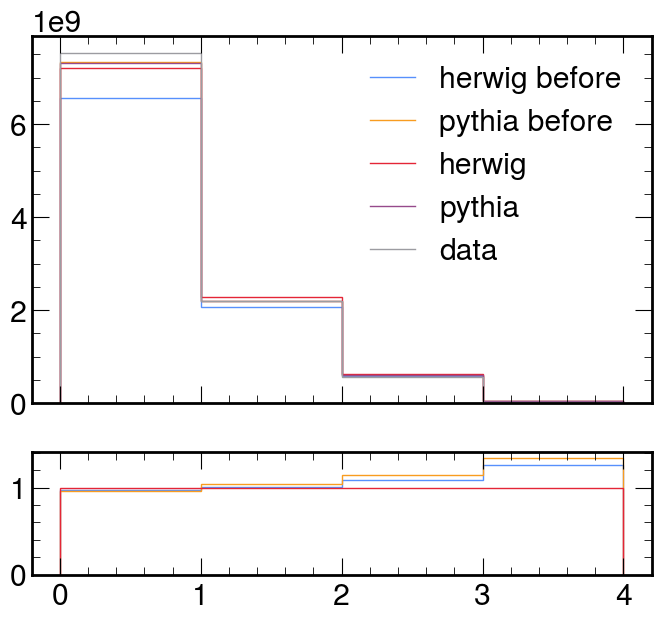

In [8]:
#### Rebinning inputs all to data pt spectrum
def reweight_pt(mchist, datahist, axVar = 'ptreco'):
    normed_mc = mchist.project(axVar).values()*(datahist.project(axVar).values().sum()/mchist.project(axVar).values().sum())
    mc_pt_weight = datahist.project(axVar).values()/normed_mc
    print(mc_pt_weight)
    resp_array = mchist.view()
    shape = [1] * resp_array.ndim
    ptreco_index = mchist.axes.name.index(axVar)
    shape[ptreco_index] = -1
    mc_weights_4d = mc_pt_weight.reshape(shape)
    # print(mc_weights_4d)
    resp_array_weighted = resp_array * mc_weights_4d
    return resp_array_weighted

#print("Check herwig/data pt ", resp_matrix_4d_herwig.project("ptreco").values()/input_data[{"syst":'nominal'}].project("ptreco").values())
resp_matrix_4d_rw = resp_matrix_4d.copy()
fig, (ax, rax) = plt.subplots(
                    nrows=2,
                    ncols=1,
                    figsize=(8,7),
                    gridspec_kw={"height_ratios": (3, 1)},
                    sharex=True)
resp_matrix_4d_herwig_rw = resp_matrix_4d_herwig.copy()
ax.stairs(resp_matrix_4d_herwig.project("ptreco").values(), label="herwig before")
ax.stairs(resp_matrix_4d[{"syst":'nominal'}].project("ptreco").values(), label="pythia before")
# Save back into histograms
availSysts = [ax for ax in resp_matrix_4d.project("syst").axes[0]]
for syst in availSysts:
    print(resp_matrix_4d)
    resp_matrix_4d[{'syst':syst}][...] = reweight_pt(resp_matrix_4d[{'syst':syst}], input_data[{"syst":'nominal'}])
resp_matrix_4d_herwig[...] = reweight_pt(resp_matrix_4d_herwig, input_data[{"syst":'nominal'}])
fakes[...] = reweight_pt(fakes, input_data[{"syst":'nominal'}])

fakes_herwig[...] =  reweight_pt(fakes_herwig, input_data[{"syst":'nominal'}] )
#print("Check herwig/pythia pt ", resp_matrix_4d_herwig.project("ptreco").values()/resp_matrix_4d[{"syst":'nominal'}].project("ptreco").values())
axVar="ptreco"
normed_pythia = resp_matrix_4d_rw[{'syst':"nominal"}].project(axVar).values()*(input_data[{"syst":'nominal'}].project(axVar).integrate(axVar).value/resp_matrix_4d_rw[{'syst':"nominal"}].project(axVar).integrate(axVar).value)
normed_herwig = resp_matrix_4d_herwig_rw.project(axVar).values()*(input_data[{"syst":'nominal'}].project(axVar).integrate(axVar).value/resp_matrix_4d_herwig_rw.project(axVar).integrate(axVar).value)

ax.stairs(normed_herwig, label="herwig")
ax.stairs(normed_pythia, label="pythia")
ax.stairs(input_data[{"syst":'nominal'}].project("ptreco").values(), label="data")

ratio_pythia = normed_pythia/input_data[{"syst":'nominal'}].project("ptreco").values()
ratio_herwig = normed_herwig/input_data[{"syst":'nominal'}].project("ptreco").values()
# print(ratio_herwig)
rax.stairs(ratio_pythia)
rax.stairs(ratio_herwig)
rax.stairs(np.ones_like(ratio_pythia))
ax.legend()
# from ..python.plotting import all
# plotDataMC(resp_matrix_4d, result_data, "ptreco_mreco_u", 'ptreco_mreco_u', "mreco", result_herwig = resp_matrix_4d_herwig, IOV=year, channel = channel, norm=True)

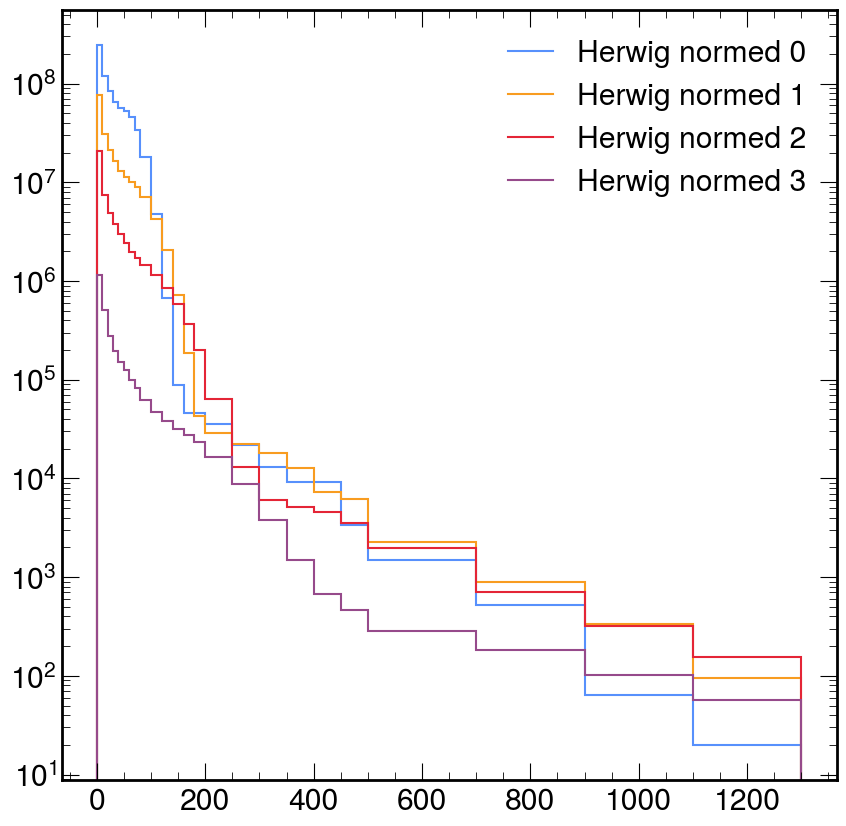

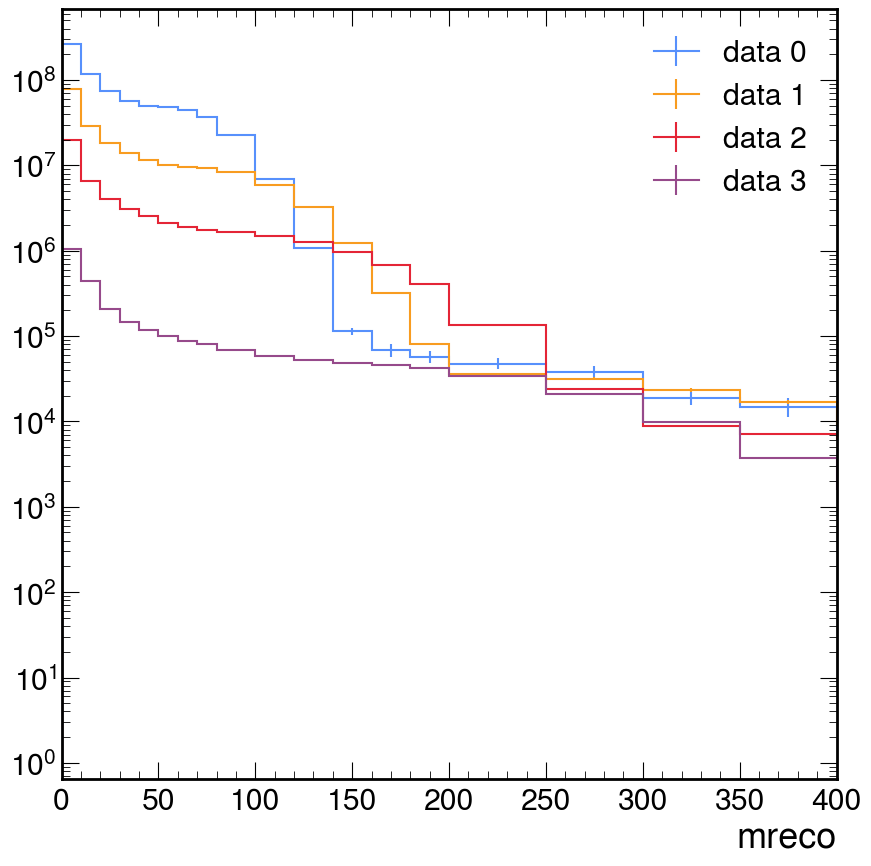

In [9]:
axVar="mreco"
fig, ax = plt.subplots()
m_edges = [bin[0] for bin in resp_matrix_4d_herwig.project(axVar).axes[0]] + [resp_matrix_4d_herwig.project(axVar).axes[0][-1][1]]
for i in range(len(pt_edges)-1):
    #normed_pythia = resp_matrix_4d_rw[{'syst':syst, 'ptreco':i}].project(axVar).values()*(input_data[{"syst":'nominal', 'ptreco':i}].project(axVar).integrate(axVar).value/resp_matrix_4d_rw[{"syst":'nominal', 'ptreco':i}].project(axVar).integrate(axVar).value)
    normed_herwig = resp_matrix_4d_herwig_rw[{'ptreco':i}].project(axVar).values()*(input_data[{"syst":'nominal', 'ptreco':i}].project(axVar).integrate(axVar).value/resp_matrix_4d_herwig_rw[{'ptreco':i}].project(axVar).integrate(axVar).value)
    # plt.stairs(normed_herwig, label="herwig "+str(i))
    hep.histplot(normed_herwig, m_edges, binwnorm=True, label="Herwig normed "+str(i))
    ax.set_yscale("log")
    # # plt.stairs(normed_pythia, label="pythia "+i)
    # hep.histplot(input_data[{"syst":'nominal', "ptreco":i}].project(axVar).values(), edges, binwnorm=True, label="data "+str(i))
plt.legend()
fig, ax = plt.subplots()
for i in range(len(pt_edges)-1):
    #normed_pythia = resp_matrix_4d_rw[{'syst':syst, 'ptreco':i}].project(axVar).values()*(input_data[{"syst":'nominal', 'ptreco':i}].project(axVar).integrate(axVar).value/resp_matrix_4d_rw[{"syst":'nominal', 'ptreco':i}].project(axVar).integrate(axVar).value)
    # plt.stairs(normed_herwig, label="herwig "+str(i))
    hep.histplot(input_data[{"syst":'nominal', "ptreco":i}].project(axVar), binwnorm=True, label="data "+str(i))
    ax.set_yscale("log")
    ax.set_xlim(0,400)
    ax.legend()

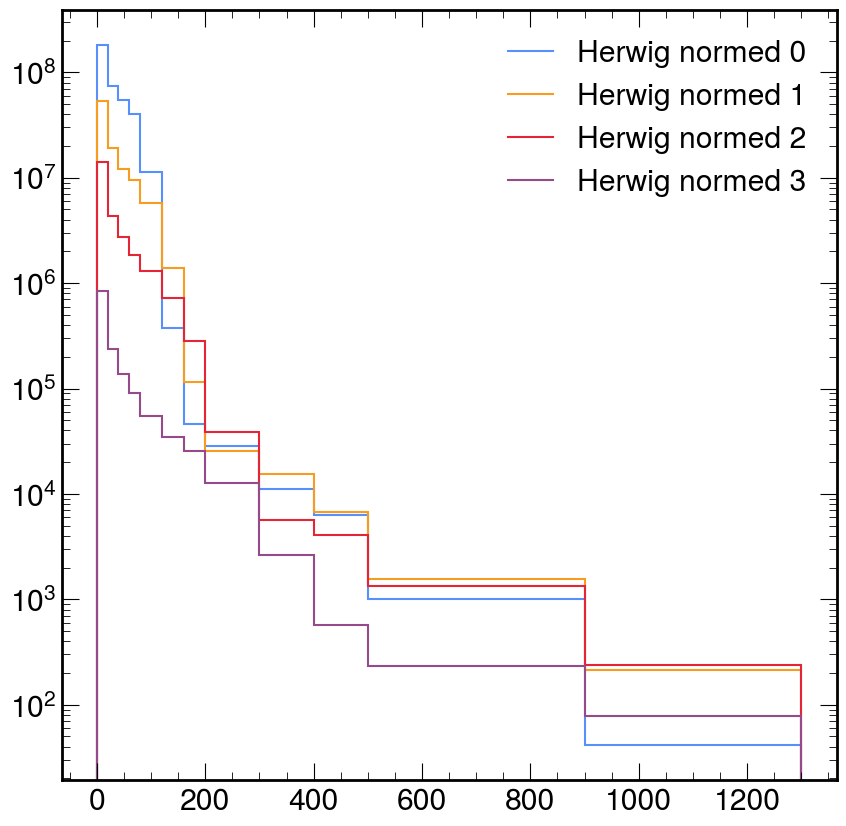

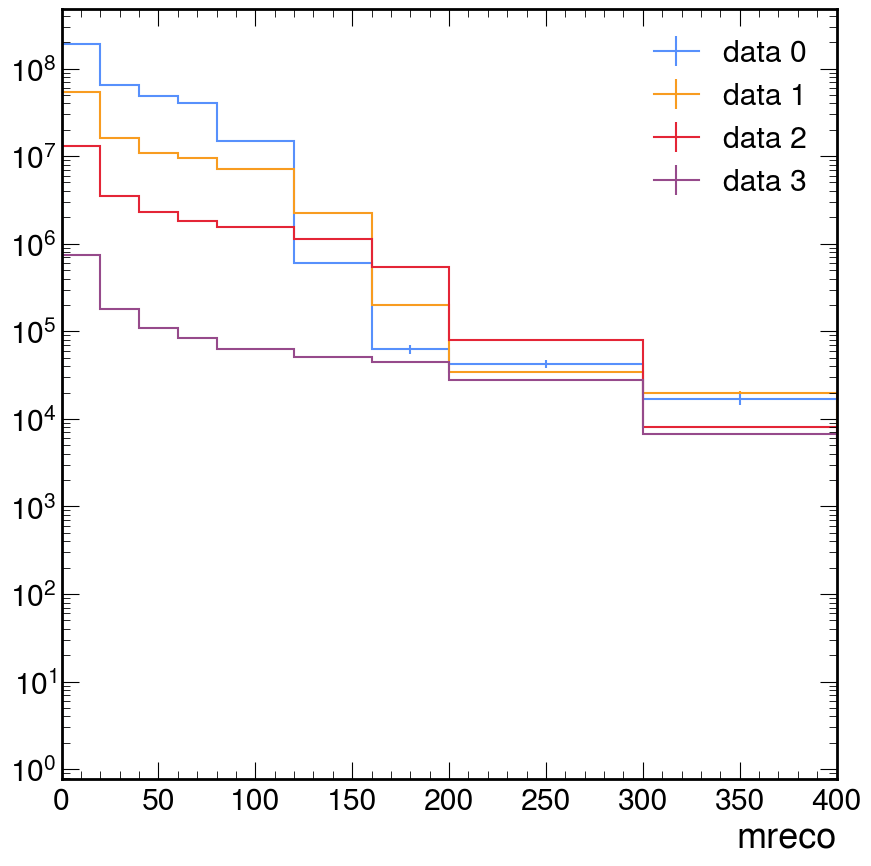

In [10]:
axVar="mreco"
fig, ax = plt.subplots()
m_edges = [bin[0] for bin in resp_matrix_4d_herwig.project(axVar)[hist.rebin(2)].axes[0]] + [resp_matrix_4d_herwig.project(axVar)[hist.rebin(2)].axes[0][-1][1]]
for i in range(len(pt_edges)-1):
    #normed_pythia = resp_matrix_4d_rw[{'syst':syst, 'ptreco':i}].project(axVar).values()*(input_data[{"syst":'nominal', 'ptreco':i}].project(axVar).integrate(axVar).value/resp_matrix_4d_rw[{"syst":'nominal', 'ptreco':i}].project(axVar).integrate(axVar).value)
    normed_herwig = resp_matrix_4d_herwig_rw[{'ptreco':i}].project(axVar)[hist.rebin(2)].values()*(input_data[{"syst":'nominal', 'ptreco':i}].project(axVar)[hist.rebin(2)].integrate(axVar).value/resp_matrix_4d_herwig_rw[{'ptreco':i}].project(axVar).integrate(axVar).value)
    # plt.stairs(normed_herwig, label="herwig "+str(i))
    hep.histplot(normed_herwig, m_edges, binwnorm=True, label="Herwig normed "+str(i))
    ax.set_yscale("log")
    # # plt.stairs(normed_pythia, label="pythia "+i)
    # hep.histplot(input_data[{"syst":'nominal', "ptreco":i}].project(axVar).values(), edges, binwnorm=True, label="data "+str(i))
plt.legend()
fig, ax = plt.subplots()
for i in range(len(pt_edges)-1):
    #normed_pythia = resp_matrix_4d_rw[{'syst':syst, 'ptreco':i}].project(axVar).values()*(input_data[{"syst":'nominal', 'ptreco':i}].project(axVar).integrate(axVar).value/resp_matrix_4d_rw[{"syst":'nominal', 'ptreco':i}].project(axVar).integrate(axVar).value)
    # plt.stairs(normed_herwig, label="herwig "+str(i))
    hep.histplot(input_data[{"syst":'nominal', "ptreco":i}].project(axVar)[hist.rebin(2)], binwnorm=True, label="data "+str(i))
    ax.set_yscale("log")
    ax.set_xlim(0,400)
    ax.legend()

In [11]:
resp_matrix_4d[{"syst":'nominal'}]

Hist(
  StrCategory(['QCD_pythiaMG2016APV', 'QCD_pythiaMG2016', 'QCD_pythiaMG2017', 'QCD_pythiaMG2018'], growth=True, name='dataset', label='Primary dataset'),
  IntCategory([-1], growth=True, name='jk', label='Jackknife section'),
  Variable([200, 290, 400, 680, 13000], name='ptreco'),
  Variable(array([   0.,   10.,   20.,   30.,   40.,   50.,   60.,   70.,   80.,
        100.,  120.,  140.,  160.,  180.,  200.,  250.,  300.,  350.,
        400.,  450.,  500.,  700.,  900., 1100., 1300.]), name='mreco'),
  Variable([200, 290, 400, 680, 13000], name='ptgen'),
  Variable([0, 20, 40, 60, 80, 120, 160, 200, 300, 400, 500, 900, 1300], name='mgen'),
  storage=Weight()) # Sum: WeightedSum(value=8.90414e+09, variance=8.77408e+11) (WeightedSum(value=1.1203e+10, variance=1.37463e+12) with flow)

In [12]:
output_pythia['response_matrix_u']

Hist(
  StrCategory(['QCD_pythiaMG2016APV', 'QCD_pythiaMG2016', 'QCD_pythiaMG2017', 'QCD_pythiaMG2018'], growth=True, name='dataset', label='Primary dataset'),
  StrCategory(['nominal', 'LuminosityDown', 'PUSFDown', 'Q2muRUp', 'L1prefiringUp', 'Q2muFUp', 'PDFUp', 'PDFDown', 'PUSFUp', 'LuminosityUp', 'L1prefiringDown', 'Q2muFDown', 'Q2muRDown', 'JERUp', 'JERDown', 'HEM', 'JES_AbsoluteMPFBiasUp', 'JES_AbsoluteMPFBiasDown', 'JES_AbsoluteScaleUp', 'JES_AbsoluteScaleDown', 'JES_AbsoluteStatUp', 'JES_AbsoluteStatDown', 'JES_FlavorQCDUp', 'JES_FlavorQCDDown', 'JES_FragmentationUp', 'JES_FragmentationDown', 'JES_PileUpDataMCUp', 'JES_PileUpDataMCDown', 'JES_PileUpPtBBUp', 'JES_PileUpPtBBDown', 'JES_PileUpPtEC1Up', 'JES_PileUpPtEC1Down', 'JES_PileUpPtEC2Up', 'JES_PileUpPtEC2Down', 'JES_PileUpPtHFUp', 'JES_PileUpPtHFDown', 'JES_PileUpPtRefUp', 'JES_PileUpPtRefDown', 'JES_RelativeFSRUp', 'JES_RelativeFSRDown', 'JES_RelativeJEREC1Up', 'JES_RelativeJEREC1Down', 'JES_RelativeJEREC2Up', 'JES_Relative

In [13]:
from unfold_utils.integrate_and_rebin import *



In [14]:
from cycler import cycler

# Set tab20 as the default color cycle
tab20_colors = plt.cm.tab20.colors
plt.rcParams['axes.prop_cycle'] = cycler(color=tab20_colors)

In [15]:
ptreco_center = resp_matrix_4d.axes['ptreco'].centers
ptreco_width = resp_matrix_4d.axes['ptreco'].widths
ptreco_edge = resp_matrix_4d.axes['ptreco'].edges

ptgen_center = resp_matrix_4d.axes['ptgen'].centers
ptgen_width = resp_matrix_4d.axes['ptgen'].widths
ptgen_edge = resp_matrix_4d.axes['ptgen'].edges
mreco_center = resp_matrix_4d.axes['mreco'].centers
mreco_edge = resp_matrix_4d.axes['mreco'].edges
mgen_center = resp_matrix_4d.axes['mgen'].centers

mreco_width = resp_matrix_4d.axes['mreco'].widths
mgen_width = resp_matrix_4d.axes['mgen'].widths
mgen_edge = resp_matrix_4d.axes['mgen'].edges

In [16]:
correlation_dic = {'JES_AbsoluteMPFBias': 1,
                       'JES_AbsoluteScale': 1,
                        'JES_AbsoluteStat': 0,
                        'JES_FlavorQCD': 1,
                        'JES_Fragmentation': 1,
                        'JES_PileUpDataMC': 0.5,
                        'JES_PileUpPtBB': 0.5,
                        'JES_PileUpPtEC1': 0.5,
                        'JES_PileUpPtEC2': 0.5,
                        'JES_PileUpPtHF': 0.5,
                        'JES_PileUpPtRef': 0.5,
                        'JES_RelativeFSR': 0.5,
                        'JES_RelativeJEREC1': 0,
                        'JES_RelativeJEREC2': 0,
                        'JES_RelativeJERHF': 0.5,
                        'JES_RelativePtBB': 0.5,
                        'JES_RelativePtEC1': 0,
                        'JES_RelativePtEC2': 0,
                        'JES_RelativePtHF': 0.5,
                        'JES_RelativeBal': 0.5,
                        'JES_RelativeSample': 0,
                        'JES_RelativeStatEC': 0,
                        'JES_RelativeStatFSR': 0,
                        'JES_RelativeStatHF': 0,
                        'JES_SinglePionECAL': 1,
                        'JES_SinglePionHCAL': 1,
                        'JES_TimePtEta': 0,}

jes_syst_list = ['AbsoluteMPFBiasUp', 'AbsoluteMPFBiasDown', 'AbsoluteScaleUp', 'AbsoluteScaleDown', 'AbsoluteStatUp', 'AbsoluteStatDown', 'FlavorQCDUp', 'FlavorQCDDown', 'FragmentationUp', 'FragmentationDown', 'PileUpDataMCUp', 'PileUpDataMCDown', 'PileUpPtBBUp', 'PileUpPtBBDown', 'PileUpPtEC1Up', 'PileUpPtEC1Down', 'PileUpPtEC2Up', 'PileUpPtEC2Down', 'PileUpPtHFUp', 'PileUpPtHFDown', 'PileUpPtRefUp', 'PileUpPtRefDown', 'RelativeFSRUp', 'RelativeFSRDown', 'RelativeJEREC1Up', 'RelativeJEREC1Down', 'RelativeJEREC2Up', 'RelativeJEREC2Down', 'RelativeJERHFUp', 'RelativeJERHFDown', 'RelativePtBBUp', 'RelativePtBBDown', 'RelativePtEC1Up', 'RelativePtEC1Down', 'RelativePtEC2Up', 'RelativePtEC2Down', 'RelativePtHFUp', 'RelativePtHFDown', 'RelativeBalUp', 'RelativeBalDown', 'RelativeSampleUp', 'RelativeSampleDown', 'RelativeStatECUp', 'RelativeStatECDown', 'RelativeStatFSRUp', 'RelativeStatFSRDown', 'RelativeStatHFUp', 'RelativeStatHFDown', 'SinglePionECALUp', 'SinglePionECALDown', 'SinglePionHCALUp', 'SinglePionHCALDown', 'TimePtEtaUp', 'TimePtEtaDown']
# jes_sys_list_up = [jes for jes in jes_syst_list if 'Up' in jes]
# jes_sys_list_down = [jes for jes in jes_syst_list if 'Down' in jes]
jes_sys_list_up = ["JES_"+jes for jes in jes_syst_list if jes[-2:]=='Up']
jes_sys_list_down = ["JES_"+jes for jes in jes_syst_list if 'Down' in jes]
# jes_sys_list_up.append('JERUp')
# jes_sys_list_down.append('JERDown')
non_jes_sys_list = ['LuminosityUp','LuminosityDown','PDFDown', 'PDFUp', 'L1prefiringDown', 'L1prefiringUp', 'Q2muRUp','Q2muRDown','PUSFUp', 'Q2muFUp','Q2muFDown', 'PUSFDown', "JMRUp", "JMRDown", "JMSUp", "JMSDown", 'JERUp', 'JERDown']
#non_jes_sys_list = ['HEM', 'LuminosityUp','LuminosityDown','PDFDown', 'PDFUp', 'L1prefiringDown', 'L1prefiringUp', 'Q2Up', 'PUSFUp', 'Q2Down', 'PUSFDown','jerUp', 'jerDown', 'jmrUp', 'jmrDown', 'jmsUp', 'jmsDown']
non_jes_sys_list_down =  [jes for jes in non_jes_sys_list if 'Down' in jes]
non_jes_sys_list_up =  [jes for jes in non_jes_sys_list if 'Up' in jes]

In [17]:

sys_matrix_dic = {}
sys_matrix_dic_down = {}
mcstring='QCD_pythiaMG'
if not single_year:
    for sys in jes_sys_list_up:
        m_nom_2016 = resp_matrix_4d[{"syst":'nominal', "dataset":[mcstring+'2016', mcstring+'2016APV']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
        m_nom_2017 = resp_matrix_4d[{"syst":'nominal', "dataset":[mcstring+'2017']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
        m_nom_2018 = resp_matrix_4d[{"syst":'nominal', "dataset":[mcstring+'2018']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()

        m_sys_2016 = resp_matrix_4d[{"syst":sys, "dataset":[mcstring+'2016', mcstring+'2016APV']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
        m_sys_2017 = resp_matrix_4d[{"syst":sys, "dataset":[mcstring+'2017']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
        m_sys_2018 = resp_matrix_4d[{"syst":sys, "dataset":[mcstring+'2018']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()

        m_var_2016 = m_sys_2016 + m_nom_2017 + m_nom_2018
        m_var_2017 = m_nom_2016 + m_sys_2017 + m_nom_2018
        m_var_2018 = m_nom_2016 + m_nom_2017 + m_sys_2018


        rho = correlation_dic[sys[:-2]]
        print(rho)## correlation factor

        sigma_2016 = m_sys_2016 - m_nom_2016
        sigma_2017 = m_sys_2017 - m_nom_2017
        sigma_2018 = m_sys_2018 - m_nom_2018

        sigma_corr = rho*sigma_2016 + rho*sigma_2017 + rho*sigma_2018

        sigma_uncorr_2016 = (1-rho)*sigma_2016
        sigma_uncorr_2017 = (1-rho)*sigma_2017
        sigma_uncorr_2018 = (1-rho)*sigma_2018

        m_nom =  m_nom_2016 + m_nom_2017 + m_nom_2018
        m_corr = m_nom + sigma_corr

        m_uncorr_2016 = m_nom + sigma_uncorr_2016

        m_uncorr_2017 = m_nom + sigma_uncorr_2017

        m_uncorr_2018 = m_nom + sigma_uncorr_2018



        sys_matrix_dic[sys+'_corr'] = m_corr
        sys_matrix_dic[sys+'_uncorr_2016'] = m_uncorr_2016
        sys_matrix_dic[sys+'_uncorr_2017'] = m_uncorr_2017
        sys_matrix_dic[sys+'_uncorr_2018'] = m_uncorr_2018

    non_jes_sys_matrix_dic = {}
    for sys in non_jes_sys_list_up:
        sys_matrix_dic[sys] = resp_matrix_4d[{"syst":sys}].project('ptgen','mgen','ptreco','mreco').values()
        non_jes_sys_matrix_dic[sys] = resp_matrix_4d[{"syst":sys}].project('ptgen','mgen','ptreco','mreco').values()



    for sys in jes_sys_list_down:
        m_nom_2016 = resp_matrix_4d[{"syst":'nominal', "dataset":[mcstring+'2016', mcstring+'2016APV']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
        m_nom_2017 = resp_matrix_4d[{"syst":'nominal', "dataset":[mcstring+'2017']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
        m_nom_2018 = resp_matrix_4d[{"syst":'nominal', "dataset":[mcstring+'2018']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()

        m_sys_2016 = resp_matrix_4d[{"syst":sys, "dataset":[mcstring+'2016', mcstring+'2016APV']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
        m_sys_2017 = resp_matrix_4d[{"syst":sys, "dataset":[mcstring+'2017']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
        m_sys_2018 = resp_matrix_4d[{"syst":sys, "dataset":[mcstring+'2018']}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()


        m_var_2016 = m_sys_2016 + m_nom_2017 + m_nom_2018
        m_var_2017 = m_nom_2016 + m_sys_2017 + m_nom_2018
        m_var_2018 = m_nom_2016 + m_nom_2017 + m_sys_2018


        rho = rho = correlation_dic[sys[:-4]] ## correlation factor

        sigma_2016 = m_sys_2016 - m_nom_2016
        sigma_2017 = m_sys_2017 - m_nom_2017
        sigma_2018 = m_sys_2018 - m_nom_2018

        sigma_corr = rho*sigma_2016 + rho*sigma_2017 + rho*sigma_2018

        sigma_uncorr_2016 = (1-rho)*sigma_2016
        sigma_uncorr_2017 = (1-rho)*sigma_2017
        sigma_uncorr_2018 = (1-rho)*sigma_2018

        m_nom =  m_nom_2016 + m_nom_2017 + m_nom_2018
        m_corr = m_nom + sigma_corr

        m_uncorr_2016 = m_nom + sigma_uncorr_2016

        m_uncorr_2017 = m_nom + sigma_uncorr_2017

        m_uncorr_2018 = m_nom + sigma_uncorr_2018



        sys_matrix_dic_down[sys+'_corr'] = m_corr
        sys_matrix_dic_down[sys+'_uncorr_2016'] = m_uncorr_2016
        sys_matrix_dic_down[sys+'_uncorr_2017'] = m_uncorr_2017
        sys_matrix_dic_down[sys+'_uncorr_2018'] = m_uncorr_2018


    for sys in non_jes_sys_list_down:
        sys_matrix_dic_down[sys] = resp_matrix_4d[{"syst":sys}].project('ptgen','mgen','ptreco','mreco').values()

    # sys_matrix_dic['HEMUp'] = resp_matrix_4d[{"syst":"HEM"}].project('ptgen','mgen','ptreco','mreco').values()
    # HEM_diff = np.abs(resp_matrix_4d[{"syst":"HEM"}].project('ptgen','mgen','ptreco','mreco').values() - resp_matrix_4d[{"syst":"nominal"}].project('ptgen','mgen','ptreco','mreco').values())
    # sys_matrix_dic_down['HEMDown'] = resp_matrix_4d[{"syst":"nominal"}].project('ptgen','mgen','ptreco','mreco').values() - HEM_diff    

herwig_diff = np.abs(resp_matrix_4d_herwig.project('ptgen','mgen','ptreco','mreco').values() - resp_matrix_4d[{"syst":"nominal"}].project('ptgen','mgen','ptreco','mreco').values())
sys_matrix_dic_down['herwigDown'] = resp_matrix_4d.project('ptgen','mgen','ptreco','mreco').values() - herwig_diff
sys_matrix_dic['herwigUp'] = resp_matrix_4d.project('ptgen','mgen','ptreco','mreco').values() + herwig_diff

1


/opt/conda/lib/python3.10/site-packages/hist/basehist.py:480: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


1
0
1
1
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0
0
0.5
0.5
0
0
0.5
0.5
0
0
0
0
1
1
0


In [18]:
##### for doing systs for only one year
if single_year != False:
    for sys in [ax for ax in resp_matrix_4d.project("syst").axes[0] if "Up" in ax]:
        sys_matrix_dic[sys] = resp_matrix_4d[{"syst":sys}].project('ptgen','mgen','ptreco','mreco').values()
    for sys in [ax for ax in resp_matrix_4d.project("syst").axes[0] if "Down" in ax]:
        sys_matrix_dic_down[sys] = resp_matrix_4d[{"syst":sys}].project('ptgen','mgen','ptreco','mreco').values()

In [19]:
# custom_sys_dic = {'jerUp': resp_matrix_4d[{'syst':'jerUp'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values() ,
#                    'AbsoluteScaleUp': resp_matrix_4d[{'syst':'AbsoluteScaleUp'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()}

In [20]:
if groomed:
    key = 'response_matrix_g'
else:
    key = 'response_matrix_u'
print(fakes)
unfolder = Unfolder(input_data, 
                    resp_matrix_4d[{'syst':'nominal'}] ,
                    #resp_matrix_4d_jk,
                    fakes = fakes,
                    misses = misses,
                    backgrounds = None,
                    #systematics = custom_sys_dic,
                    systematics = sys_matrix_dic,
                    #systematics= None,
                    #systematics = jes_sys_list_up,
                    closure = closure,
                    groomed = groomed,
                    is_uf = True,
                    merge = False,
                    normalized_syst = True,
                    do_syst = True,
                    discard_low_bins = False,
                    regularisation= 'None',
                    do_norm = False
                           )
# output_nominal, matrix_plot = unfold_using_matrix(input_data, resp_matrix_4d[{'systematic':'nominal'}] , fakes, misses,
#                             backgrounds = {"ww": ww_bg, "wz":wz_bg, "zz": zz_bg},
#                             #systematics = {'JES_AbsoluteMPFBiasUp': resp_matrix_4d[{'systematic':'JES_AbsoluteMPFBiasUp'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()  },
#                             systematics = sys_matrix_dic,
#                             closure = closure,
#                             groomed = groomed,
#                             is_uf = True,
#                             merge = False,
#                             normalised_xs = True,
#                             do_syst = True,
#                             discard_low_bins = False,
#                             regularisation= 'ScanSURE',
#                             plot = True
#                                     )


Hist(
  StrCategory(['QCD_pythiaMG2016APV', 'QCD_pythiaMG2016', 'QCD_pythiaMG2017', 'QCD_pythiaMG2018'], growth=True, name='dataset', label='Primary dataset'),
  IntCategory([-1], growth=True, name='jk', label='Jackknife section'),
  Variable([200, 290, 400, 680, 13000], name='ptreco'),
  Variable(array([   0.,   10.,   20.,   30.,   40.,   50.,   60.,   70.,   80.,
        100.,  120.,  140.,  160.,  180.,  200.,  250.,  300.,  350.,
        400.,  450.,  500.,  700.,  900., 1100., 1300.]), name='mreco'),
  storage=Weight()) # Sum: WeightedSum(value=4.33796e+07, variance=2.61568e+09) (WeightedSum(value=4.8519e+07, variance=3.02028e+09) with flow)
12
[   0.   20.   40.   60.   80.  120.  160.  200.  300.  400.  500.  900.
 1300.]
24
[   0.   10.   20.   30.   40.   50.   60.   70.   80.  100.  120.  140.
  160.  180.  200.  250.  300.  350.  400.  450.  500.  700.  900. 1100.
 1300.]
Signal Binning created
Detector Binning created
shape of you (96,)


/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:176: RuntimeWarning: invalid value encountered in divide
  self.miss_frac = self.miss_values/ ( self.M_np.sum(axis = 1))


Working until background subtractions
Unfolder object created
Condition number of the matrix  1.6902869697482985e+18
Working until background subtractions
Unfolder object created
Condition number of the matrix  1.6902869697482985e+18


Info in <TUnfold::SetConstraint>: fConstraint=1
Warning in <TUnfold::TUnfold>: 9 output bins do not depend on the input data  0 9-12 23-24 36 49
Info in <TUnfold::TUnfold>: 96 input bins and 41 output bins
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #0
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #9 (signal:ptgen[200,290]:massgen[300,400])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #10 (signal:ptgen[200,290]:massgen[400,500])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #11 (signal:ptgen[200,290]:massgen[500,900])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #12 (signal:ptgen[200,290]:massgen[900,1.3e+03])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #23 (signal:ptgen[290,400]:massgen[500,900])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #24 (signal:ptgen[290,400]:massgen[900,1.3e+03])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #36 (signal:ptgen[400,680]:massgen[900,1.3e+03])
Info in <TUnfoldDensity::

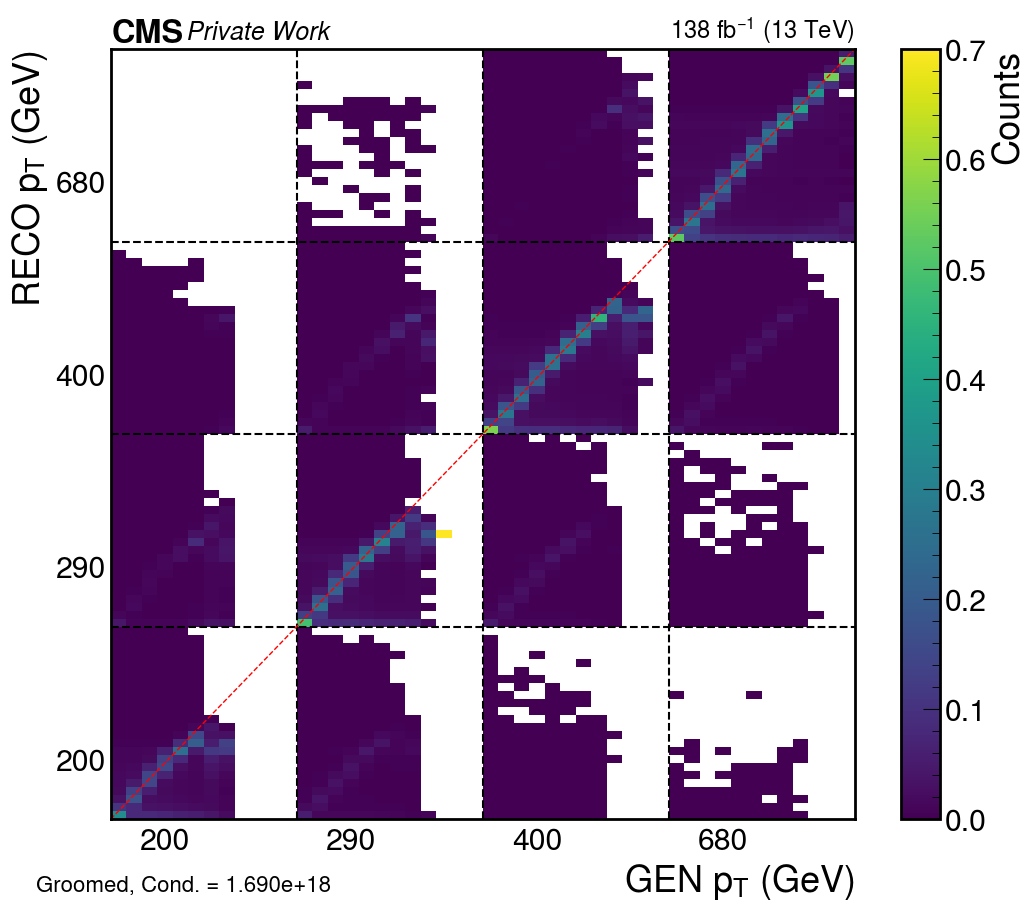

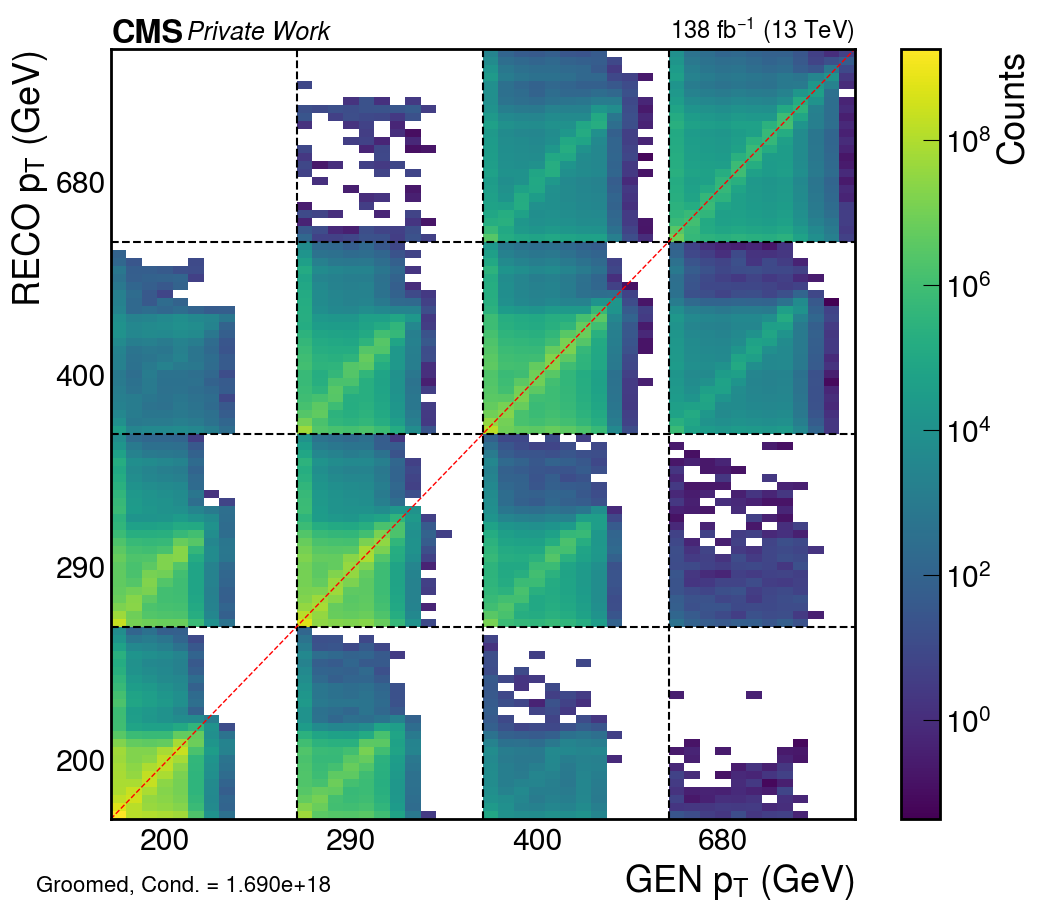

In [21]:
#### Plotting probability matrix w/ Aritra's built in function
unfolder.plot_response_matrix(year = single_year)
if single_year:
    IOV=single_year
else:
    IOV=''
plt.savefig(f"../plots/unfolding/{channel}/probability_matrix{groom_str}{IOV}.pdf", bbox_inches="tight")
#### Plotting respponse matrix w/ Aritra's built in function
unfolder.plot_response_matrix(probability_matrix=False, year = single_year)
plt.savefig(f"../plots/unfolding/{channel}/response_matrix{groom_str}{IOV}.pdf", bbox_inches="tight")

0 12
[[1.76621573e+09 5.60534124e+08 1.65062058e+08 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.31400703e+08 1.32007028e+08 2.90055598e+08 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.07194134e+08 4.10500622e+07 3.28505703e+07 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.77369894e+01
  5.77303493e+00 4.27110912e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 7.85937095e+02
  1.68147601e+01 1.06837548e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 9.59700357e+00
  4.64365585e+01 4.67196227e+00]]


3.520186829184242

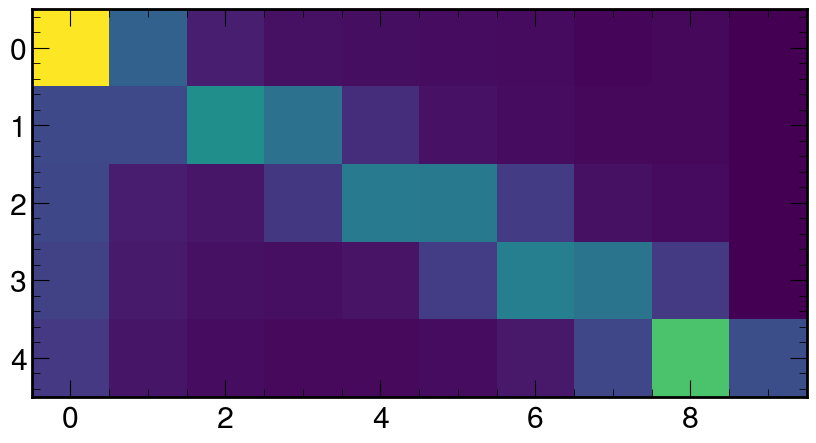

In [22]:
diag = 0
edge1 = diag*(len(unfolder.mbinsGen)-1)
edge2 = (diag+1)*(len(unfolder.mbinsGen)-1)
edge1_reco = diag*(len(unfolder.mbinsDet)-1)
edge2_reco = (diag+1)*(len(unfolder.mbinsDet)-1)
print(edge1, edge2)
print(unfolder.M_np)
# diag_resp = unfolder.M_np[edge1:edge2,edge1_reco:edge2_reco]
# diag_resp_norm = diag_resp.copy()
# for i in range(len(unfolder.mbinsGen)-1):
#     diag_resp_norm[i] = diag_resp_norm[i]/diag_resp_norm[i].sum()
# plt.imshow(diag_resp_norm)
# np.linalg.cond(diag_resp_norm)
diag_resp = unfolder.M_np[0:5,0:10]
diag_resp_norm = diag_resp.copy()
for i in range(5):
    diag_resp_norm[i] = diag_resp_norm[i]/diag_resp_norm[i].sum()
plt.imshow(diag_resp_norm)
np.linalg.cond(diag_resp_norm)

In [23]:
unfolder.perform_unfold(regularisation)
# Plot the covariance matrix or unfolded distributions:
unfolder.total_sys_pt_binned
unfolder.stat_mat_pt_binned
#Tau value 3.7973496108999385e-05 from ScanTau
#Tau value 3.3389363211868252e-06
# Regularisation USED ScanLcurve
# Tau value 7.104974114426787e-06
#### TRIJET TAUS
#Tau value 8.933610809321706e-05
#Tau value 0.0004869675251658631

Working until background subtractions
Unfolder object created
Regularisation USED None
Tau value 0.0


[array([0.05735443, 0.04712525, 0.05357489, 0.06753564, 0.24736126,
        0.10345745, 0.03534293, 0.38824817, 0.        , 0.        ,
        0.        , 0.        ]),
 array([0.02570031, 0.01548818, 0.01681796, 0.01138749, 0.02916902,
        0.147796  , 0.18966145, 0.07253515, 0.4553323 , 0.03611214,
        0.        , 0.        ]),
 array([0.0590657 , 0.01206871, 0.01105265, 0.01241896, 0.0253559 ,
        0.07581755, 0.05843272, 0.16917688, 0.04151695, 0.47655572,
        0.05853825, 0.        ]),
 array([0.11676617, 0.0399214 , 0.01617141, 0.02757584, 0.01562242,
        0.14603586, 0.02695737, 0.18232651, 0.06724118, 0.32306642,
        0.03788224, 0.00043319])]

Warning in <TROOT::Append>: Replacing existing TH1: M (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_reco (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htrue (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htruef (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_corr (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_uncorr_2016 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_uncorr_2017 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_uncorr_2018 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteScaleUp_corr (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing 

In [24]:
print(unfolder.stat_mat_pt_binned)
# unfolder.plot_output_sys()
# unfolder_dn.plot_output_sys()

[array([0.05735443, 0.04712525, 0.05357489, 0.06753564, 0.24736126,
       0.10345745, 0.03534293, 0.38824817, 0.        , 0.        ,
       0.        , 0.        ]), array([0.02570031, 0.01548818, 0.01681796, 0.01138749, 0.02916902,
       0.147796  , 0.18966145, 0.07253515, 0.4553323 , 0.03611214,
       0.        , 0.        ]), array([0.0590657 , 0.01206871, 0.01105265, 0.01241896, 0.0253559 ,
       0.07581755, 0.05843272, 0.16917688, 0.04151695, 0.47655572,
       0.05853825, 0.        ]), array([0.11676617, 0.0399214 , 0.01617141, 0.02757584, 0.01562242,
       0.14603586, 0.02695737, 0.18232651, 0.06724118, 0.32306642,
       0.03788224, 0.00043319])]


In [25]:
# unfolder_dn.delta_sys_dic

In [26]:
np.sqrt(100 * 0.02**2)

0.2

In [27]:
unfolder.o_sys_dic_pt_binned.keys()

dict_keys(['JES_AbsoluteMPFBiasUp_corr', 'JES_AbsoluteMPFBiasUp_uncorr_2016', 'JES_AbsoluteMPFBiasUp_uncorr_2017', 'JES_AbsoluteMPFBiasUp_uncorr_2018', 'JES_AbsoluteScaleUp_corr', 'JES_AbsoluteScaleUp_uncorr_2016', 'JES_AbsoluteScaleUp_uncorr_2017', 'JES_AbsoluteScaleUp_uncorr_2018', 'JES_AbsoluteStatUp_corr', 'JES_AbsoluteStatUp_uncorr_2016', 'JES_AbsoluteStatUp_uncorr_2017', 'JES_AbsoluteStatUp_uncorr_2018', 'JES_FlavorQCDUp_corr', 'JES_FlavorQCDUp_uncorr_2016', 'JES_FlavorQCDUp_uncorr_2017', 'JES_FlavorQCDUp_uncorr_2018', 'JES_FragmentationUp_corr', 'JES_FragmentationUp_uncorr_2016', 'JES_FragmentationUp_uncorr_2017', 'JES_FragmentationUp_uncorr_2018', 'JES_PileUpDataMCUp_corr', 'JES_PileUpDataMCUp_uncorr_2016', 'JES_PileUpDataMCUp_uncorr_2017', 'JES_PileUpDataMCUp_uncorr_2018', 'JES_PileUpPtBBUp_corr', 'JES_PileUpPtBBUp_uncorr_2016', 'JES_PileUpPtBBUp_uncorr_2017', 'JES_PileUpPtBBUp_uncorr_2018', 'JES_PileUpPtEC1Up_corr', 'JES_PileUpPtEC1Up_uncorr_2016', 'JES_PileUpPtEC1Up_uncorr_2

In [28]:
# for i in range(unfolder.nptbinsGen):
#     #plt.stairs(unfolder.output_pt_binned[i])
#     #plt.stairs(unfolder.o_sys_dic_pt_binned['AbsoluteStatUp_uncorr_2017'][i])
#     plt.stairs(np.abs(unfolder.output_pt_binned[i]-unfolder.o_sys_dic_pt_binned['AbsoluteStatUp_uncorr_2017'][i])/unfolder.output_pt_binned[i])
#     plt.ylim(0,0.5)
#     plt.show()

Bin  0
Bin  1
Bin  2
Bin  3


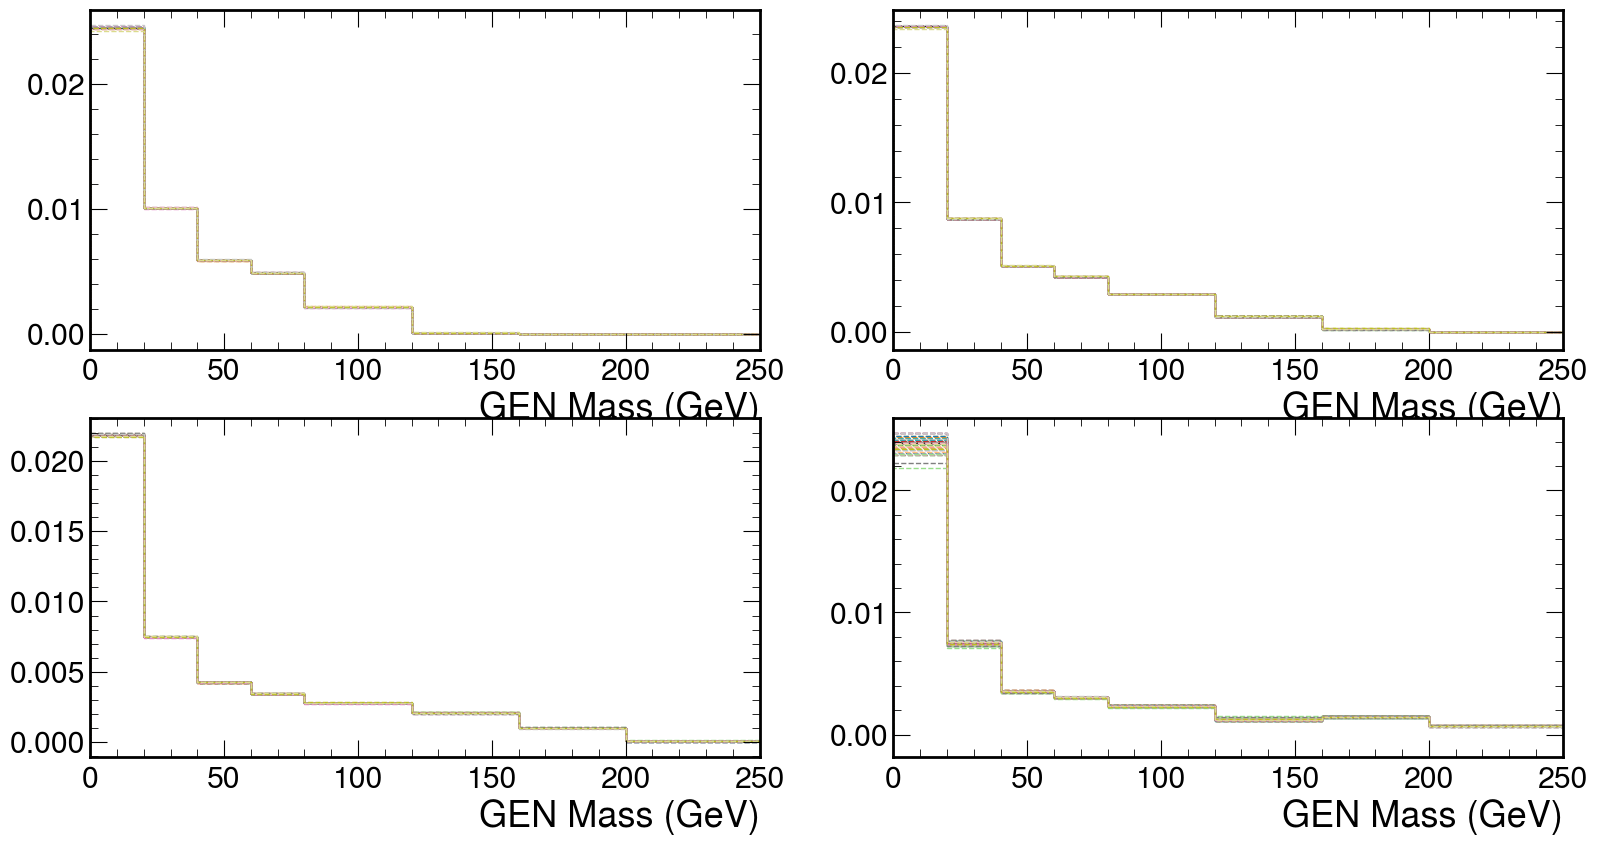

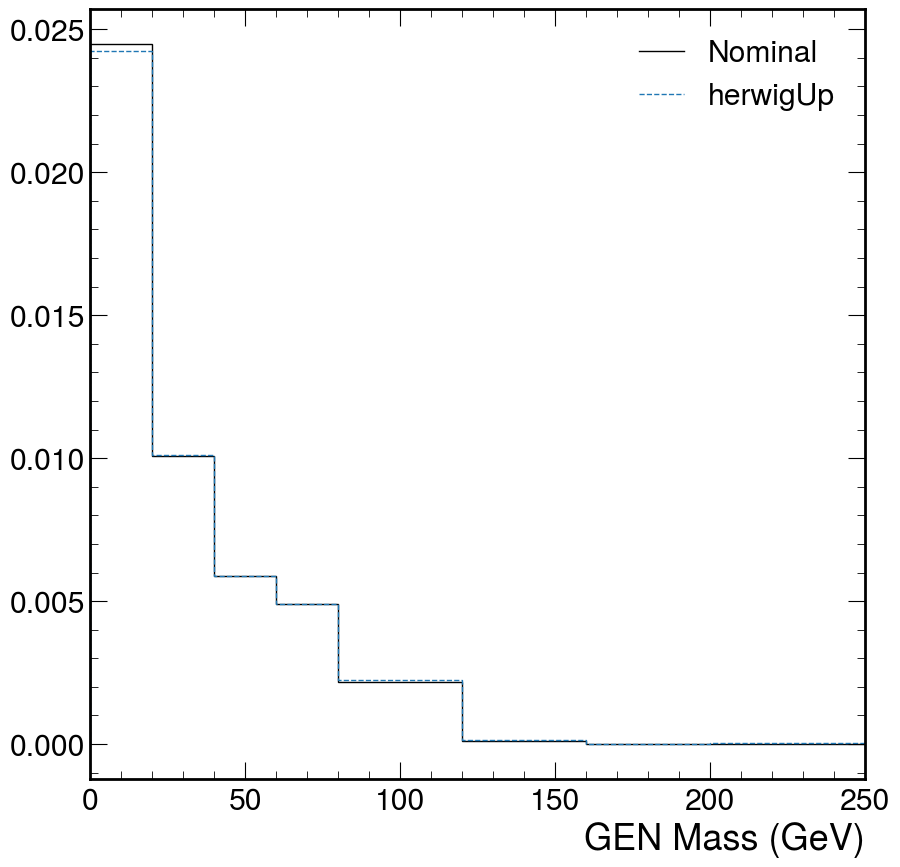

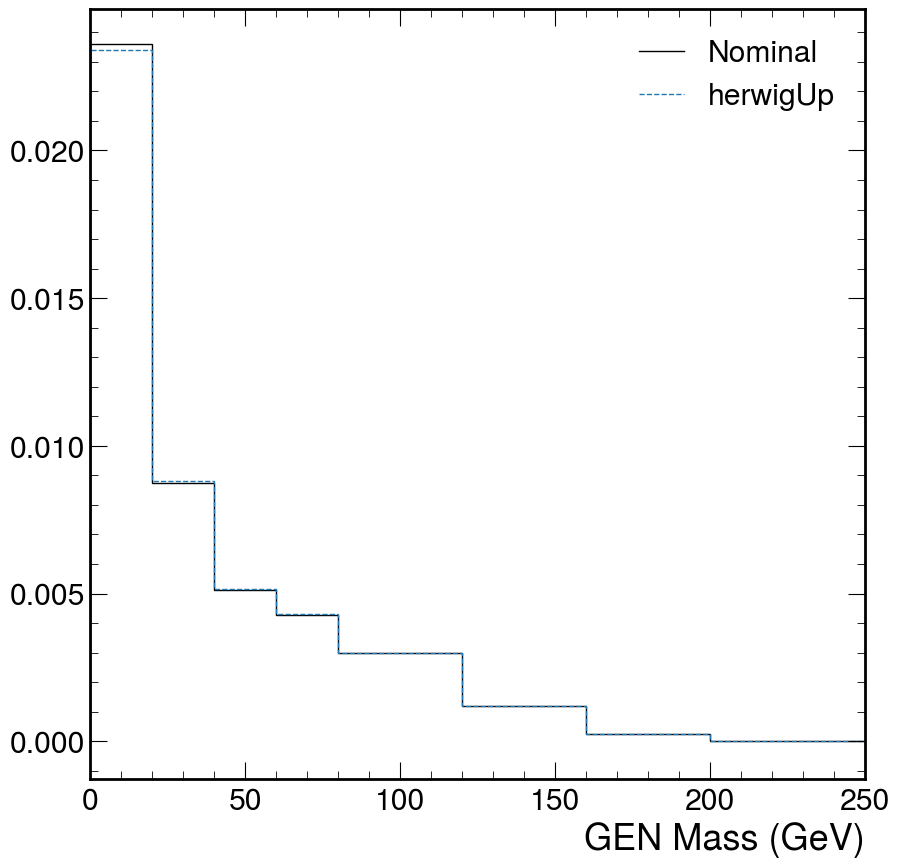

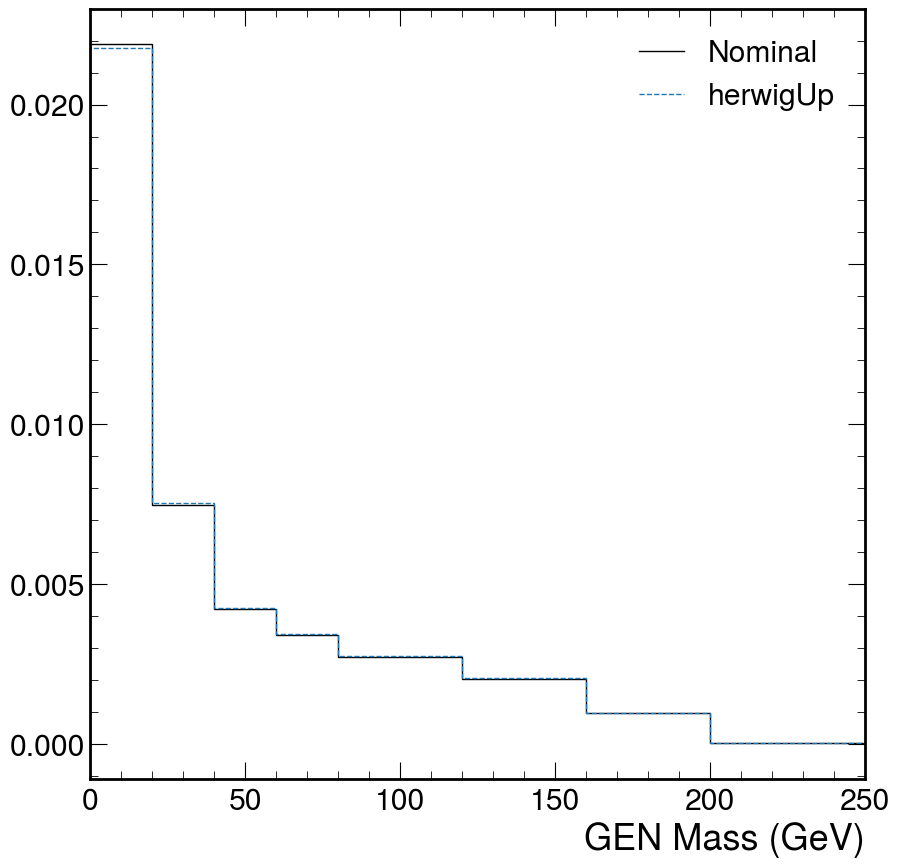

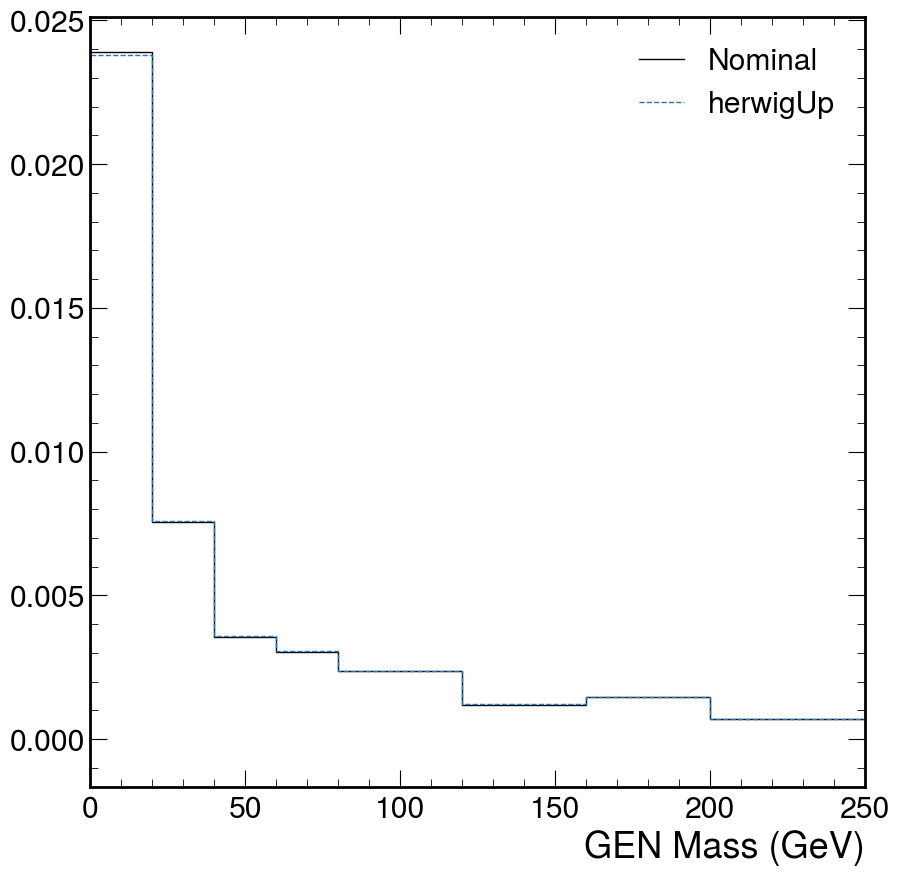

In [29]:
unfolder.plot_output_sys()

In [30]:
# print(unfolder_dn.delta_sys_dic_pt_binned.keys())
# plt.stairs(unfolder.delta_sys_dic_pt_binned['JES_AbsoluteMPFBiasUp_corr'][2], color = 'r', label = "Up")
# plt.stairs(unfolder_dn.delta_sys_dic_pt_binned['JES_AbsoluteMPFBiasDown_corr'][2], color = 'b', ls = '--', label = "Down")
# plt.legend()

In [31]:
# plt.stairs(unfolder.delta_sys_dic_pt_binned['JMRUp'][0])
# plt.stairs(unfolder_dn.delta_sys_dic_pt_binned['JMRDown'][0])

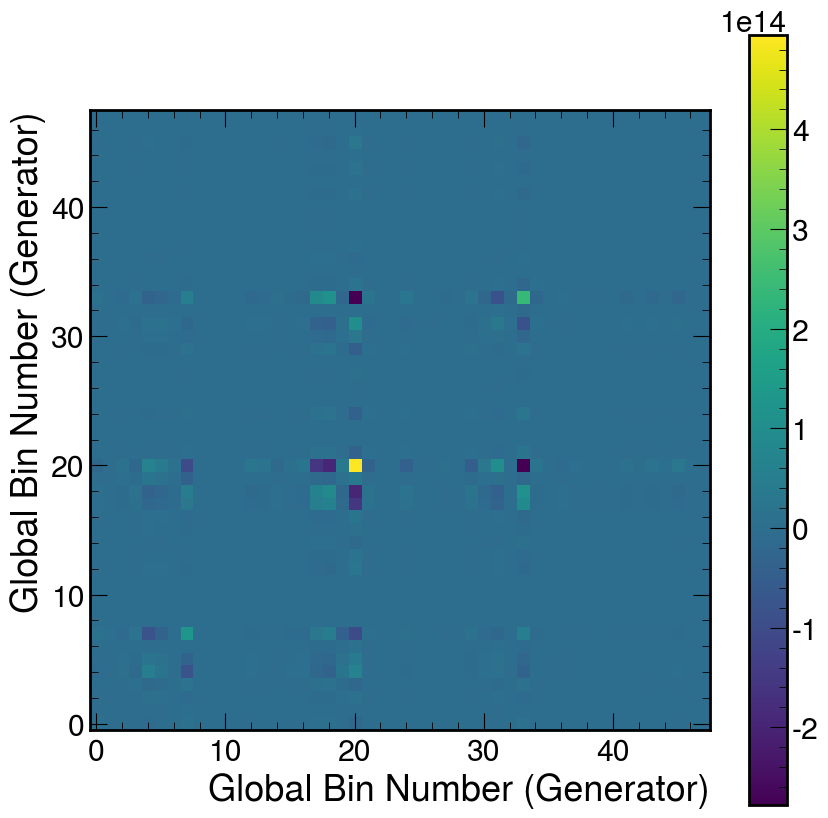

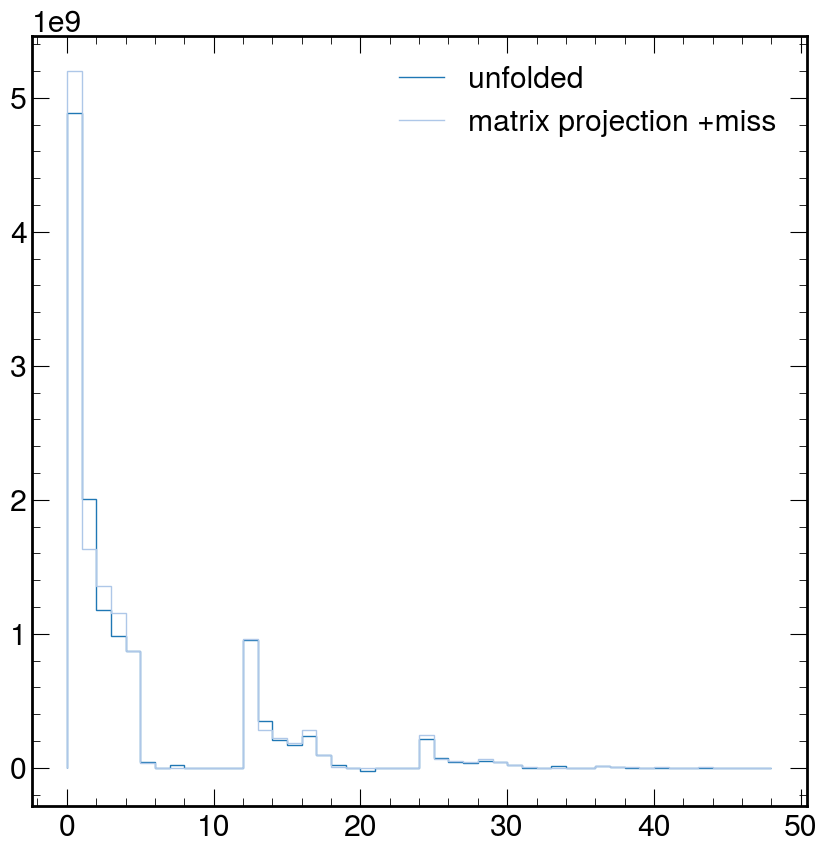

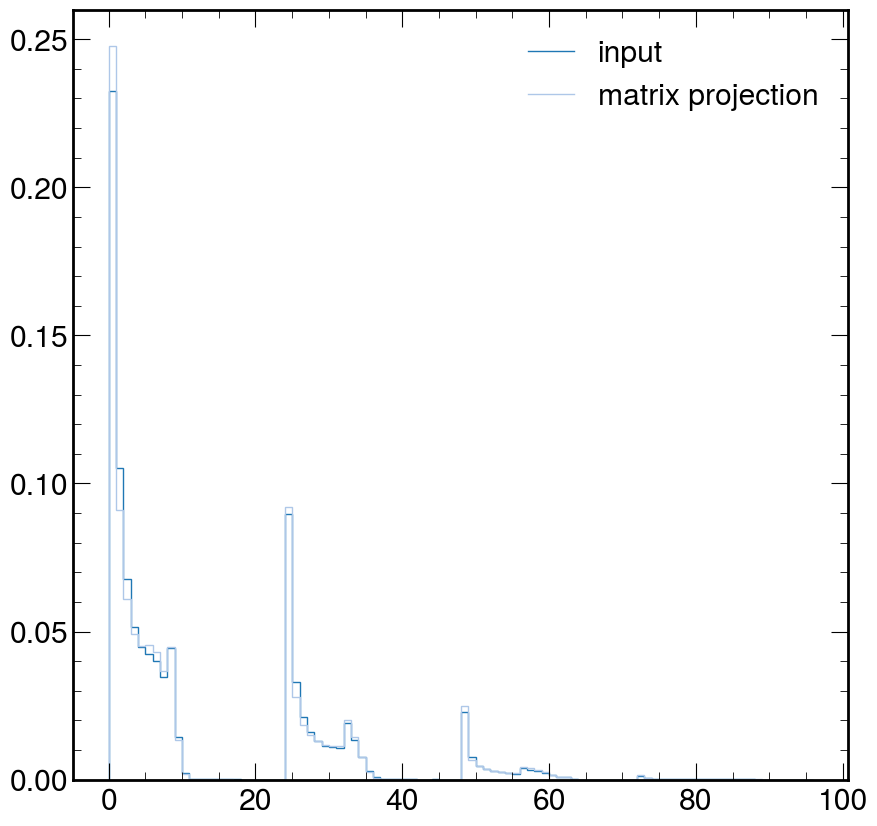

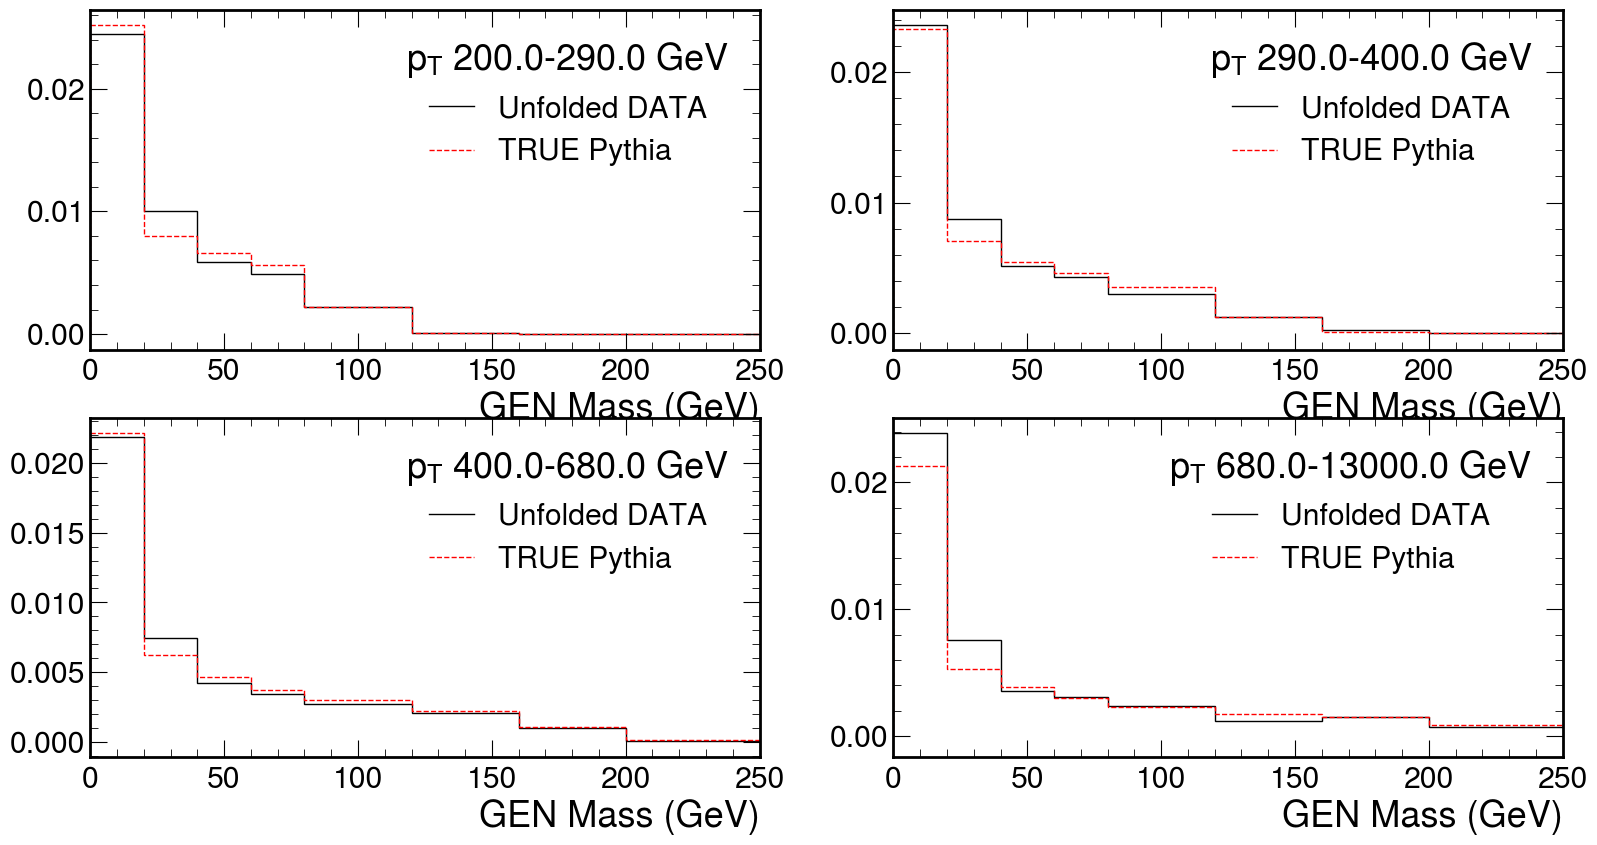

In [32]:
# Plot the covariance matrix or unfolded distributions:
unfolder.plot_covariance()
unfolder.plot_unfolded()

/tmp/ipykernel_1869/3397195002.py:8: RuntimeWarning: invalid value encountered in divide
  hep.histplot(accepted[ipt]/(missed[ipt] + accepted[ipt]), mgen_edge, yerr = accepted_unc[ipt]/(missed[ipt] + accepted[ipt]), color = color_pt[ipt], label = title_list[ipt])
/tmp/ipykernel_1869/3397195002.py:8: RuntimeWarning: invalid value encountered in divide
  hep.histplot(accepted[ipt]/(missed[ipt] + accepted[ipt]), mgen_edge, yerr = accepted_unc[ipt]/(missed[ipt] + accepted[ipt]), color = color_pt[ipt], label = title_list[ipt])
/tmp/ipykernel_1869/3397195002.py:8: RuntimeWarning: invalid value encountered in divide
  hep.histplot(accepted[ipt]/(missed[ipt] + accepted[ipt]), mgen_edge, yerr = accepted_unc[ipt]/(missed[ipt] + accepted[ipt]), color = color_pt[ipt], label = title_list[ipt])


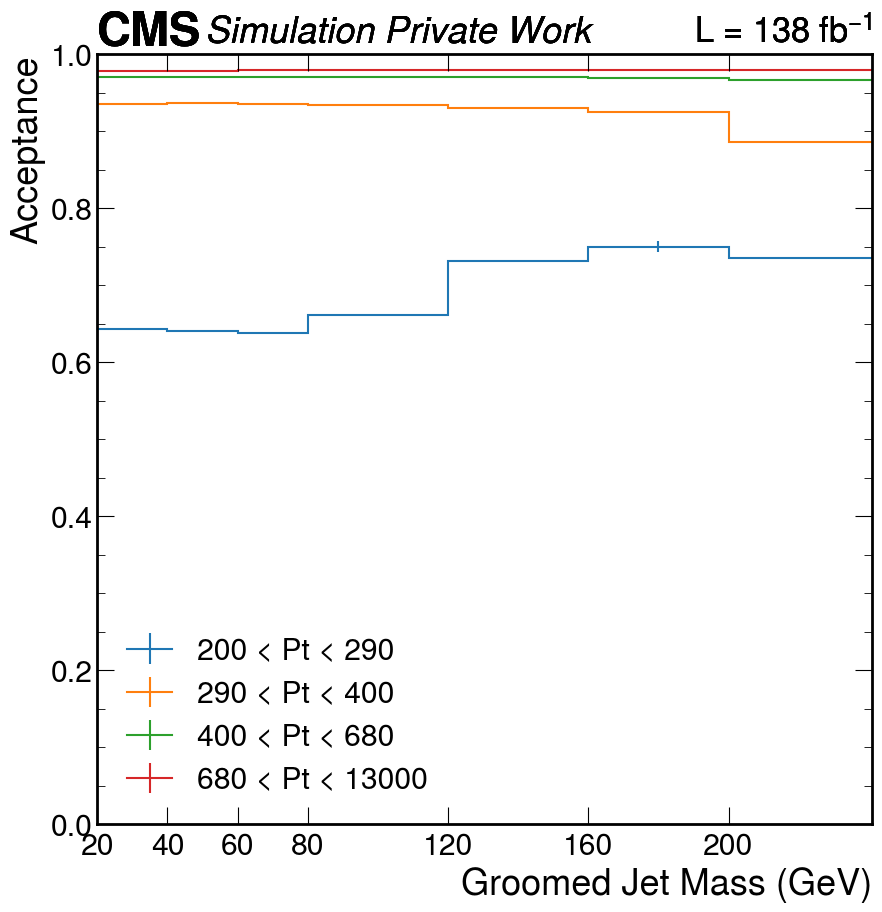

In [33]:

accepted = resp_matrix_4d[{'syst':'nominal'}].project('ptgen', 'mgen').values()
missed = misses.project('ptgen', 'mgen').values()
accepted_unc =resp_matrix_4d[{'syst':'nominal'}].project('ptgen', 'mgen').variances()**0.5
#mgen_edge[-1] = 240
title_list = [(str(pt_edges[ipt])+" < Pt < "+str(int(pt_edges[ipt+1]))) for ipt in range(len(pt_edges)-1)]
for ipt in range(len(pt_edges)-1):
    title = str(pt_edges[ipt])+" < Pt < "+str(int(pt_edges[ipt+1]))
    hep.histplot(accepted[ipt]/(missed[ipt] + accepted[ipt]), mgen_edge, yerr = accepted_unc[ipt]/(missed[ipt] + accepted[ipt]), color = color_pt[ipt], label = title_list[ipt])
    # Set x-ticks to bin edges
    xtick_labels = [str(int(tick)) for tick in mgen_edge]  # Convert to string
    xtick_labels[-1] = r"$\infty$"  # Replace last label with infinity
    plt.tick_params(axis='x', which='minor', top=False, bottom=False)

    plt.xticks(mgen_edge, xtick_labels)
    plt.ylim(0, 1.0)
    plt.legend()

    if groomed:
        plt.xlim(20,241)
        plt.xlabel("Groomed Jet Mass (GeV)")
    else:
        plt.xlim(10, 241)
        plt.xlabel("Ungroomed Jet Mass (GeV)")
    plt.ylabel("Acceptance")
    hep.cms.label("Private Work", rlabel = r'L = 138 $fb^{-1}$')

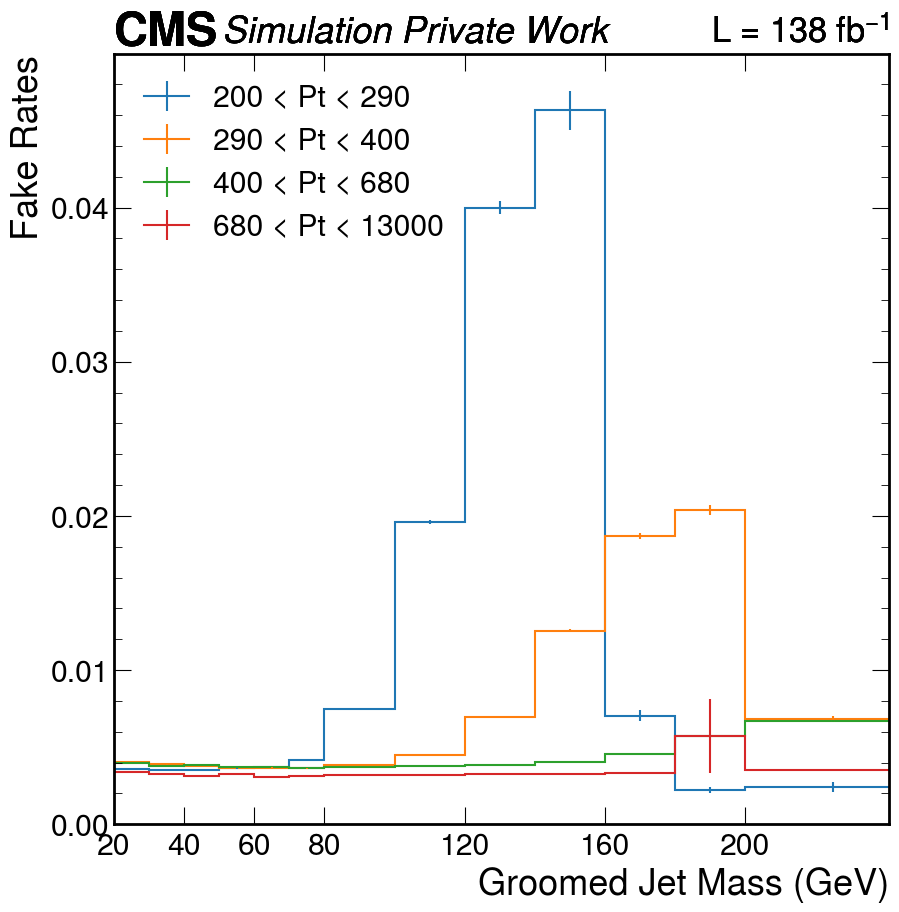

In [34]:

accepted_reco = resp_matrix_4d[{'syst':'nominal'}].project('ptreco', 'mreco').values()
faked = fakes.project('ptreco', 'mreco').values()
faked_unc =  fakes.project('ptreco', 'mreco').variances()**0.5
# mreco_edge[-2] = 220
# mreco_edge[-1] = 240
npt = len(pt_edges)-1
for ipt in range(npt):
    hep.histplot(faked[ipt]/(faked[ipt] + accepted_reco[ipt]), mreco_edge, yerr = faked_unc[ipt]/(faked[ipt] + accepted_reco[ipt]), color = color_pt[ipt], label = title_list[ipt])
    # Set x-ticks to bin edges
    xtick_labels = [str(int(tick)) for tick in mgen_edge]  # Convert to string
    xtick_labels[-1] = r"$\infty$"  # Replace last label with infinity
    plt.tick_params(axis='x', which='minor', top=False, bottom=False)

    plt.xticks(mgen_edge, xtick_labels)
    
    plt.legend()

    if groomed:
        plt.xlim(20,241)
        plt.xlabel("Groomed Jet Mass (GeV)")
    else:
        plt.xlim(10, 241)
        plt.xlabel("Ungroomed Jet Mass (GeV)")
    plt.ylabel("Fake Rates")
    hep.cms.label("Private Work", rlabel = r'L = 138 $fb^{-1}$')

/tmp/ipykernel_1869/2714060644.py:3: RuntimeWarning: invalid value encountered in divide
  hep.histplot(accepted[ipt]/(missed[ipt] + accepted[ipt]), mgen_edge, yerr = accepted_unc[ipt]/(missed[ipt] + accepted[ipt]), color = 'r', label = 'Acceptance')


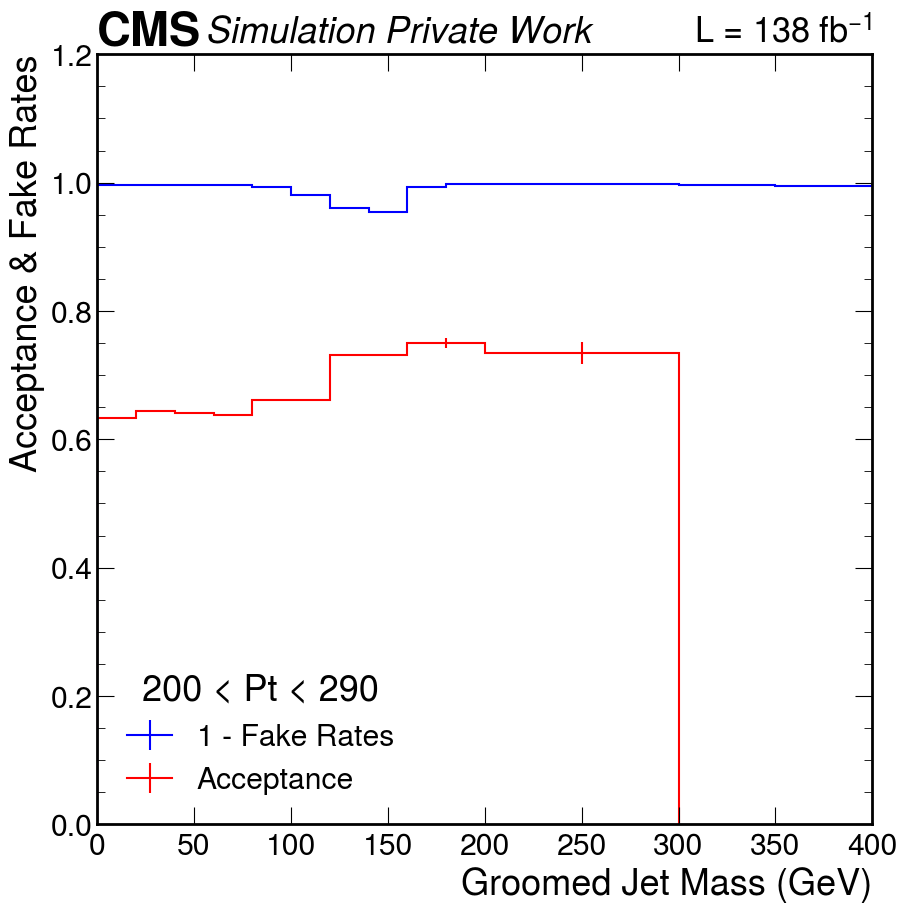

/tmp/ipykernel_1869/2714060644.py:3: RuntimeWarning: invalid value encountered in divide
  hep.histplot(accepted[ipt]/(missed[ipt] + accepted[ipt]), mgen_edge, yerr = accepted_unc[ipt]/(missed[ipt] + accepted[ipt]), color = 'r', label = 'Acceptance')


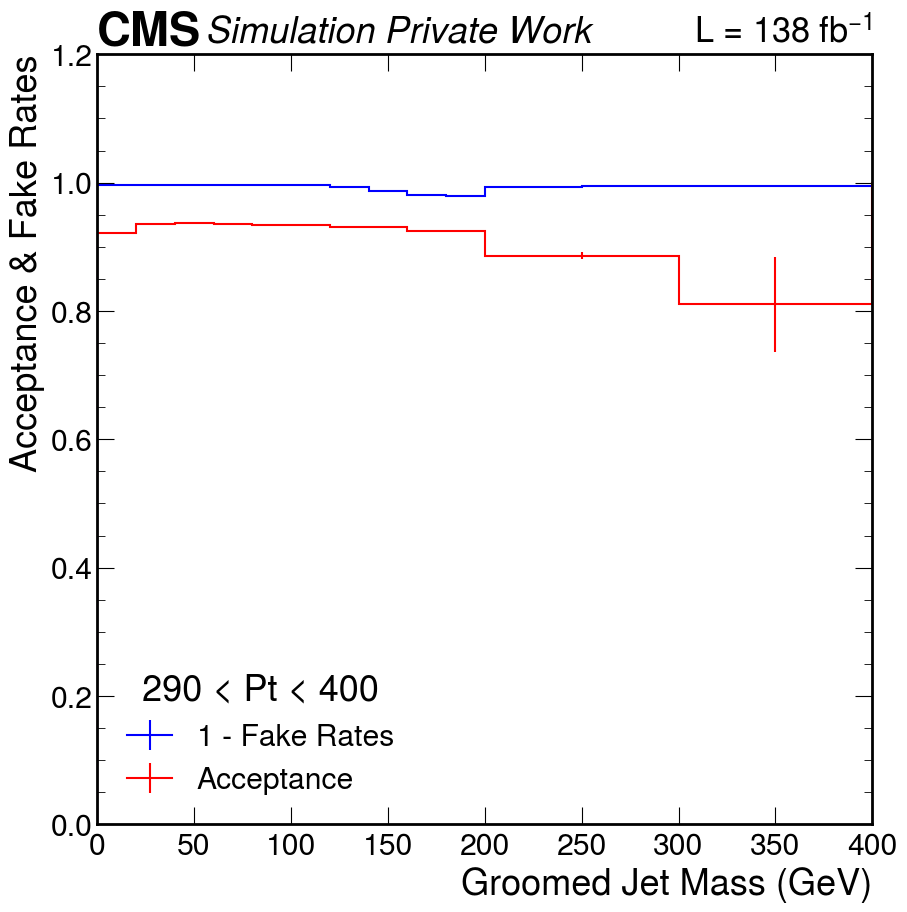

/tmp/ipykernel_1869/2714060644.py:3: RuntimeWarning: invalid value encountered in divide
  hep.histplot(accepted[ipt]/(missed[ipt] + accepted[ipt]), mgen_edge, yerr = accepted_unc[ipt]/(missed[ipt] + accepted[ipt]), color = 'r', label = 'Acceptance')


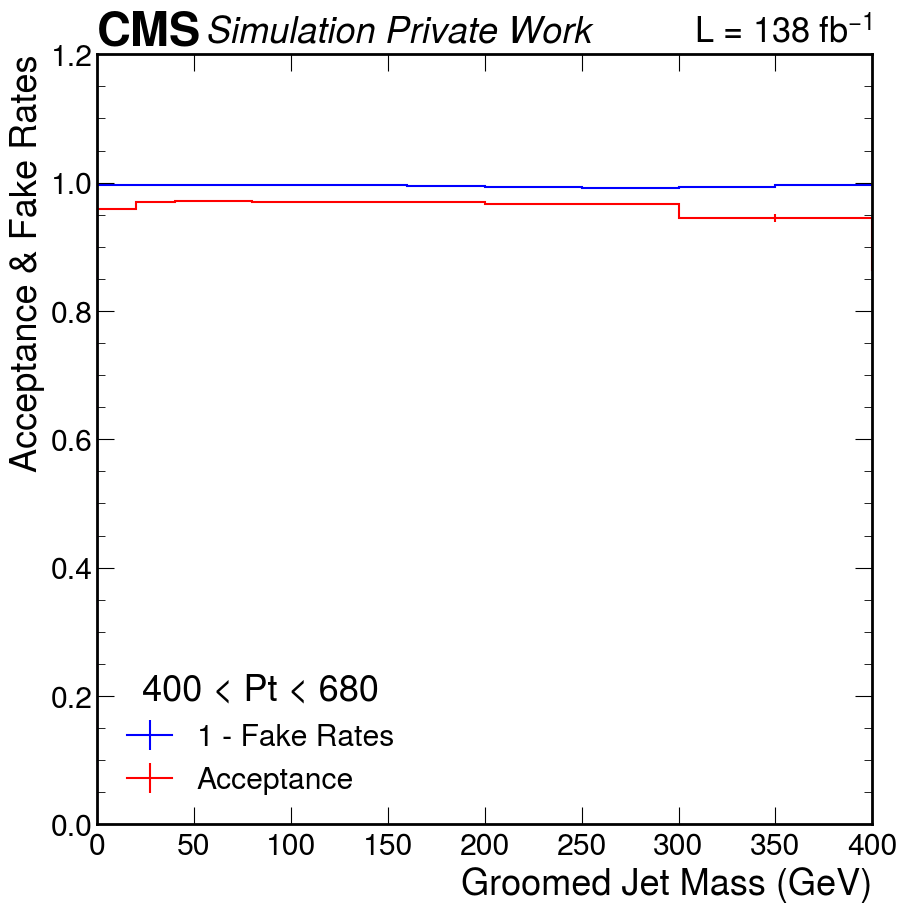

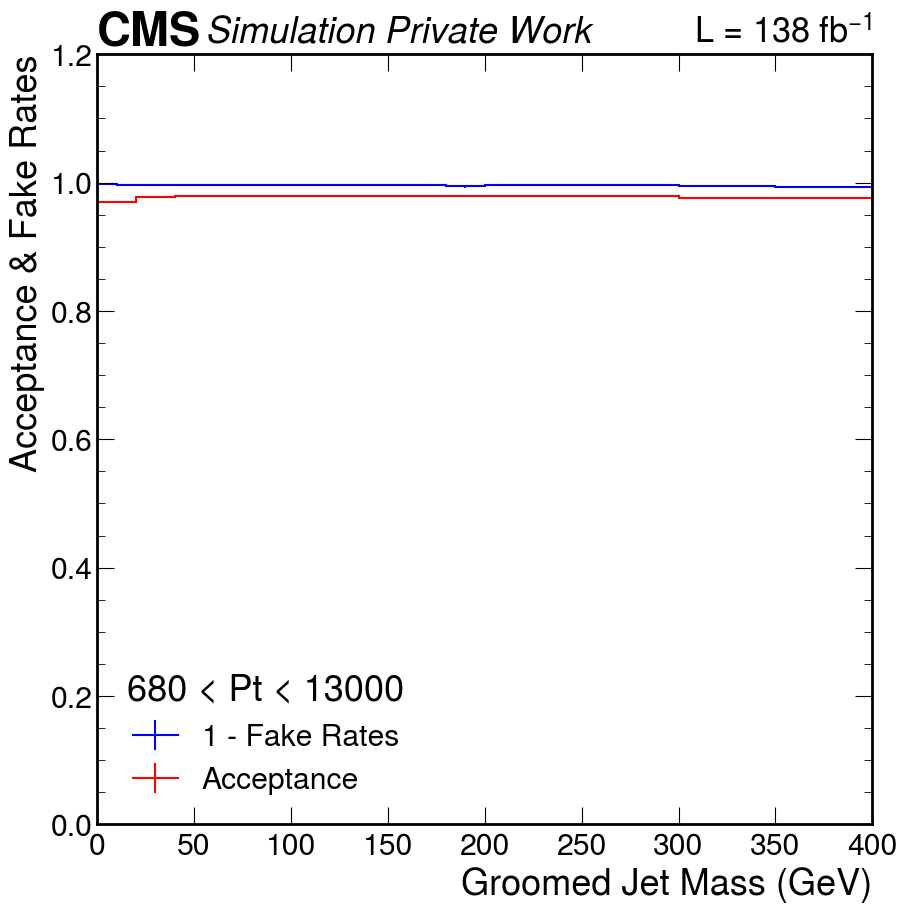

In [35]:
for ipt in range(npt):
    hep.histplot( 1 - (faked[ipt]/(faked[ipt] + accepted_reco[ipt])), mreco_edge, yerr = faked_unc[ipt]/(faked[ipt] + accepted_reco[ipt]), color = 'b', label = '1 - Fake Rates')
    hep.histplot(accepted[ipt]/(missed[ipt] + accepted[ipt]), mgen_edge, yerr = accepted_unc[ipt]/(missed[ipt] + accepted[ipt]), color = 'r', label = 'Acceptance')

    xtick_labels = [str(int(tick)) for tick in mgen_edge]  # Convert to string
    xtick_labels[-1] = r"$\infty$"  # Replace last label with infinity
    plt.tick_params(axis='x', which='minor', top=False, bottom=False)

    # plt.xticks(mgen_edge, xtick_labels)
    
    plt.legend(title = title_list[ipt])
    if not groomed:
        plt.xlim(0,400)
        plt.xlabel("Ungroomed Jet Mass (GeV)")
    else:
        plt.xlim(0, 400)
        plt.xlabel("Groomed Jet Mass (GeV)")
    plt.ylabel("Acceptance & Fake Rates")
    plt.ylim(0, 1.2)
    hep.cms.label("Private Work", rlabel = r'L = 138 $fb^{-1}$')
    if single_year:
        if groomed:
            plt.savefig(f'../plots/unfolding/{channel}/fakerates_groomed{single_year}_{ipt}.pdf', bbox_inches='tight')
        else:
            plt.savefig(f'../plots/unfolding/{channel}/fakerates_ungroomed{single_year}_{ipt}.pdf', bbox_inches='tight')
    else:
        if groomed:
            plt.savefig(f'../plots/unfolding/{channel}/fakerates_groomed_{ipt}.pdf', bbox_inches='tight')
        else:
            plt.savefig(f'../plots/unfolding/{channel}/fakerates_ungroomed_{ipt}.pdf', bbox_inches='tight')
    plt.show()

In [36]:
# hist_true = resp_matrix_4d
# total_sys_pt_binned = unfolder.total_sys_pt_binned
# stat_unc = unfolder.stat_mat_pt_binned
# tot_unc = (np.array(unfolder.stat_mat_pt_binned)**2+np.array(stat_unc)**2)**0.5
# plotStackedOutput(hist_true, unfolder.output_pt_binned, tot_unc, stat_unc, closure=closure, channel=channel)

In [37]:
# hist_true = resp_matrix_4d
# total_sys_pt_binned = unfolder.total_sys_pt_binned
# nan_map = np.ones_like(unfolder.output_pt_binned)
# nan_map[:, 1] = 0
# nan_map[:4, -2:] = 0.
# nan_map[0, -4:] = 0.
# nan_map[1, -3:] = 0.
# print(nan_map)
# plotUnfoldOutputHist(hist_true, unfolder.output_pt_binned, total_sys_pt_binned, unfolder.stat_mat_pt_binned, channel =channel, groomed=groomed, closure = closure, trim=500., mask = nan_map)

In [38]:
# m3 = resp_matrix_4d[{'systematic':'nominal'}].project('ptgen', 'mgen', 'ptreco', 'mreco')[:,:, sum, hist.rebin(2)].values()
# plt.figure(figsize = (20, 20))
# for ipt in range(4):
#     m30 = m3[ipt]
#     plt.subplot(2, 2, ipt+1)
    
#     hep.histplot(np.diag(m3[ipt])/m3[ipt].sum(axis = 1),mgen_edge, label = 'Stability')
#     hep.histplot(np.diag(m3[ipt])/m3[ipt].sum(axis = 0),mgen_edge, label = 'Purity', color = 'r')
#     plt.xlim(20,250)
#     plt.xlabel("Ungroomed Jet Mass (GeV)")
#     plt.ylabel("Fraction")
#     plt.legend(title = title_list[ipt])
#     xtick_labels = [str(int(tick)) for tick in mgen_edge]  # Convert to string
#     xtick_labels[-1] = r"$\infty$"  # Replace last label with infinity
#     plt.tick_params(axis='x', which='minor', top=False, bottom=False)

#     plt.xticks(mgen_edge, xtick_labels)
#     #plt.show()

In [39]:
if groomed:
    key = 'response_matrix_g'
else:
    key = 'response_matrix_u'

# unfolder = Unfolder(input_data, 
#                     resp_matrix_4d[{'syst':'nominal'}] ,
#                     #resp_matrix_4d_jk,
#                     fakes = fakes[: , 'nominal', :,:,:],
#                     misses = misses,
#                     backgrounds = None,
#                     #systematics = custom_sys_dic,
#                     systematics = sys_matrix_dic,
#                     #systematics= None,
#                     #systematics = jes_sys_list_up,
#                     closure = False,
#                     groomed = groomed,
#                     is_uf = True,
#                     merge = False,
#                     normalized_syst = True,
#                     do_syst = True,
#                     discard_low_bins = False,
#                     regularisation= 'ScanSURE',
#                     do_norm = False
#                            )
# output_nominal, matrix_plot = unfold_using_matrix(input_data, resp_matrix_4d[{'systematic':'nominal'}] , fakes, misses,
#                             backgrounds = {"ww": ww_bg, "wz":wz_bg, "zz": zz_bg},
#                             #systematics = {'JES_AbsoluteMPFBiasUp': resp_matrix_4d[{'systematic':'JES_AbsoluteMPFBiasUp'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()  },
#                             systematics = sys_matrix_dic,
#                             closure = closure,
#                             groomed = groomed,
#                             is_uf = True,
#                             merge = False,
#                             normalised_xs = True,
#                             do_syst = True,
#                             discard_low_bins = False,
#                             regularisation= 'ScanSURE',
#                             plot = True
#                                     )

#unfolder.plot_response_matrix()


unfolder_dn = Unfolder(input_data, 
                    resp_matrix_4d[{'syst':'nominal'}] ,
                    #resp_matrix_4d_jk,
                    fakes = fakes,
                    misses = misses,
                    backgrounds = None,
                    #systematics = {'JES_AbsoluteMPFBiasUp': resp_matrix_4d[{'systematic':'JES_AbsoluteMPFBiasUp'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()  },
                    systematics = sys_matrix_dic_down,
                    #systematics= None,
                    #systematics = jes_sys_list_up,
                    closure = False,
                    groomed = groomed,
                    is_uf = True,
                    merge = False,
                    normalised_xs = True,
                    normalized_syst = True,
                    do_syst = True,
                    discard_low_bins = False,
                    regularisation= 'None',
                    do_norm = False
                           )

12
[   0.   20.   40.   60.   80.  120.  160.  200.  300.  400.  500.  900.
 1300.]
24
[   0.   10.   20.   30.   40.   50.   60.   70.   80.  100.  120.  140.
  160.  180.  200.  250.  300.  350.  400.  450.  500.  700.  900. 1100.
 1300.]
Signal Binning created
Detector Binning created
shape of you (96,)


/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:176: RuntimeWarning: invalid value encountered in divide
  self.miss_frac = self.miss_values/ ( self.M_np.sum(axis = 1))


Working until background subtractions
Unfolder object created
Condition number of the matrix  1.6902869697482985e+18


Warning in <TROOT::Append>: Replacing existing TH1: M (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_reco (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htrue (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htruef (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_corr (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_uncorr_2016 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_uncorr_2017 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_uncorr_2018 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteScaleUp_corr (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing 

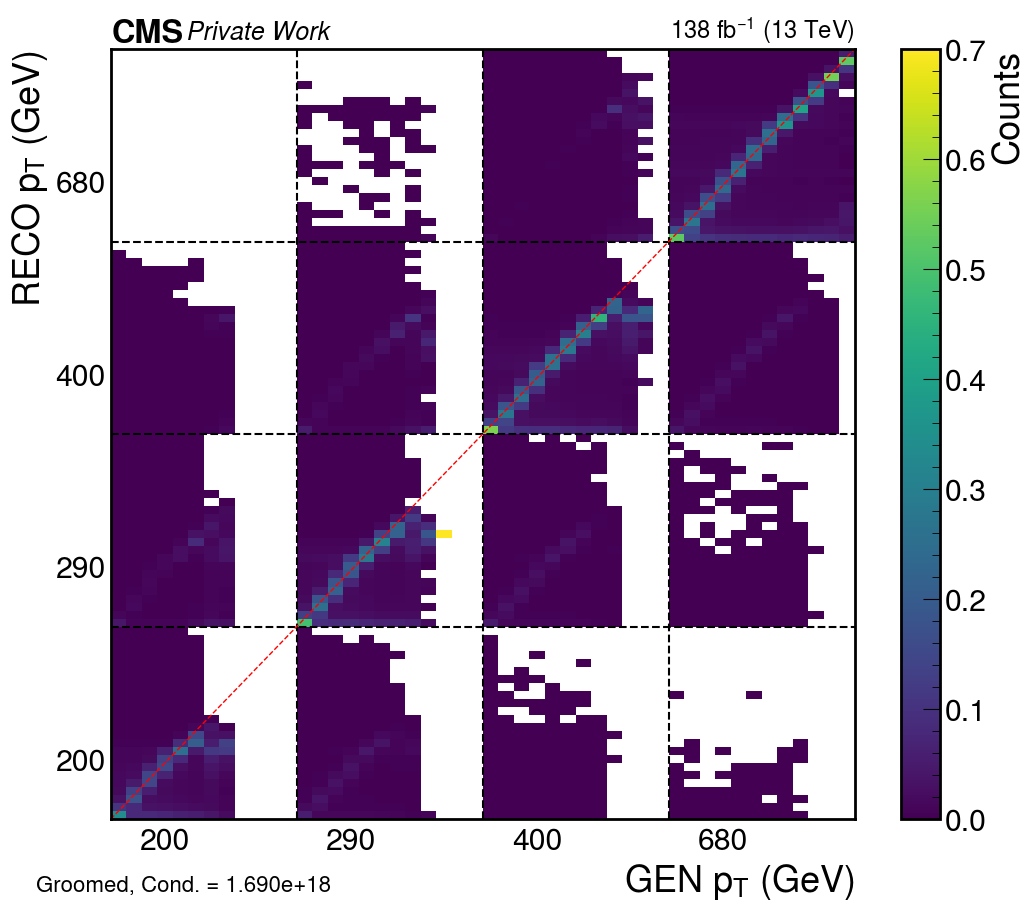

In [40]:
unfolder.plot_response_matrix(probability_matrix=True)


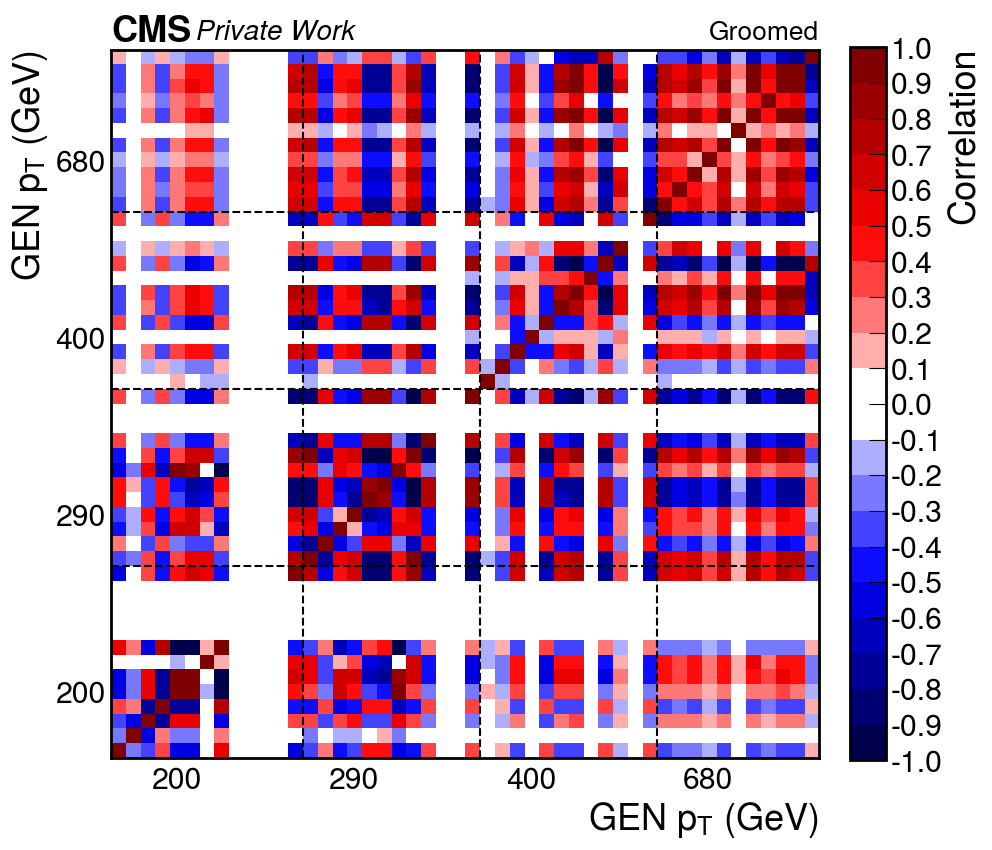

In [41]:
ax = unfolder.plot_correlation()
if groomed:
    hep.cms.label("Private Work" , fontsize = 20, data = True, ax = ax, rlabel = "Groomed")
else:
    hep.cms.label("Private Work" , fontsize = 20, data = True, ax = ax, rlabel = "Ungroomed")

Working until background subtractions
Unfolder object created
Regularisation USED None
Tau value 0.0


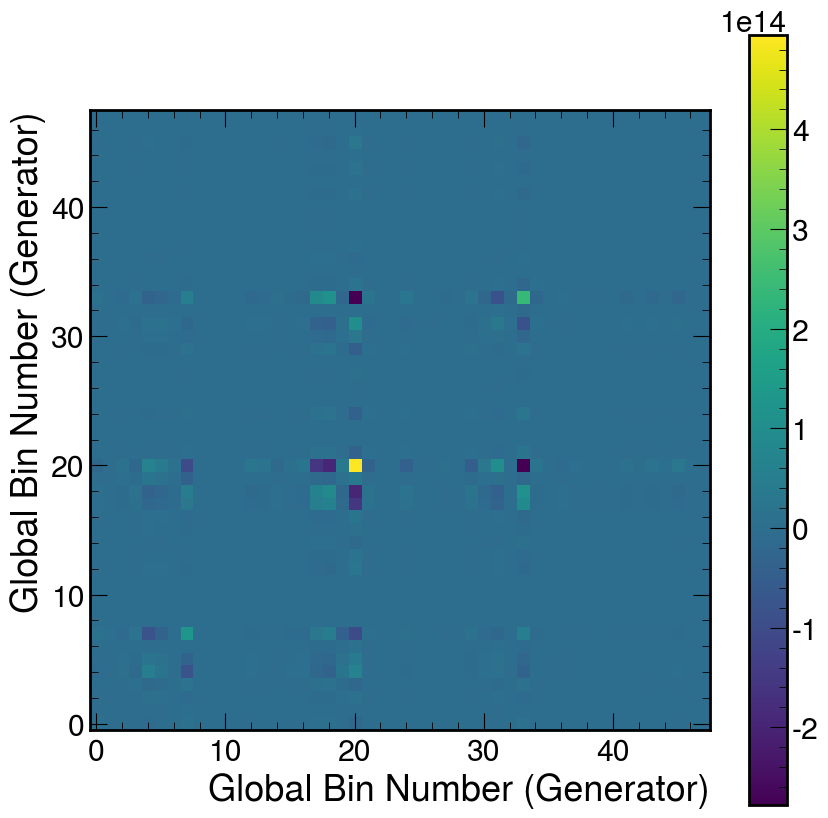

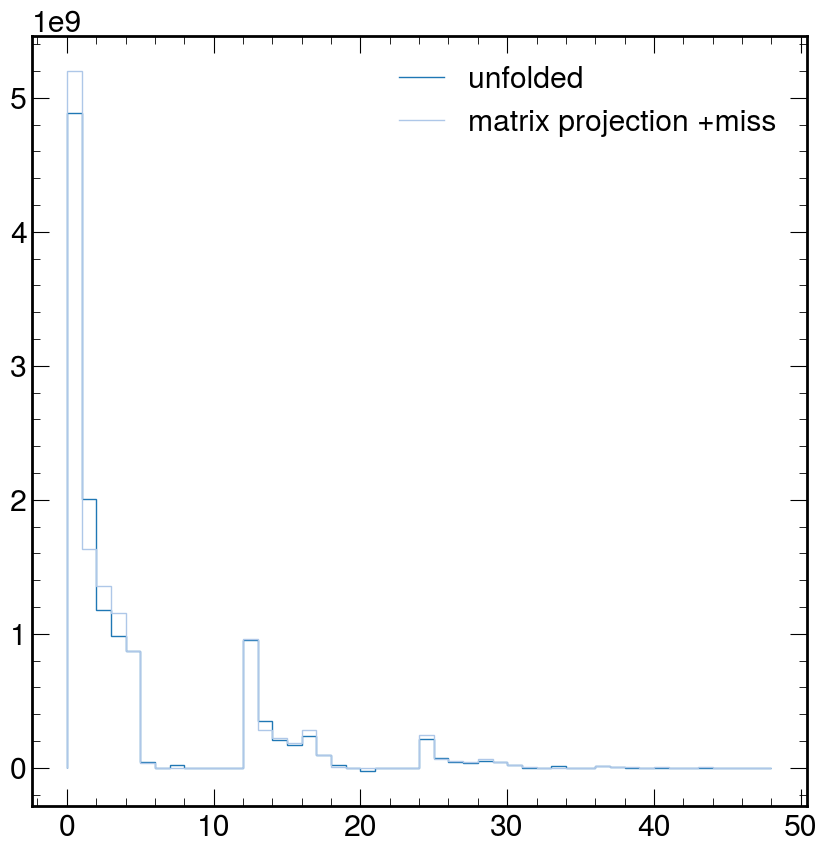

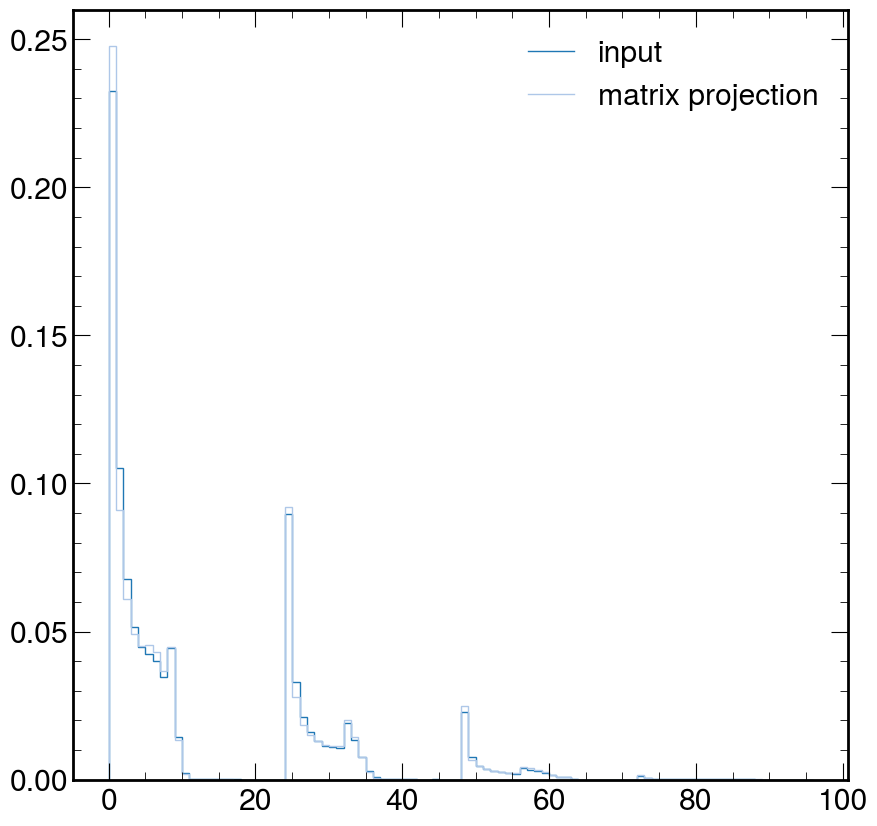

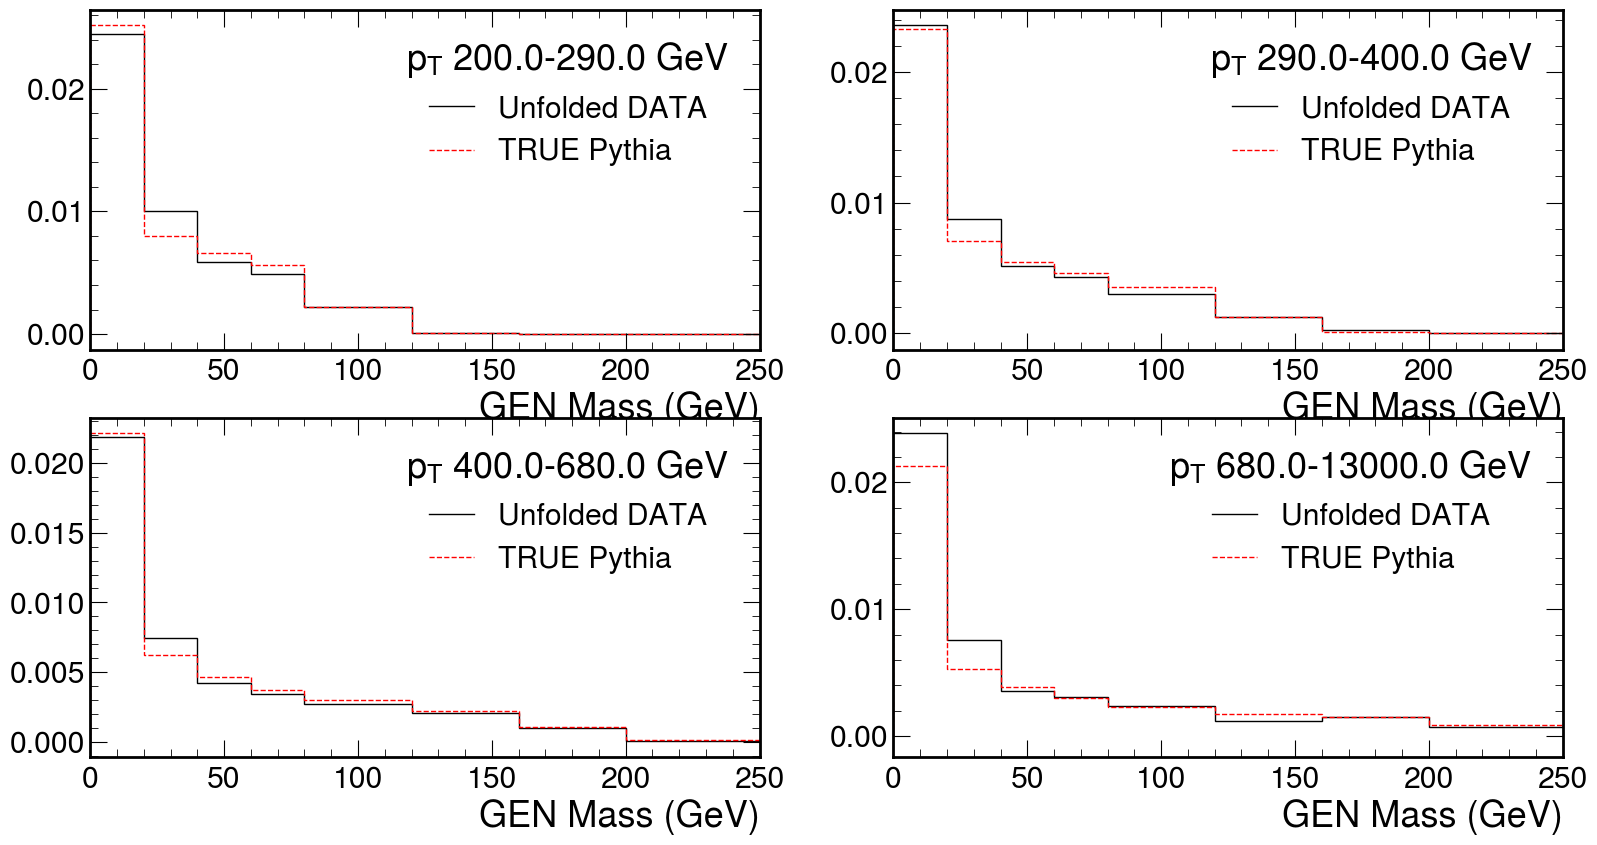

Warning in <TROOT::Append>: Replacing existing TH1: M (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_reco (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htrue (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htruef (Potential memory leak).
Info in <TUnfold::SetConstraint>: fConstraint=1
Warning in <TUnfold::TUnfold>: 9 output bins do not depend on the input data  0 9-12 23-24 36 49
Info in <TUnfold::TUnfold>: 96 input bins and 41 output bins
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #0
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #9 (signal:ptgen[200,290]:massgen[300,400])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #10 (signal:ptgen[200,290]:massgen[400,500])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #11 (signal:ptgen[200,290]:massgen[500,900])
Info in <TUnfoldDensity::TUn

In [42]:
unfolder_dn.perform_unfold()

# Plot the covariance matrix or unfolded distributions:
unfolder_dn.plot_covariance()
unfolder_dn.plot_unfolded()

In [43]:
print(unfolder_dn.delta_sys_dic_pt_binned.keys())
# plt.stairs(np.abs(unfolder_dn.output_pt_binned[0]-unfolder_dn.o_sys_dic_pt_binned['jmrDown'][0])/unfolder_dn.output_pt_binned[0])
# plt.stairs(np.abs(unfolder.output_pt_binned[0]-unfolder.o_sys_dic_pt_binned['jmrUp'][0])/unfolder.output_pt_binned[0])


dict_keys(['JES_AbsoluteMPFBiasDown_corr', 'JES_AbsoluteMPFBiasDown_uncorr_2016', 'JES_AbsoluteMPFBiasDown_uncorr_2017', 'JES_AbsoluteMPFBiasDown_uncorr_2018', 'JES_AbsoluteScaleDown_corr', 'JES_AbsoluteScaleDown_uncorr_2016', 'JES_AbsoluteScaleDown_uncorr_2017', 'JES_AbsoluteScaleDown_uncorr_2018', 'JES_AbsoluteStatDown_corr', 'JES_AbsoluteStatDown_uncorr_2016', 'JES_AbsoluteStatDown_uncorr_2017', 'JES_AbsoluteStatDown_uncorr_2018', 'JES_FlavorQCDDown_corr', 'JES_FlavorQCDDown_uncorr_2016', 'JES_FlavorQCDDown_uncorr_2017', 'JES_FlavorQCDDown_uncorr_2018', 'JES_FragmentationDown_corr', 'JES_FragmentationDown_uncorr_2016', 'JES_FragmentationDown_uncorr_2017', 'JES_FragmentationDown_uncorr_2018', 'JES_PileUpDataMCDown_corr', 'JES_PileUpDataMCDown_uncorr_2016', 'JES_PileUpDataMCDown_uncorr_2017', 'JES_PileUpDataMCDown_uncorr_2018', 'JES_PileUpPtBBDown_corr', 'JES_PileUpPtBBDown_uncorr_2016', 'JES_PileUpPtBBDown_uncorr_2017', 'JES_PileUpPtBBDown_uncorr_2018', 'JES_PileUpPtEC1Down_corr', 'J

Bin  0
Bin  1
Bin  2
Bin  3


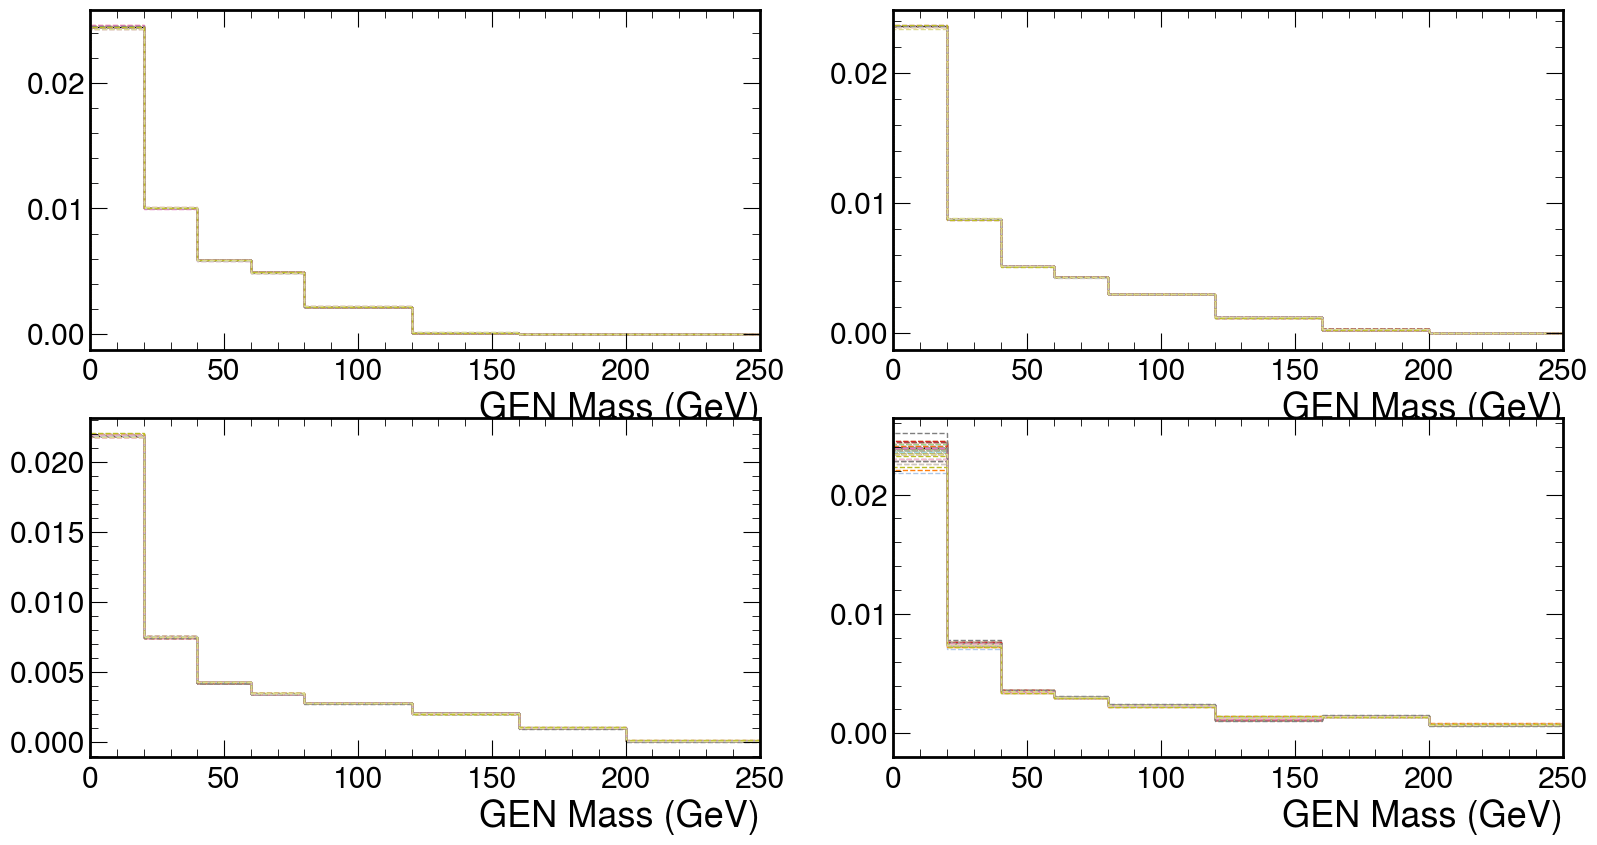

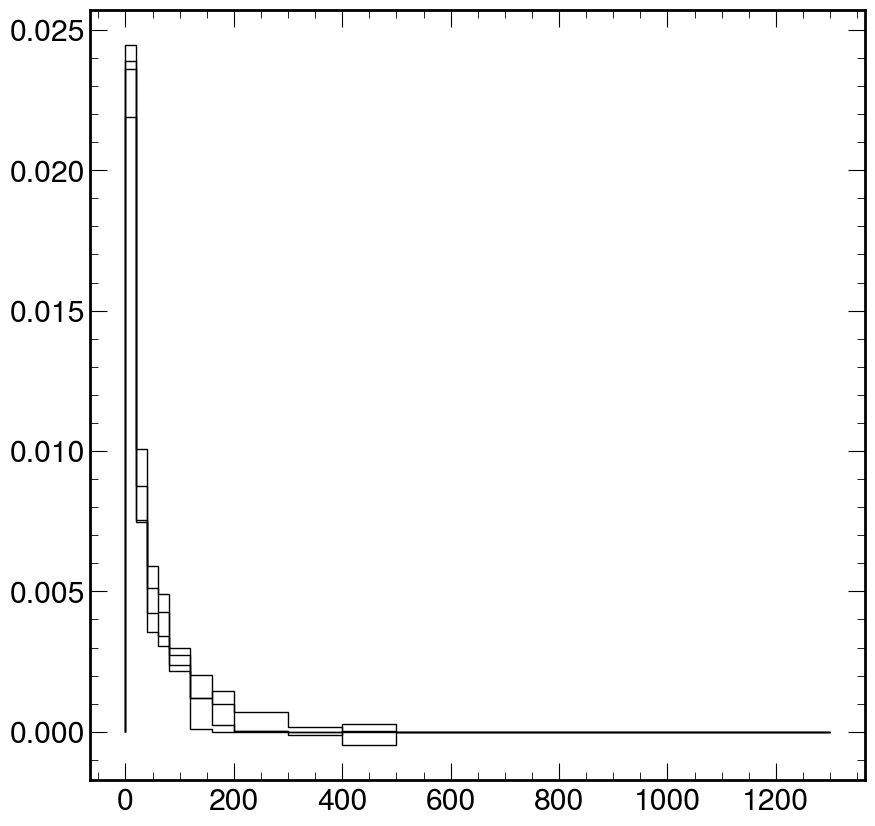

In [44]:
unfolder_dn.plot_output_sys()

/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:853: RuntimeWarning: invalid value encountered in divide
  plt.stairs(np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge , label = sys )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:855: RuntimeWarning: invalid value encountered in divide
  plt.stairs(total_sys_jes[i*self.nmbinsGen  :(i+1)*self.nmbinsGen]/np.abs(self.output_pt_binned[i]), self.mgen_edge , label = "JESUp" )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:856: RuntimeWarning: invalid value encountered in divide
  plt.stairs(self.total_sys[i*self.nmbinsGen  :(i+1)*self.nmbinsGen]/np.abs(self.output_pt_binned[i]), self.mgen_edge , label = "Total" )


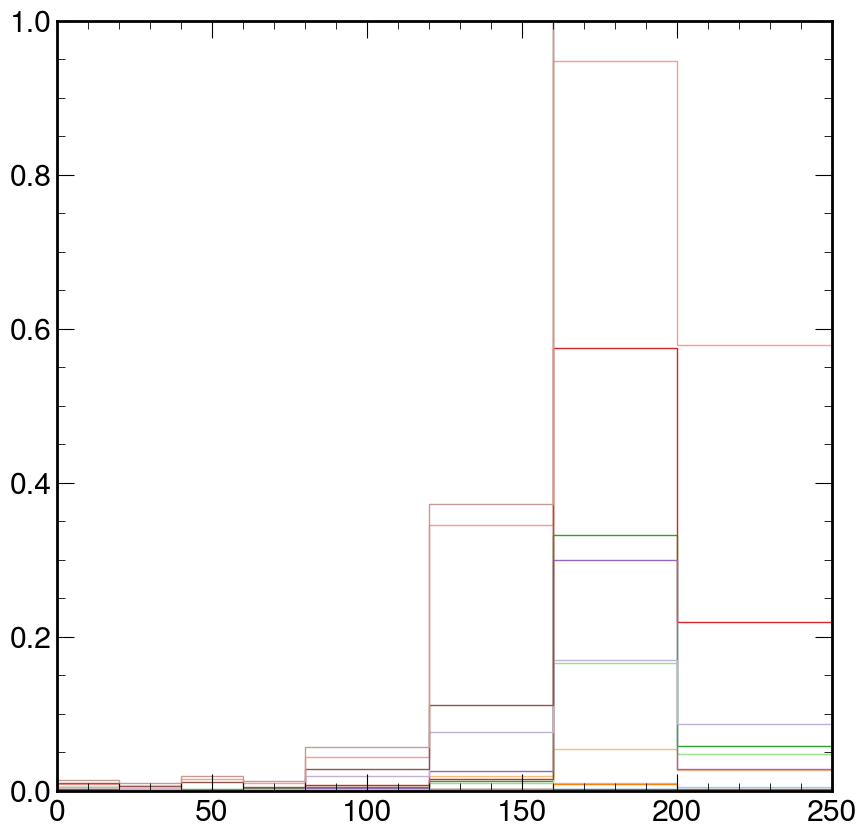

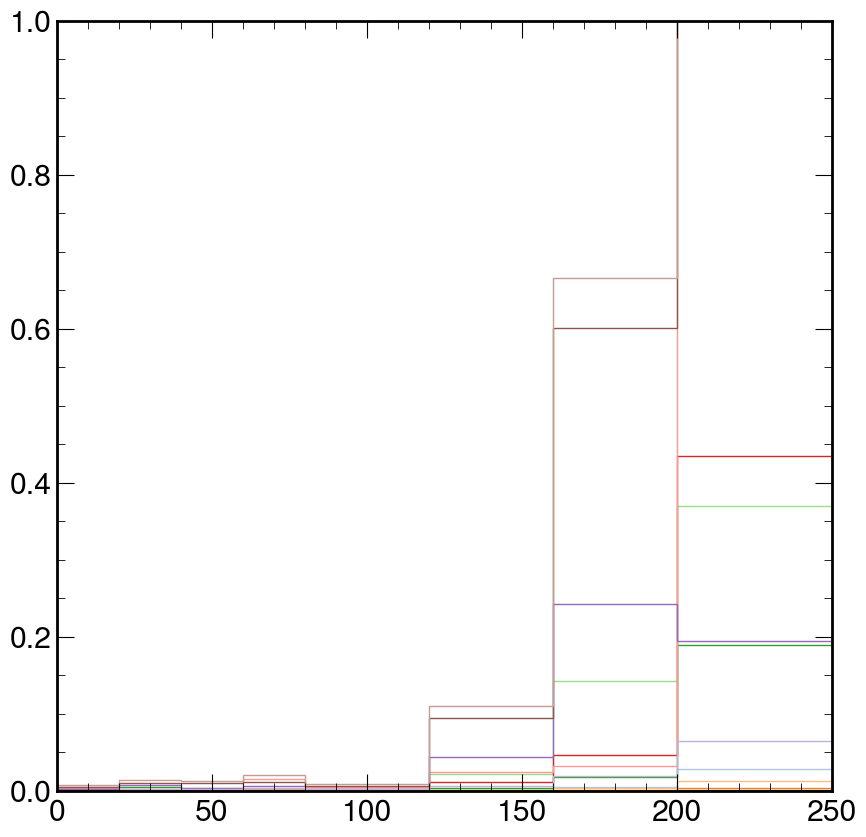

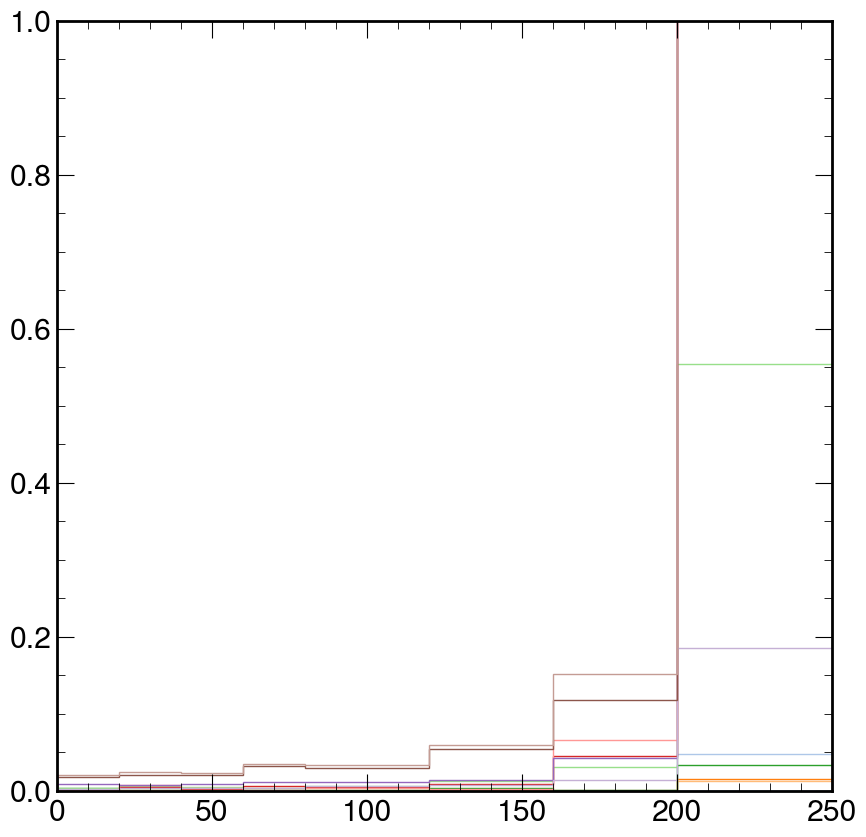

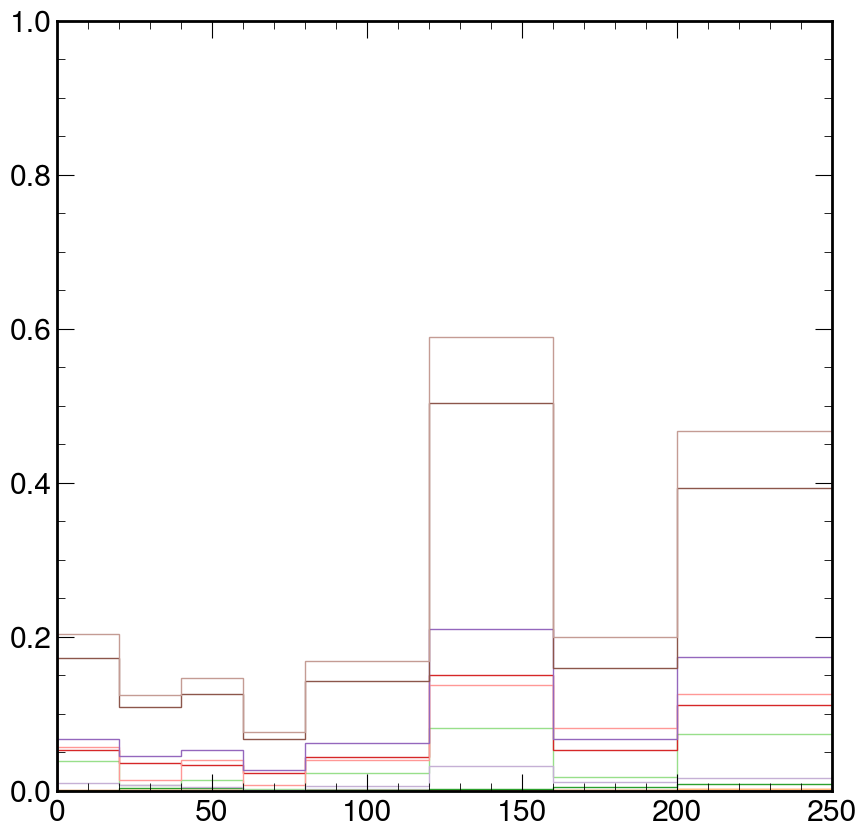

In [45]:
unfolder_dn.plot_systematic_frac()
# print(unfolder.delta_sys_dic['herwigUp'])

indices where tot unc > 0.6  []
range(0, 10)
12
0.004563854002168679


/tmp/ipykernel_1869/1290259568.py:56: RuntimeWarning: invalid value encountered in divide
  sys_vals = np.abs(delta_sys_dic[sys][i*nmbinsGen  :(i+1)*nmbinsGen])/np.abs(output_pt_binned[i])
/tmp/ipykernel_1869/1290259568.py:60: RuntimeWarning: invalid value encountered in divide
  plt.stairs(total_sys_jes[i*nmbinsGen  :(i+1)*nmbinsGen]/np.abs(output_pt_binned[i]), mgen_edge , label = "JES" , color="red", linewidth = 2.0)
/tmp/ipykernel_1869/1290259568.py:61: RuntimeWarning: invalid value encountered in divide
  plt.stairs(total_sys[i*nmbinsGen  :(i+1)*nmbinsGen]/np.abs(output_pt_binned[i]),  mgen_edge , color='black', linewidth=2.0,label = "Total Syst." )


range(0, 10)
12
0.0013266823057373445


/tmp/ipykernel_1869/1290259568.py:56: RuntimeWarning: invalid value encountered in divide
  sys_vals = np.abs(delta_sys_dic[sys][i*nmbinsGen  :(i+1)*nmbinsGen])/np.abs(output_pt_binned[i])
/tmp/ipykernel_1869/1290259568.py:60: RuntimeWarning: invalid value encountered in divide
  plt.stairs(total_sys_jes[i*nmbinsGen  :(i+1)*nmbinsGen]/np.abs(output_pt_binned[i]), mgen_edge , label = "JES" , color="red", linewidth = 2.0)
/tmp/ipykernel_1869/1290259568.py:61: RuntimeWarning: invalid value encountered in divide
  plt.stairs(total_sys[i*nmbinsGen  :(i+1)*nmbinsGen]/np.abs(output_pt_binned[i]),  mgen_edge , color='black', linewidth=2.0,label = "Total Syst." )


range(0, 10)
12
0.0011990632897452547


/tmp/ipykernel_1869/1290259568.py:56: RuntimeWarning: invalid value encountered in divide
  sys_vals = np.abs(delta_sys_dic[sys][i*nmbinsGen  :(i+1)*nmbinsGen])/np.abs(output_pt_binned[i])
/tmp/ipykernel_1869/1290259568.py:60: RuntimeWarning: invalid value encountered in divide
  plt.stairs(total_sys_jes[i*nmbinsGen  :(i+1)*nmbinsGen]/np.abs(output_pt_binned[i]), mgen_edge , label = "JES" , color="red", linewidth = 2.0)
/tmp/ipykernel_1869/1290259568.py:61: RuntimeWarning: invalid value encountered in divide
  plt.stairs(total_sys[i*nmbinsGen  :(i+1)*nmbinsGen]/np.abs(output_pt_binned[i]),  mgen_edge , color='black', linewidth=2.0,label = "Total Syst." )


range(0, 10)
12
0.0003307042168072467


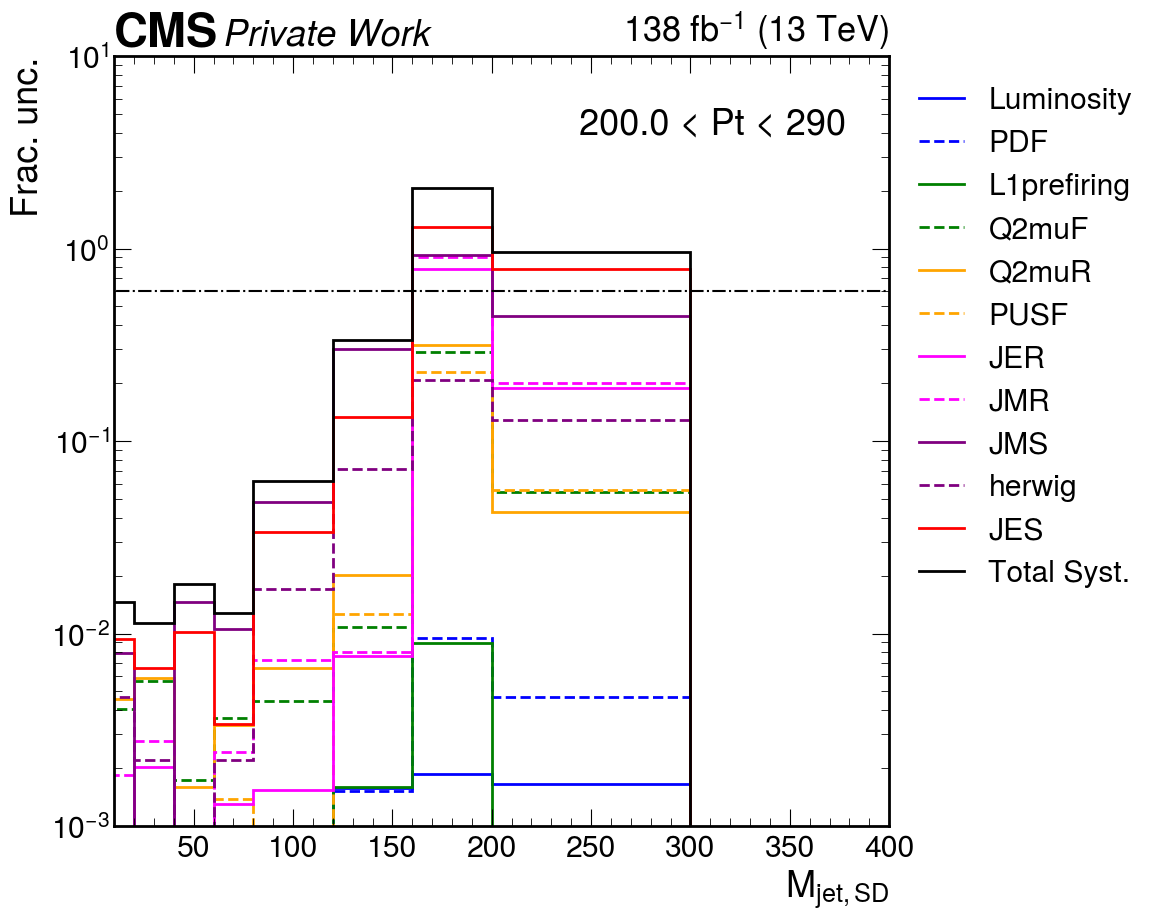

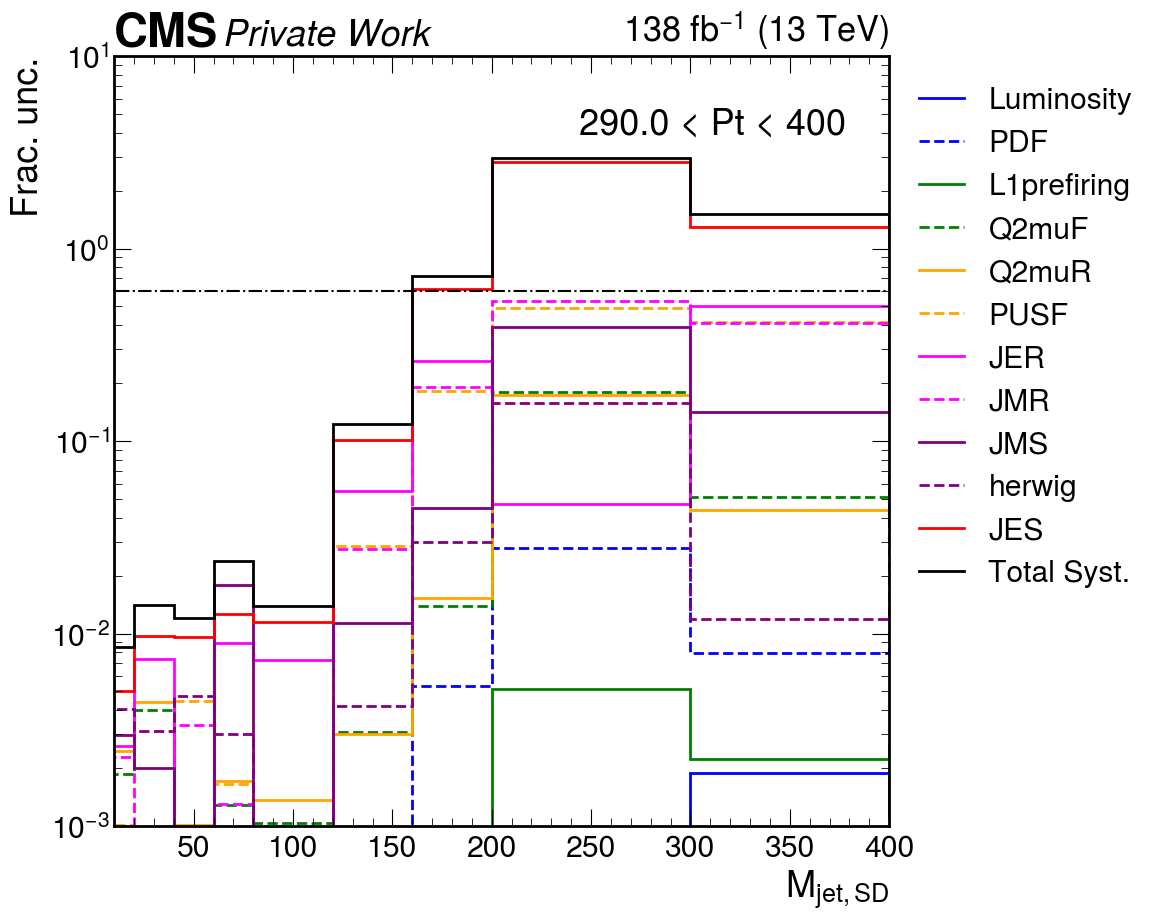

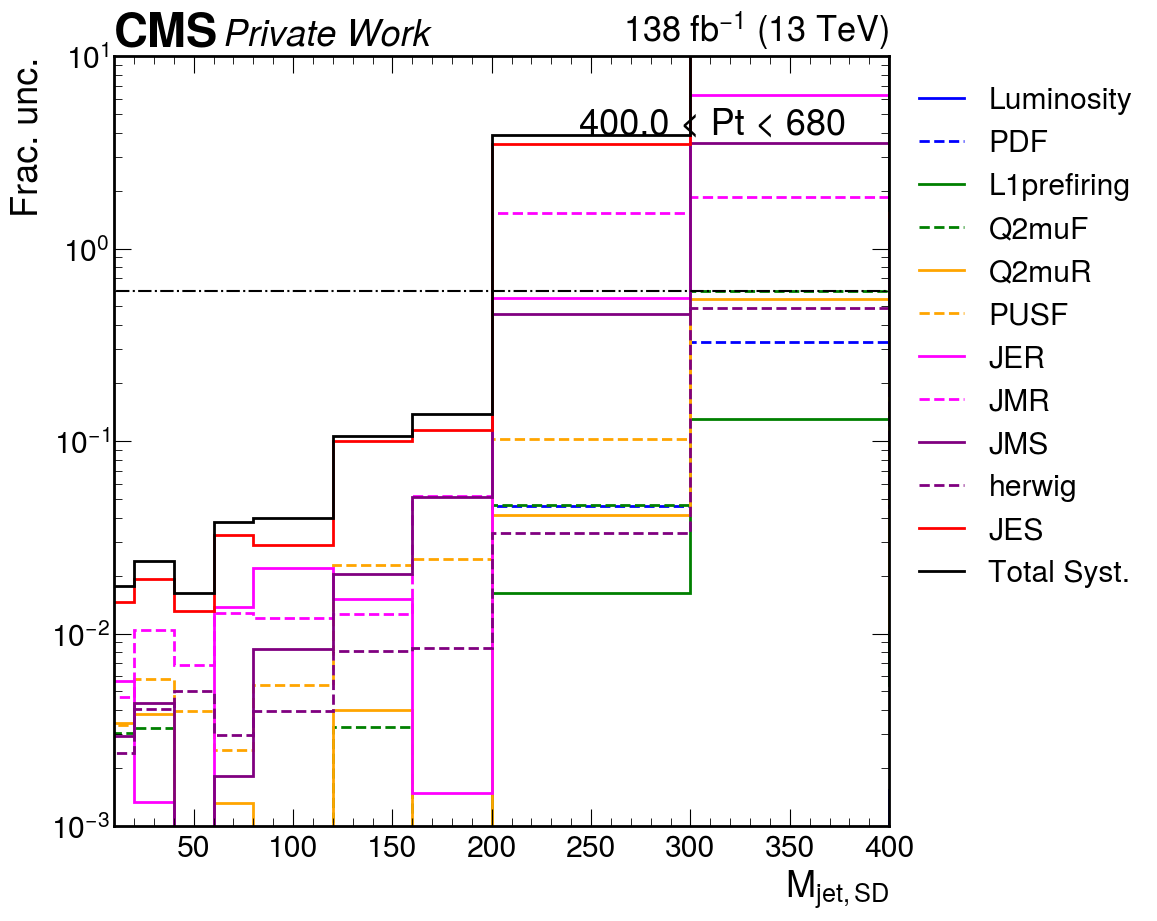

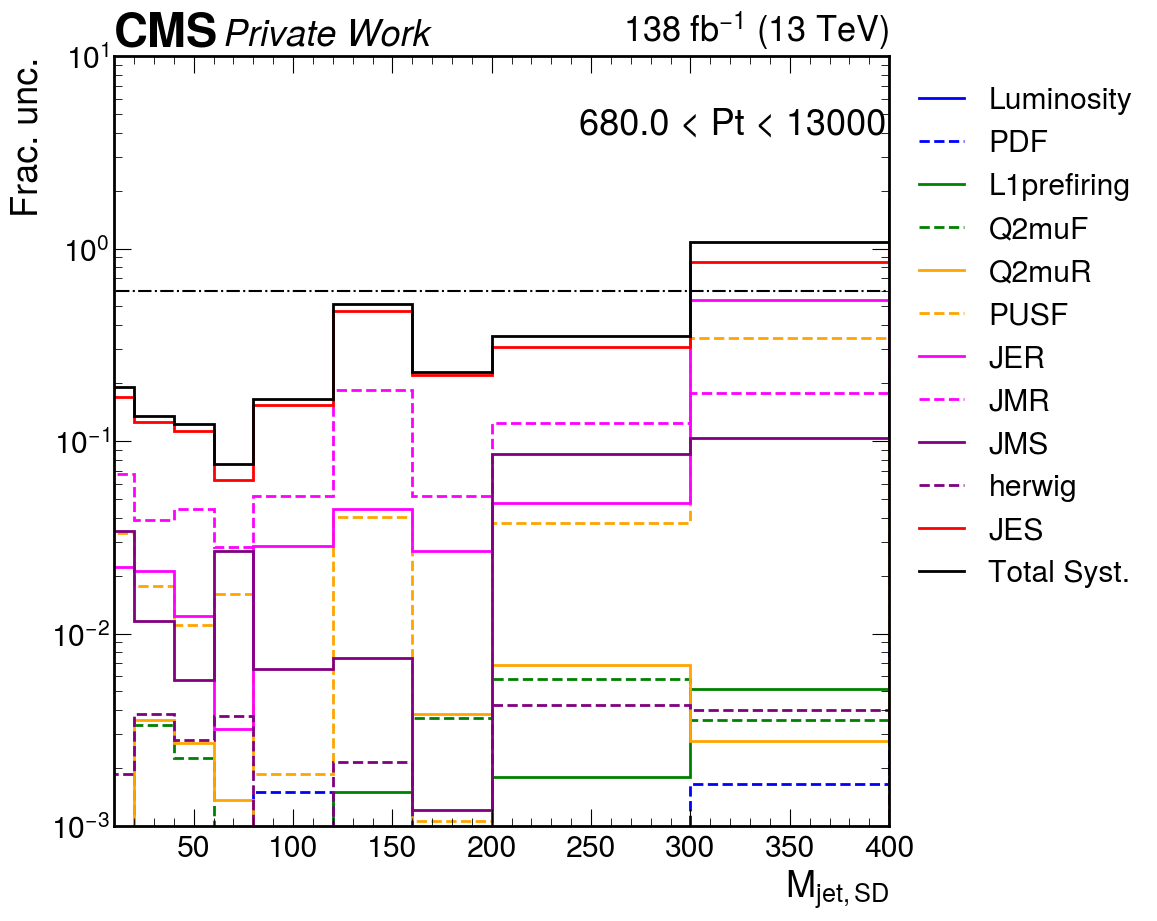

In [46]:
from matplotlib.ticker import LogLocator, NullFormatter
jes_sys_list = ['AbsoluteMPFBiasUp', 'AbsoluteMPFBiasDown', 'AbsoluteScaleUp', 
                 'AbsoluteScaleDown', 'AbsoluteStatUp', 'AbsoluteStatDown', 
                 'FlavorQCDUp', 'FlavorQCDDown', 'FragmentationUp', 
                 'FragmentationDown', 'PileUpDataMCUp', 'PileUpDataMCDown', 
                 'PileUpPtBBUp', 'PileUpPtBBDown', 'PileUpPtEC1Up', 'PileUpPtEC1Down',
                 'PileUpPtEC2Up', 'PileUpPtEC2Down', 'PileUpPtHFUp', 'PileUpPtHFDown', 
                 'PileUpPtRefUp', 'PileUpPtRefDown', 'RelativeFSRUp', 'RelativeFSRDown', 
                 'RelativeJEREC1Up', 'RelativeJEREC1Down', 'RelativeJEREC2Up', 'RelativeJEREC2Down', 
                 'RelativeJERHFUp', 'RelativeJERHFDown', 'RelativePtBBUp', 'RelativePtBBDown', 
                 'RelativePtEC1Up', 'RelativePtEC1Down', 'RelativePtEC2Up', 'RelativePtEC2Down', 
                 'RelativePtHFUp', 'RelativePtHFDown', 'RelativeBalUp', 'RelativeBalDown', 
                 'RelativeSampleUp', 'RelativeSampleDown', 'RelativeStatECUp', 'RelativeStatECDown', 
                 'RelativeStatFSRUp', 'RelativeStatFSRDown', 'RelativeStatHFUp', 'RelativeStatHFDown', 
                 'SinglePionECALUp', 'SinglePionECALDown', 'SinglePionHCALUp', 'SinglePionHCALDown', 
                 'TimePtEtaUp', 'TimePtEtaDown']
#
#non_jes_sys_list = ['HEMUp','HEMDown','LuminosityUp','LuminosityDown','PDFDown', 'PDFUp', 'L1prefiringDown', 'L1prefiringUp', 'Q2Up', 'PUSFUp', 'Q2Down', 'PUSFDown','jerUp', 'jerDown', 'jmrUp', 'jmrDown', 'jmsUp', 'jmsDown','herwigUp', 'herwigDown',]
non_jes_sys_list = ['LuminosityUp','LuminosityDown','PDFDown', 'PDFUp', 'L1prefiringDown', 'L1prefiringUp', 'Q2muFUp','Q2muRUp', 'PUSFUp', 'Q2muRDown', 'Q2muFDown','PUSFDown','JERUp', 'JERDown', 'JMRUp', 'JMRDown', 'JMSUp', 'JMSDown','herwigUp', 'herwigDown',]
non_jes_sys_list_up = [syst for syst in non_jes_sys_list if "Up" in syst]
l_styles = ['-','--']
colormap = ["blue", "green", "orange", "magenta", "purple", "grey"]   # Qualitative colormap
import itertools
# for i,(linestyle,color) in zip(range(N),itertools.product(l_styles, colormap)):
#     plt.plot([0,1,2],[0,2*i,2*i], color=color, linestyle=linestyle,label=i)
def plot_systematic_frac(o_np, delta_sys_dic, total_sys, mgen_edge, nmbinsGen, ptbinsGen, nptbinsGen, output_pt_binned, jes_syst_list, max_tot=0.6, groomed=False, channel = '', IOV=''):
    total_sys_jes_up = np.zeros(o_np.shape)
    total_sys_jes_dn = np.zeros(o_np.shape)
    tot_sys_dict = {}
    #### get total sys and sum year unc. within
    for sys in jes_sys_list:
        tot_sys_dict[sys] = np.zeros(o_np.shape)
        for key in delta_sys_dic.keys():
            if sys in key:
                if "Down" in key:
                    total_sys_jes_dn += delta_sys_dic[key]**2
                    # print("Delta sys for sys ", key, " ", delta_sys_dic[key])
                else:
                    total_sys_jes_up += delta_sys_dic[key]**2
        # print("final unc for ", sys, " ", np.sqrt(tot_sys_dict[sys]))
    total_sys_jes = total_sys_jes_up**0.5
    # print("overall tot unc ", total_sys_jes)
    # print(mgen_edge)
    if max_tot!=None:
        #### only plot pt bin range where tot_unc > 0.6
        print("indices where tot unc > 0.6 ", np.argwhere(total_sys > 0.6))
        
    for i in range(nptbinsGen):
        fig, ax = plt.subplots()
        print(range(len(non_jes_sys_list_up)))
        print(len(list(itertools.product( colormap, l_styles))))
        for j,(color,linestyle, ) in zip(range(len(non_jes_sys_list_up)),itertools.product(colormap, l_styles,  )):
            sys = non_jes_sys_list_up[j]
            for key in delta_sys_dic.keys():
                if sys in key:
                    sys_vals = np.abs(delta_sys_dic[sys][i*nmbinsGen  :(i+1)*nmbinsGen])/np.abs(output_pt_binned[i])
                    plt.stairs(sys_vals, mgen_edge , label = sys[:-2], color = color, linestyle=linestyle, linewidth = 2)
        #ax.stairs(np.abs(o_np[i*nmbinsGen  :(i+1)*nmbinsGen])/np.abs(o_np[i*nmbinsGen  :(i+1)*nmbinsGen]), mgen_edge , label = "nom" , color="black")
        print(total_sys_jes[i])
        plt.stairs(total_sys_jes[i*nmbinsGen  :(i+1)*nmbinsGen]/np.abs(output_pt_binned[i]), mgen_edge , label = "JES" , color="red", linewidth = 2.0)
        plt.stairs(total_sys[i*nmbinsGen  :(i+1)*nmbinsGen]/np.abs(output_pt_binned[i]),  mgen_edge , color='black', linewidth=2.0,label = "Total Syst." )
        ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
        ax.set_ylabel("Frac. unc.")
        if groomed:
            ax.set_xlabel(r"$M_{jet, SD}$")
        else:
            ax.set_xlabel(r"$M_{jet}$")
        ax.set_ylim(1E-3,10.)
        hep.cms.label("Private Work", com = 13, lumi = 138, data = True, loc=0, ax=ax);
        plt.hlines(0.6, 0, 400, color = 'k' , ls = '-.')
        plt.yscale('log')
        # plt.xscale('symlog', linthresh=30)
        ax.set_xlim(10, 400)
        # ax.xaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0], numticks=10))
        # ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
        ax.text(0.6, 0.9,str(ptbinsGen[i])+" < Pt < "+str(int(ptbinsGen[i+1])), transform=ax.transAxes)
        # Bin results per pT bin (here assumed to be 4)
        if groomed:
            plt.savefig(f'../plots/unfolding/{channel}/unfolded_fracUnc_groomed{IOV}_{i}.pdf', bbox_inches='tight')
        else:
            plt.savefig(f'../plots/unfolding/{channel}/unfolded_fracUnc_ungroomed{IOV}_{i}.pdf', bbox_inches='tight')
            
if single_year:
    IOV = single_year
else:
    IOV = ''
plot_systematic_frac(unfolder.o_np, unfolder.delta_sys_dic, unfolder.total_sys, unfolder.mbinsGen, unfolder.nmbinsGen, 
                     unfolder.ptbinsGen, unfolder.nptbinsGen , unfolder.output_pt_binned, jes_sys_list, groomed=groomed, channel=channel, IOV=IOV)

/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*s

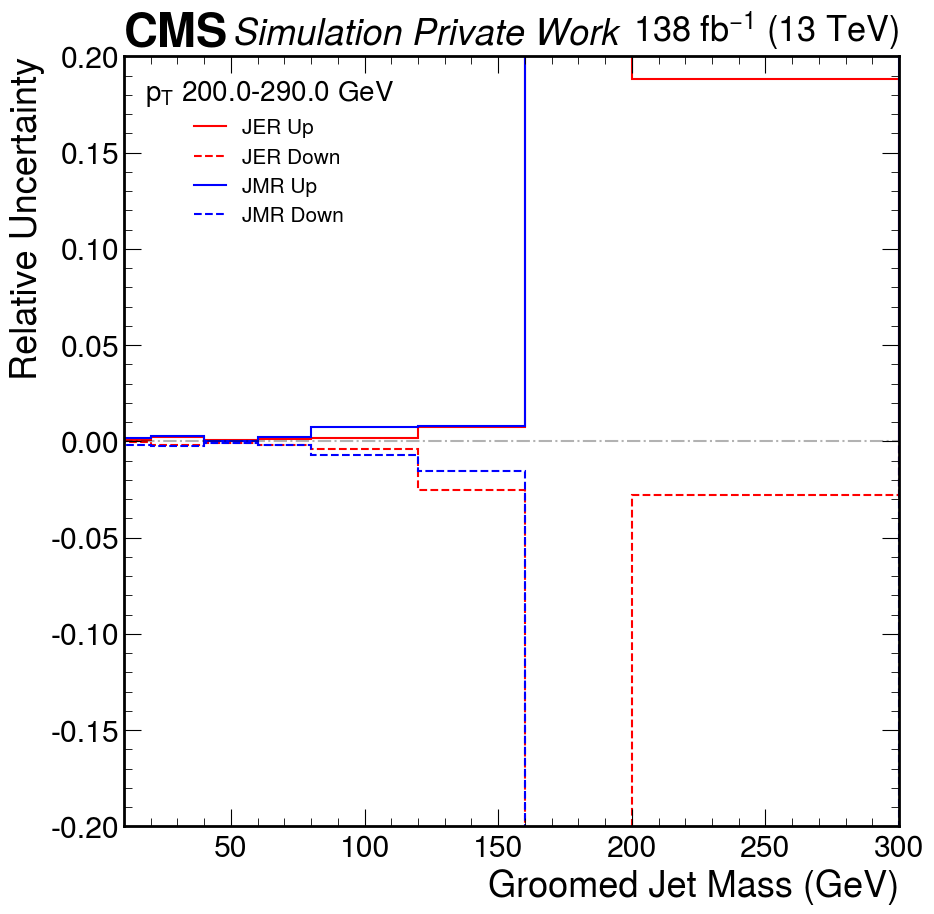

/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*s

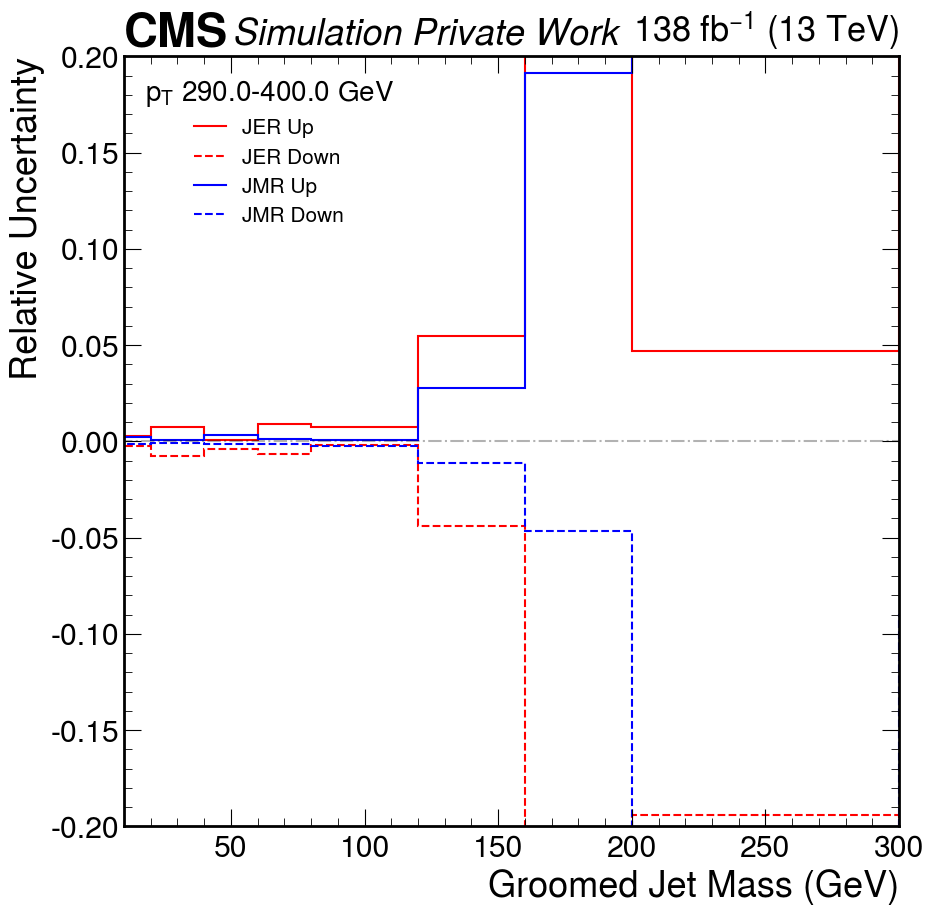

/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*s

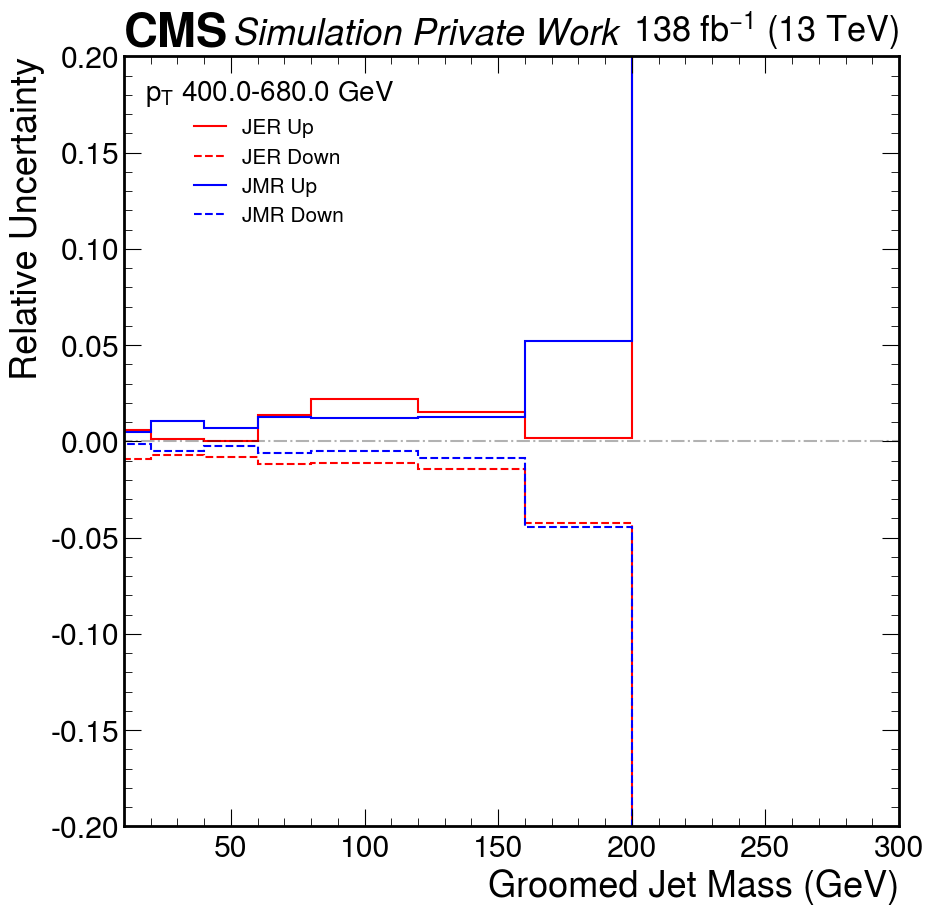

/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*s

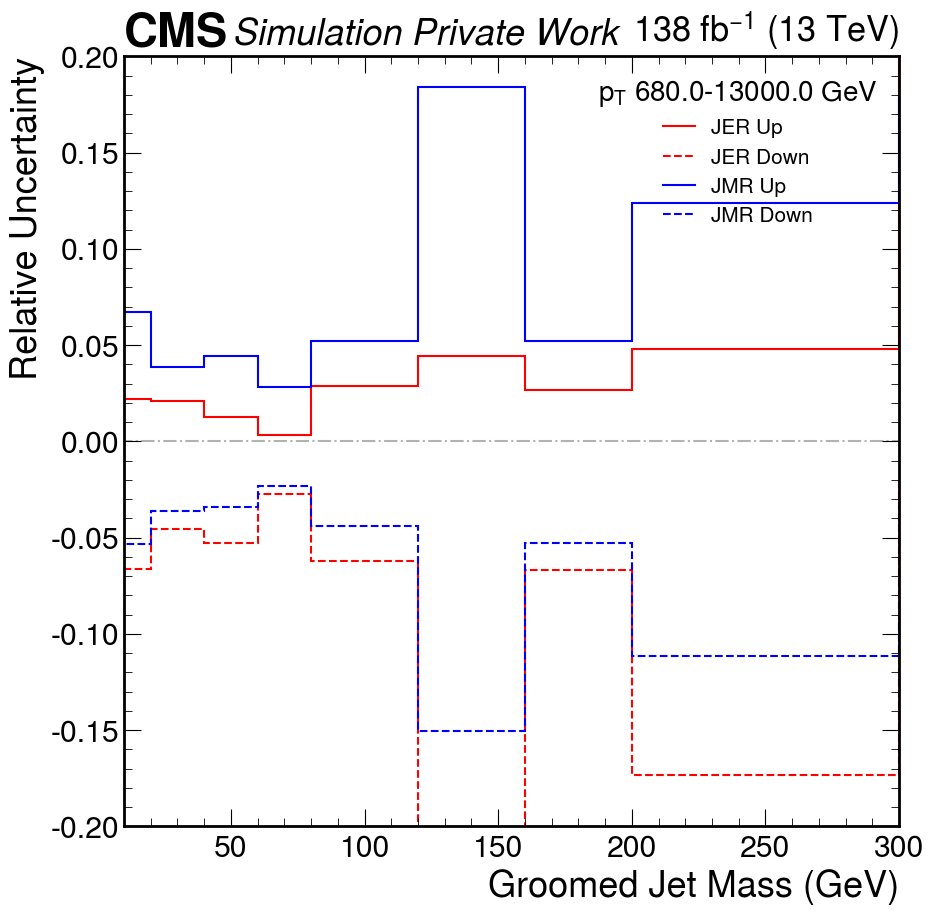

In [47]:
sys = 'JER'
sys2="JMR"
for ipt in range(npt):
    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][1], label = sys+' Up' , color = 'r' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][1], label = sys+' Down'  , ls = '--', color = 'r')

    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][1], label = sys2+' Up' , color ='b' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][1], label = sys2+' Down'  , ls = '--', color ='b')

    #hep.histplot(unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0],unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Up' , color = 'g')
    #hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Down'  , ls = '--', color = 'g')
    
    plt.hlines(0, 0, 300, color = 'k' , ls = '-.', alpha = 0.3)
    plt.legend(title=r"$p_T$ {}-{} GeV".format(unfolder.ptgen_edge[ipt], unfolder.ptgen_edge[ipt+1]), fontsize = 15, title_fontsize = 20)
    #plt.ylim(-0.1,0.1)
    if groomed:
        plt.xlabel("Groomed Jet Mass (GeV)")
        plt.xlim(10,300)
    else:
        plt.xlabel("Ungroomed Jet Mass (GeV)")
        plt.xlim(20,300)
    plt.ylabel("Relative Uncertainty")
    #plt.yscale('symlog')
    plt.ylim(-0.2, 0.2)
    #plt.yscale('symlog')
    hep.cms.label('Private Work', rlabel = r"138 $fb^{-1}$ (13 TeV)")
        
    
    plt.show()

In [48]:
unfolder.plot_systematic_frac(sys_list = ['total'])[ipt][0]

/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:867: RuntimeWarning: invalid value encountered in divide
  return_obj.append([self.total_sys[i*self.nmbinsGen  :(i+1)*self.nmbinsGen]/np.abs(self.output_pt_binned[i]), self.mgen_edge] )


array([0.18985185, 0.13447241, 0.12301871, 0.07593829, 0.1647069 ,
       0.51233882, 0.22783035, 0.34972251, 1.08737149, 1.77704218,
       1.63187871, 0.39368272])

/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*s

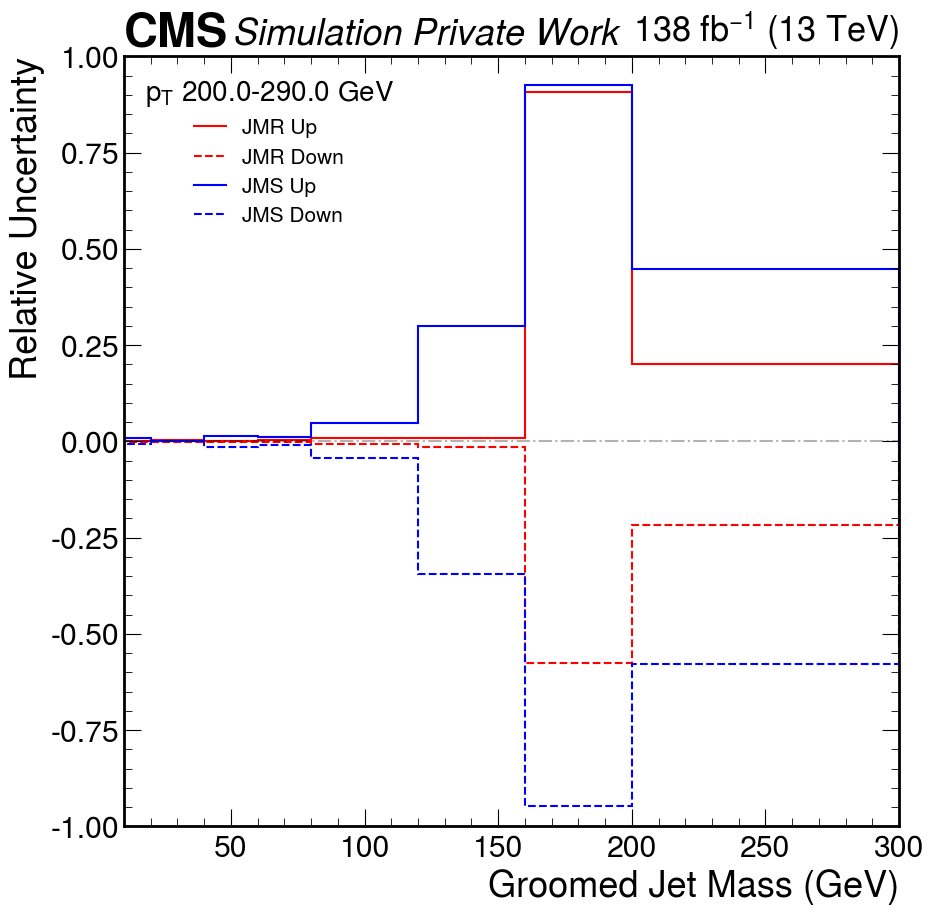

/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*s

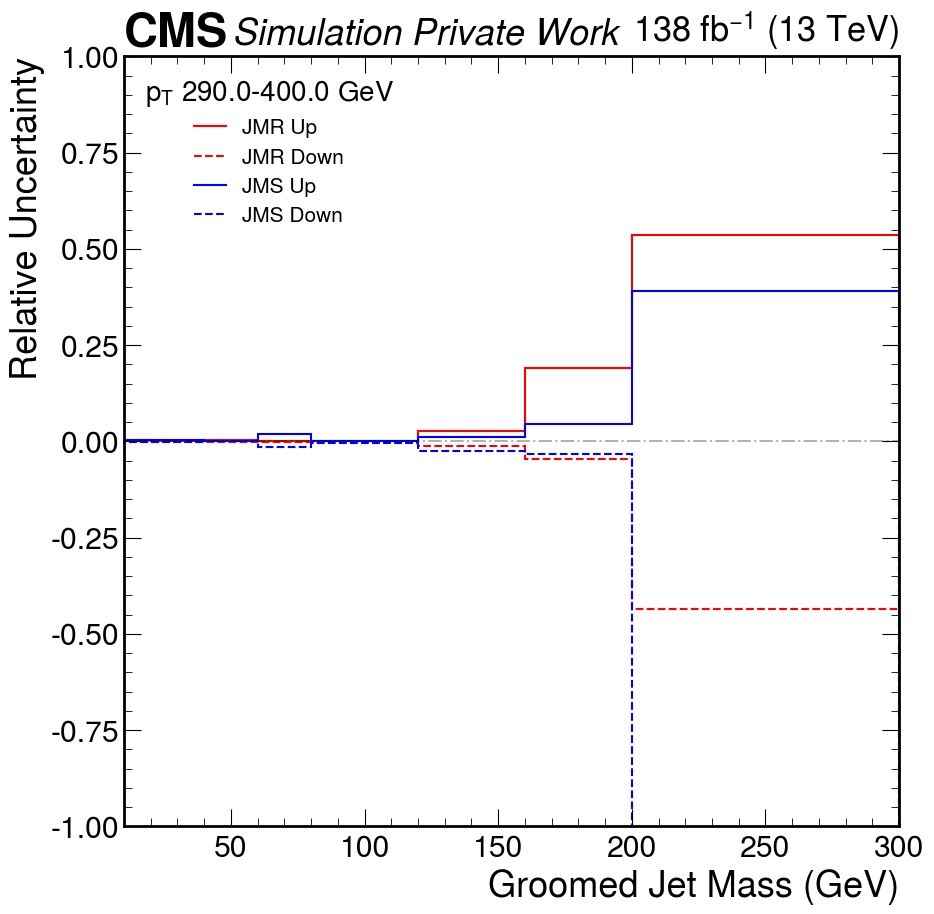

/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*s

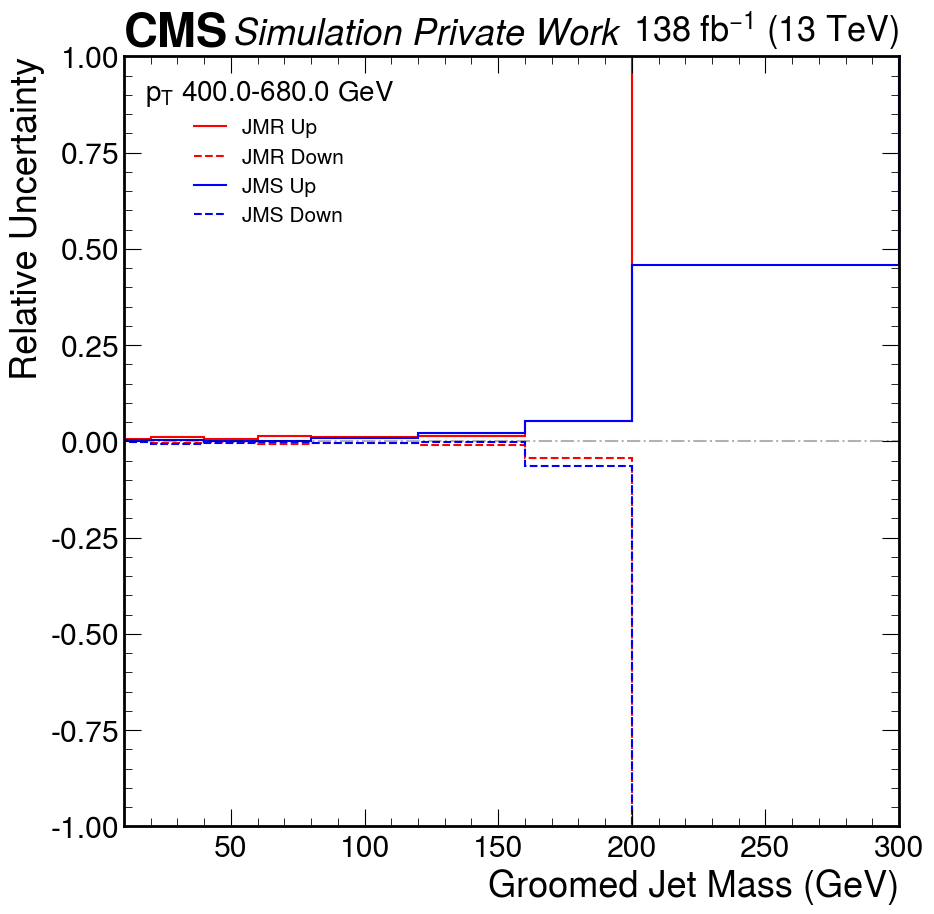

/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*s

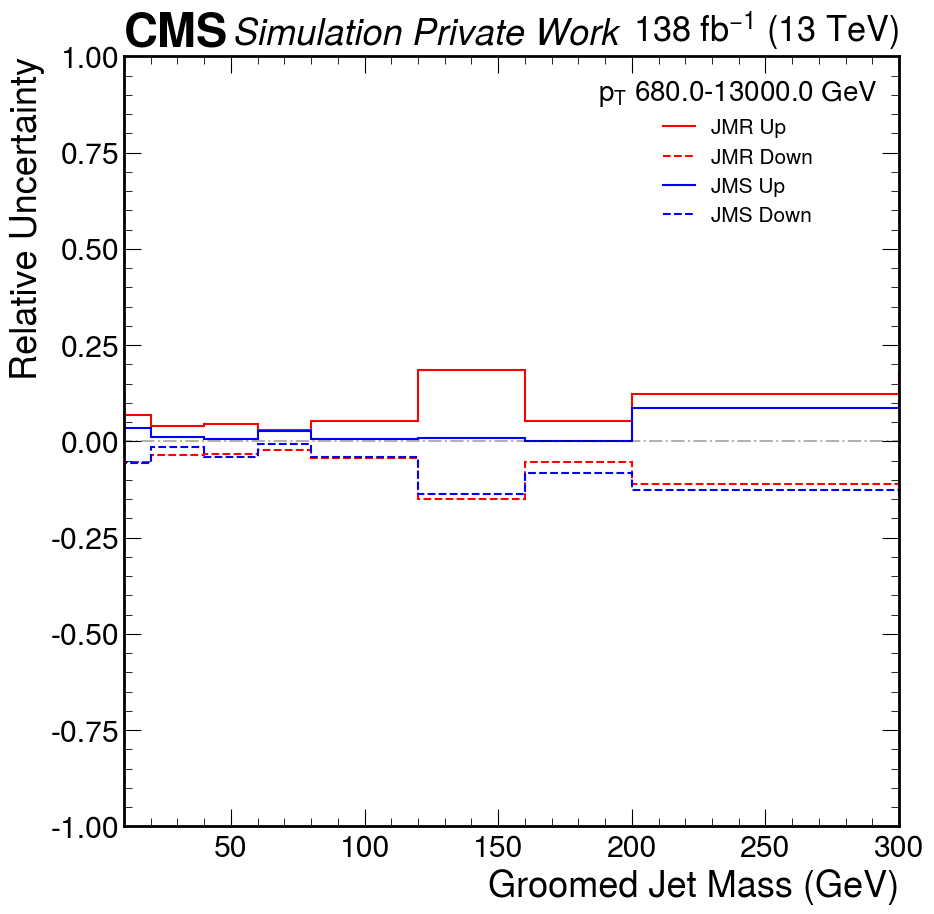

In [49]:
sys = 'JMR'
sys2 = 'JMS'
#sys3 = 'eletrig'
for ipt in range(npt):
    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][1], label = sys+' Up' , color = 'r' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][1], label = sys+' Down'  , ls = '--', color = 'r')

    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][1], label = sys2+' Up' , color ='b' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][1], label = sys2+' Down'  , ls = '--', color ='b')

    #hep.histplot(unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0],unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Up' , color = 'g')
    #hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Down'  , ls = '--', color = 'g')
    
    plt.hlines(0, 0, 300, color = 'k' , ls = '-.', alpha = 0.3)
    plt.legend(title=r"$p_T$ {}-{} GeV".format(unfolder.ptgen_edge[ipt], unfolder.ptgen_edge[ipt+1]), fontsize = 15, title_fontsize = 20)
    #plt.ylim(-0.1,0.1)
    if groomed:
        plt.xlabel("Groomed Jet Mass (GeV)")
        plt.xlim(10,300)
    else:
        plt.xlabel("Ungroomed Jet Mass (GeV)")
        plt.xlim(20,300)
    plt.ylabel("Relative Uncertainty")
    #plt.yscale('symlog')
    plt.ylim(-1, 1)
    #plt.yscale('symlog')
    hep.cms.label('Private Work', rlabel = r"138 $fb^{-1}$ (13 TeV)")
    # if groomed:
    #     plt.savefig(f'plots/uncertainties/{sys}_groomed_{ipt}.pdf', dpi = 300)
    # else:
    #     plt.savefig(f'plots/uncertainties/{sys}_ungroomed_{ipt}.pdf', dpi = 300)
        
    
    plt.show()

/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*s

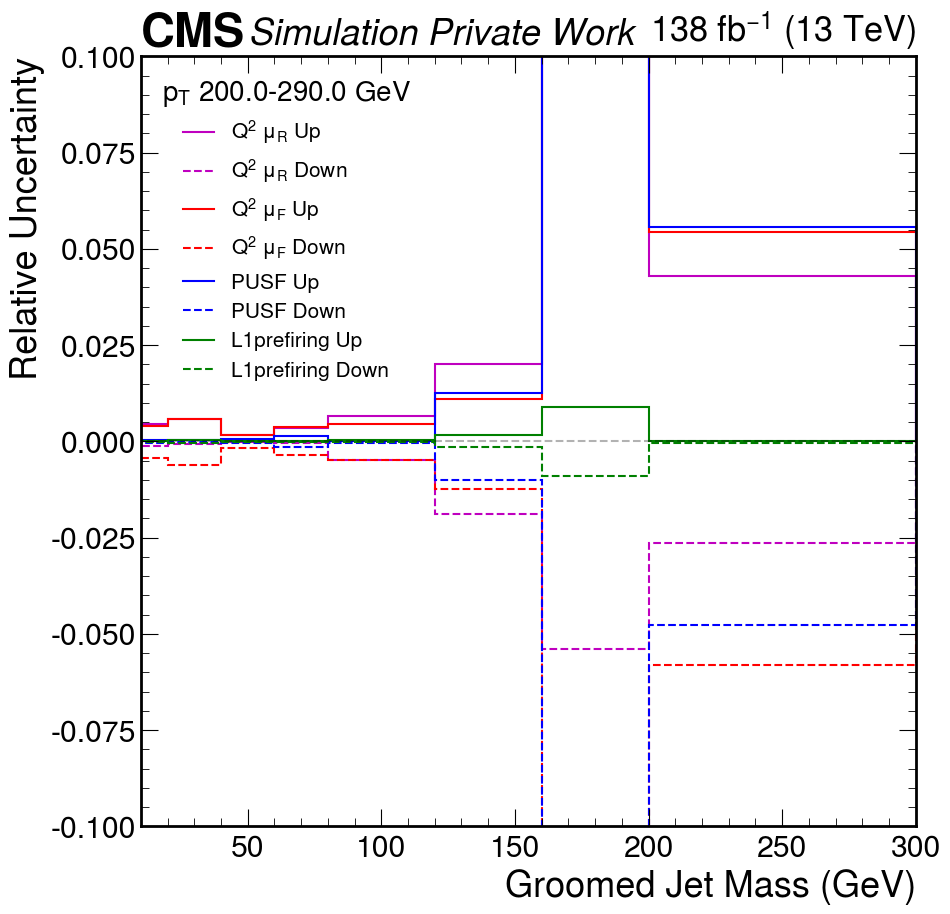

/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*s

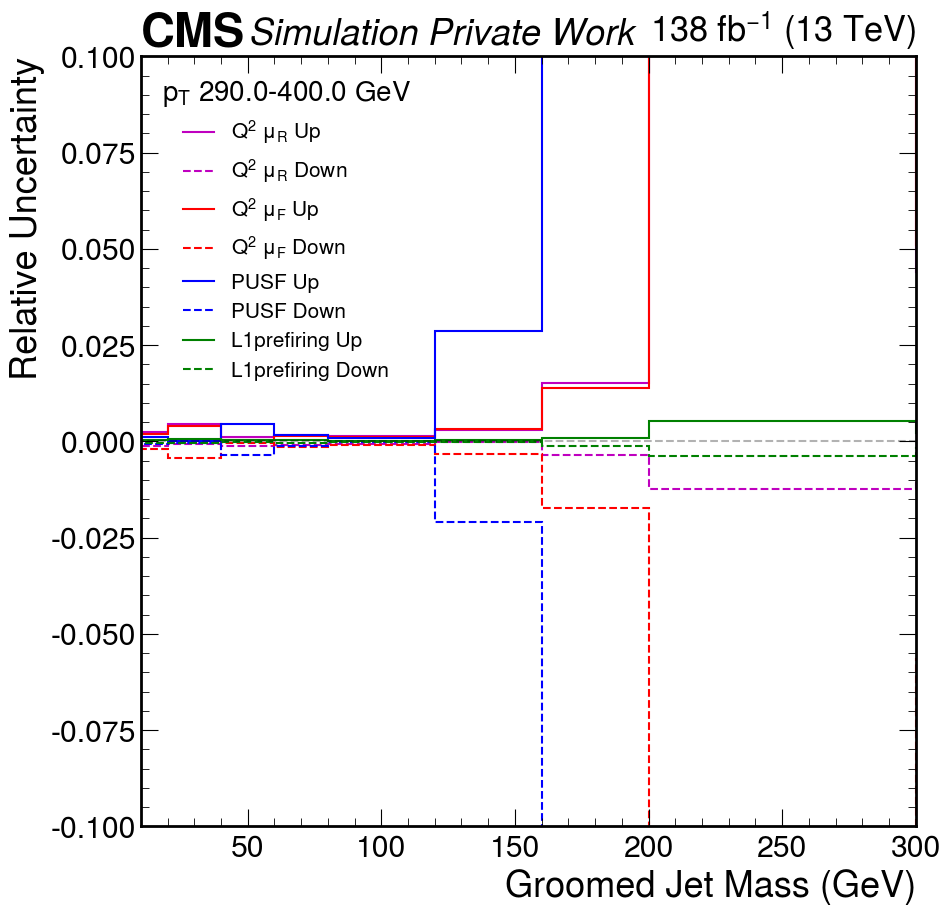

/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*s

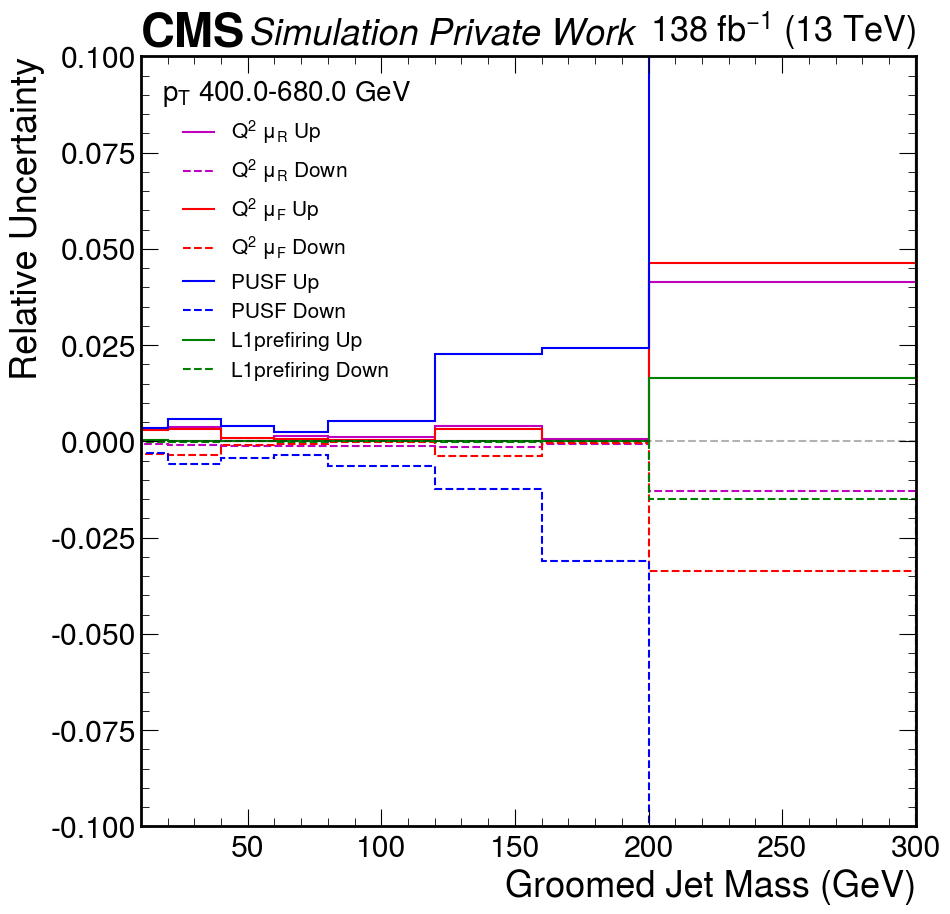

/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*self.nmbinsGen])/np.abs(self.output_pt_binned[i]), self.mgen_edge] )
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:870: RuntimeWarning: invalid value encountered in divide
  return_obj.append([np.abs(self.delta_sys_dic[sys][i*self.nmbinsGen  :(i+1)*s

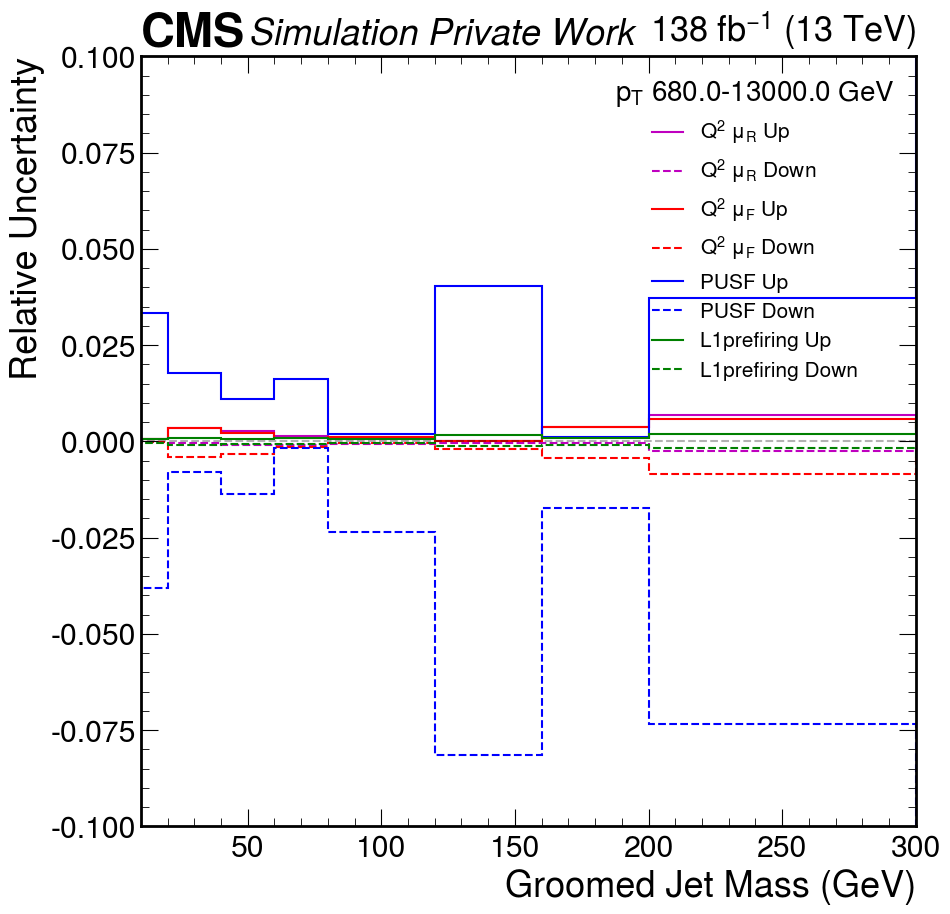

In [50]:
sys = 'Q2muF'
sys1 = 'Q2muR'
sys2 = 'PUSF'
sys3 = 'L1prefiring'
for ipt in range(npt):
    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys1+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][1], label =r'$Q^2$ $\mu_R$' +' Up' , color = 'm' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys1+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][1], label = r'$Q^2$ $\mu_R$ Down'  , ls = '--', color = 'm')
    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][1], label =r'$Q^2$ $\mu_F$' +' Up' , color = 'r' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][1], label = r'$Q^2$ $\mu_F$ Down'  , ls = '--', color = 'r')
    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][1], label = sys2+' Up' , color ='b' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][1], label = sys2+' Down'  , ls = '--', color ='b')

    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys3+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys3+'Up'])[ipt][1], label = sys3+' Up' , color ='g' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Down'  , ls = '--', color ='g')
    
    plt.hlines(0, 0, 300, color = 'k' , ls = '--', alpha = 0.3)
    plt.legend(title=r"$p_T$ {}-{} GeV".format(unfolder.ptgen_edge[ipt], unfolder.ptgen_edge[ipt+1]), fontsize = 15, title_fontsize = 20)
    #plt.ylim(-0.1,0.1)
    if groomed:
        plt.xlabel("Groomed Jet Mass (GeV)")
        plt.xlim(10,300)
    else:
        plt.xlabel("Ungroomed Jet Mass (GeV)")
        plt.xlim(20,300)
    plt.ylabel("Relative Uncertainty")
    plt.ylim(-0.1, 0.1)
    #plt.yscale('symlog')
    hep.cms.label('Private Work', rlabel = r"138 $fb^{-1}$ (13 TeV)")
        
    
    plt.show()



In [51]:
# plt.stairs(unfolder_dn.plot_systematic_frac(['total']))

/tmp/ipykernel_1869/1567556387.py:2: RuntimeWarning: invalid value encountered in divide
  plt.stairs(unfolder.total_sys_jes[i*unfolder.nmbinsGen  :(i+1)*unfolder.nmbinsGen]/np.abs(unfolder.output_pt_binned[i]), unfolder.mgen_edge , label = "JESUp" , color = 'red', lw = 2)
/tmp/ipykernel_1869/1567556387.py:3: RuntimeWarning: invalid value encountered in divide
  plt.stairs(-unfolder_dn.total_sys_jes[i*unfolder.nmbinsGen  :(i+1)*unfolder.nmbinsGen]/np.abs(unfolder.output_pt_binned[i]), unfolder.mgen_edge , label = "JESDown", ls = '--' , color = 'blue', lw = 2)


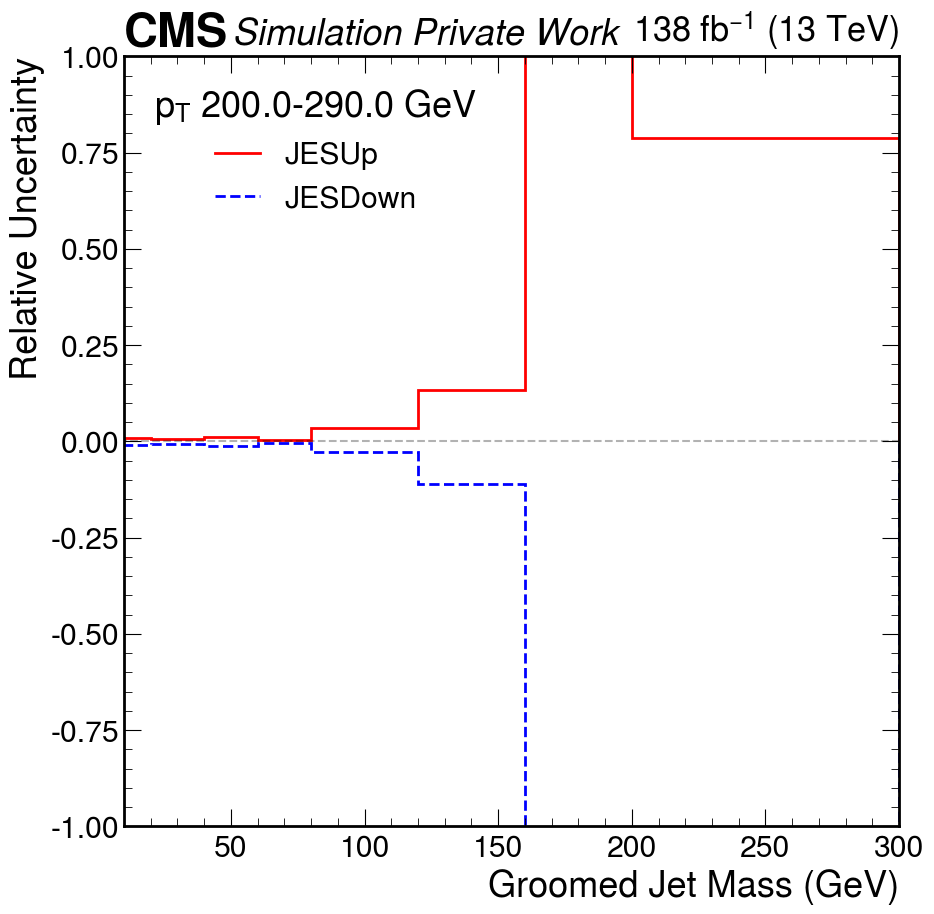

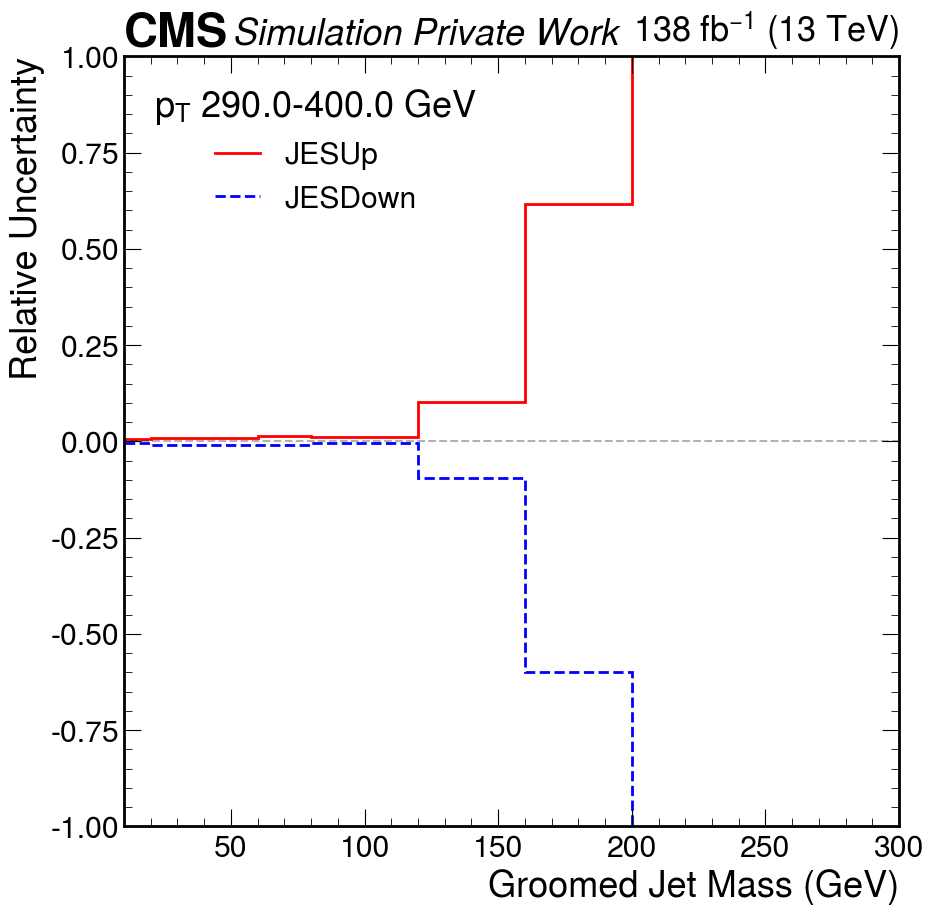

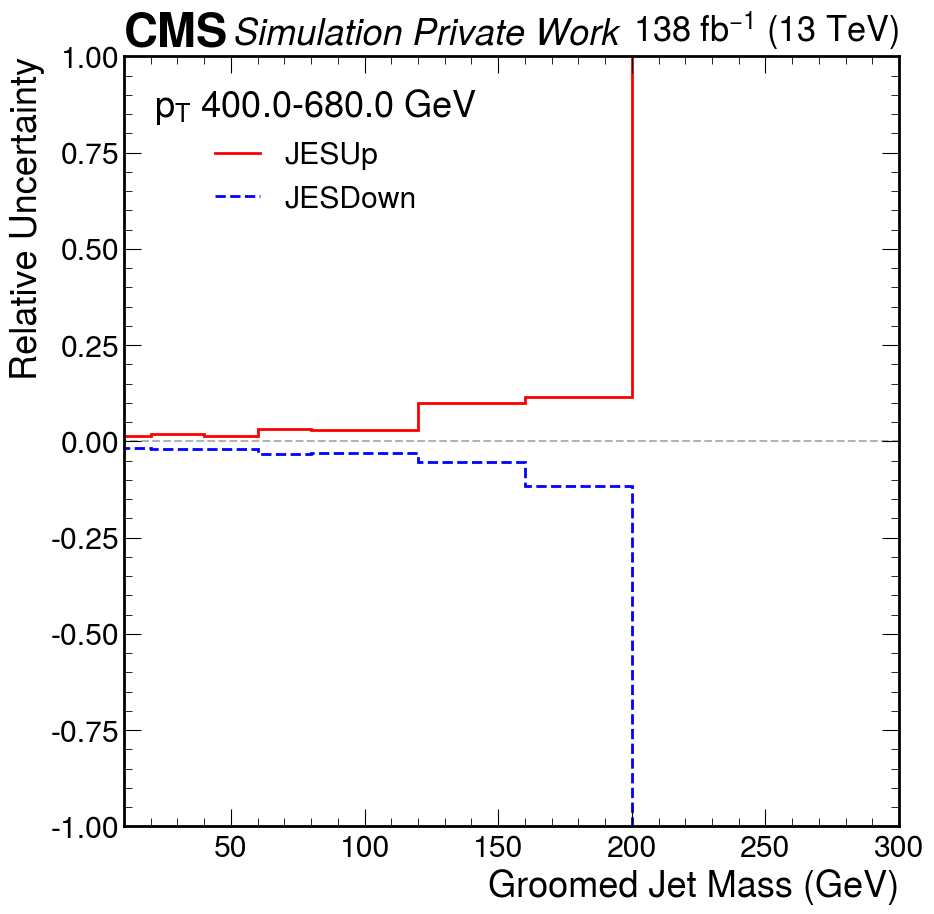

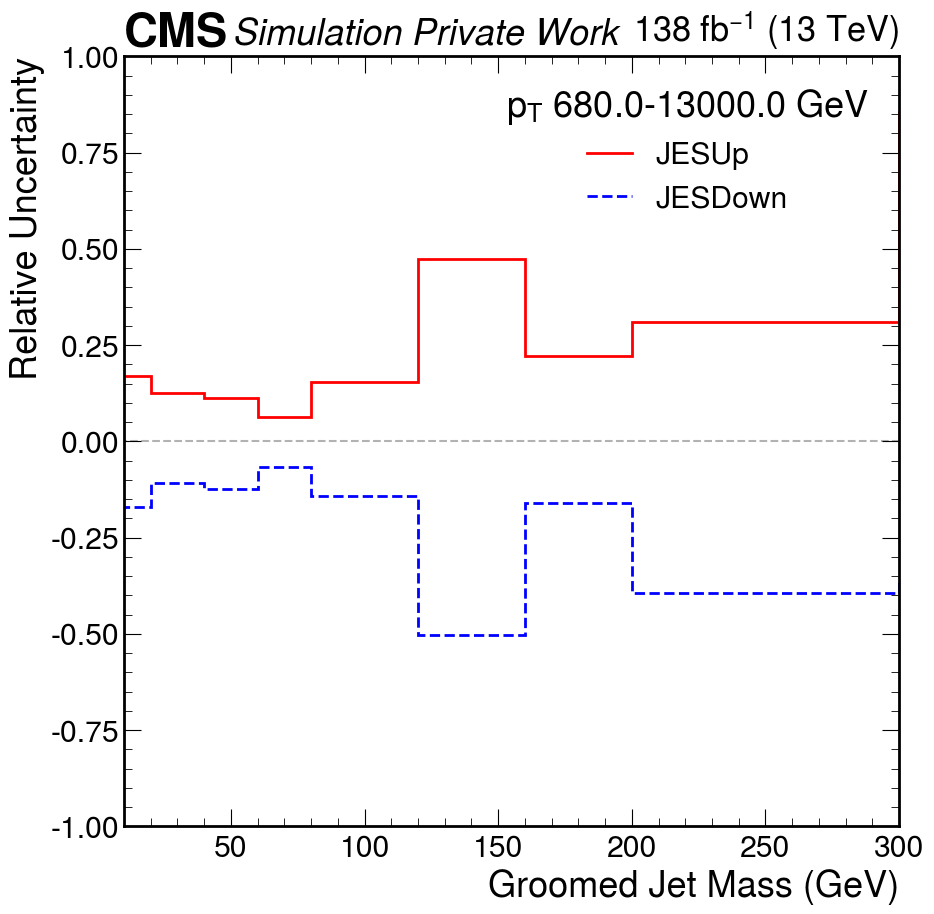

In [52]:
for i in range(npt):
    plt.stairs(unfolder.total_sys_jes[i*unfolder.nmbinsGen  :(i+1)*unfolder.nmbinsGen]/np.abs(unfolder.output_pt_binned[i]), unfolder.mgen_edge , label = "JESUp" , color = 'red', lw = 2)
    plt.stairs(-unfolder_dn.total_sys_jes[i*unfolder.nmbinsGen  :(i+1)*unfolder.nmbinsGen]/np.abs(unfolder.output_pt_binned[i]), unfolder.mgen_edge , label = "JESDown", ls = '--' , color = 'blue', lw = 2)
    plt.hlines(0, 0, 300, color = 'k' , ls = '--', alpha = 0.3)
    plt.legend(title=r"$p_T$ {}-{} GeV".format(unfolder.ptgen_edge[i], unfolder.ptgen_edge[i+1]))
    #plt.ylim(-0.1,0.1)
    if groomed:
        plt.xlabel("Groomed Jet Mass (GeV)")
        plt.xlim(10,300)
    else:
        plt.xlabel("Ungroomed Jet Mass (GeV)")
        plt.xlim(20,300)
    plt.ylabel("Relative Uncertainty")
    plt.ylim(-1, 1)
    #plt.yscale('symlog')
    hep.cms.label('Private Work', rlabel = r"138 $fb^{-1}$ (13 TeV)")
    # if groomed:
    #     plt.savefig(f'plots/uncertainties/jes_groomed_{i}.pdf', dpi = 300)
    # else:
    #     plt.savefig(f'plots/uncertainties/jes_ungroomed_{i}.pdf', dpi = 300)
        
    
    plt.show()

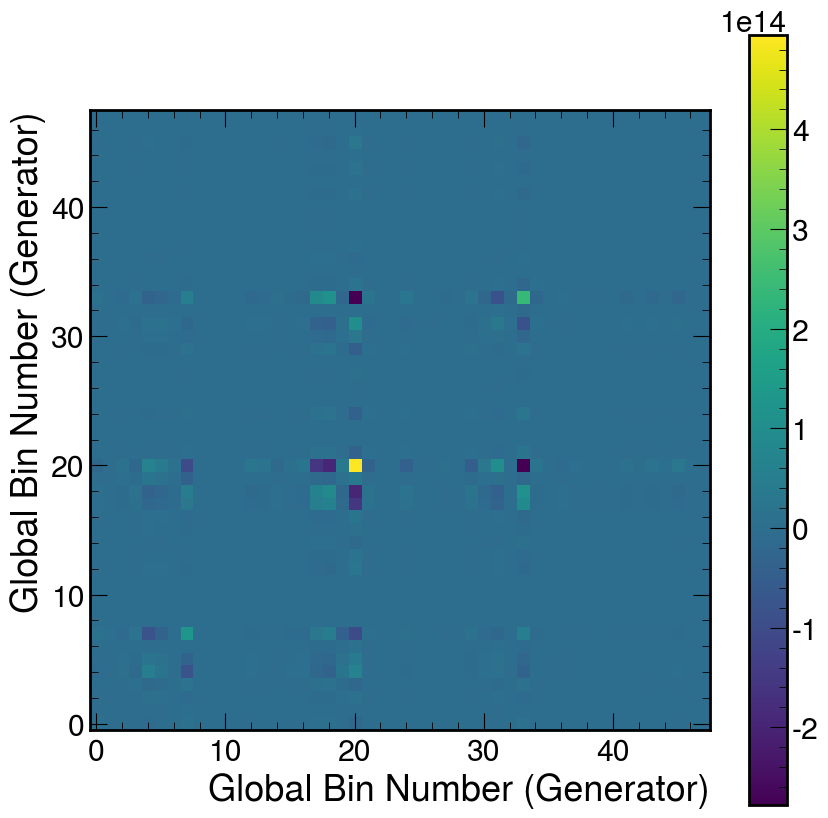

In [53]:
unfolder.plot_covariance()

In [54]:
input_data

Hist(
  StrCategory(['data2016APV', 'data2016', 'data2017', 'data2018'], growth=True, name='dataset', label='Primary dataset'),
  StrCategory(['nominal'], growth=True, name='syst', label='Systematic'),
  IntCategory([-1], growth=True, name='jk', label='Jackknife section'),
  Variable([200, 290, 400, 680, 13000], name='ptreco'),
  Variable(array([   0.,   10.,   20.,   30.,   40.,   50.,   60.,   70.,   80.,
        100.,  120.,  140.,  160.,  180.,  200.,  250.,  300.,  350.,
        400.,  450.,  500.,  700.,  900., 1100., 1300.]), name='mreco'),
  storage=Weight()) # Sum: WeightedSum(value=1.0292e+10, variance=2.22253e+14) (WeightedSum(value=1.1155e+10, variance=2.55588e+14) with flow)

In [55]:
input_data.project("ptreco", "mreco")[i,hist.rebin(1)].values().shape

(24,)

In [56]:
resp_matrix_4d.project("ptgen", "mgen").values().shape

(4, 12)

In [57]:
resp_matrix_4d.project("ptreco", "mreco")[:, hist.rebin(2)].values().shape

(4, 12)

/tmp/ipykernel_1869/700721889.py:12: RuntimeWarning: invalid value encountered in divide
  plt.plot(data_postunfold/mc[i], marker = 'o')


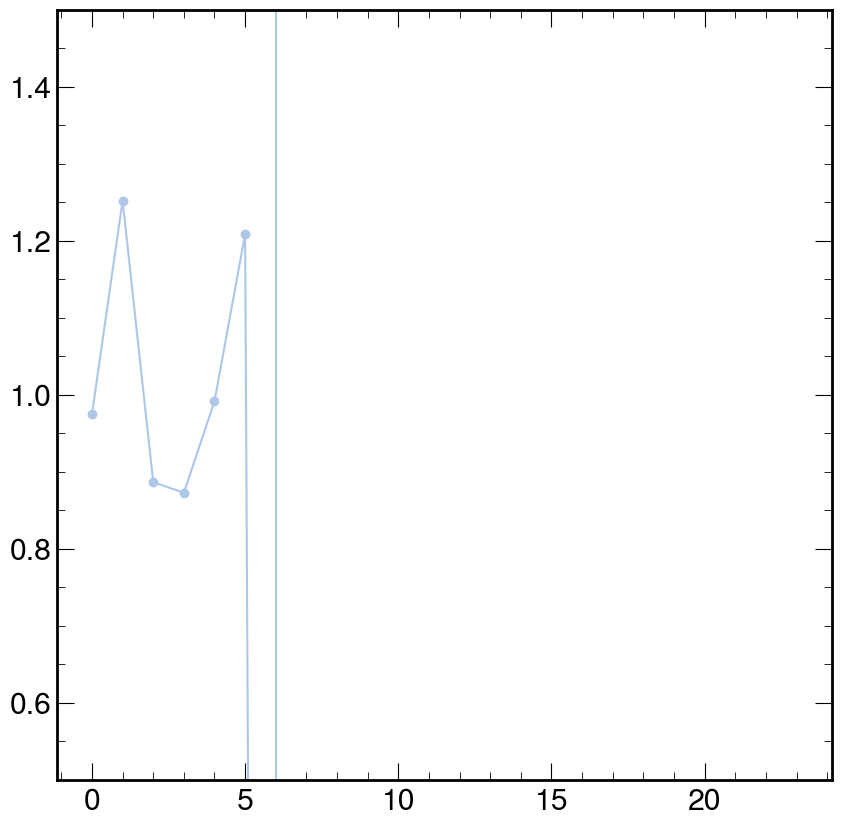

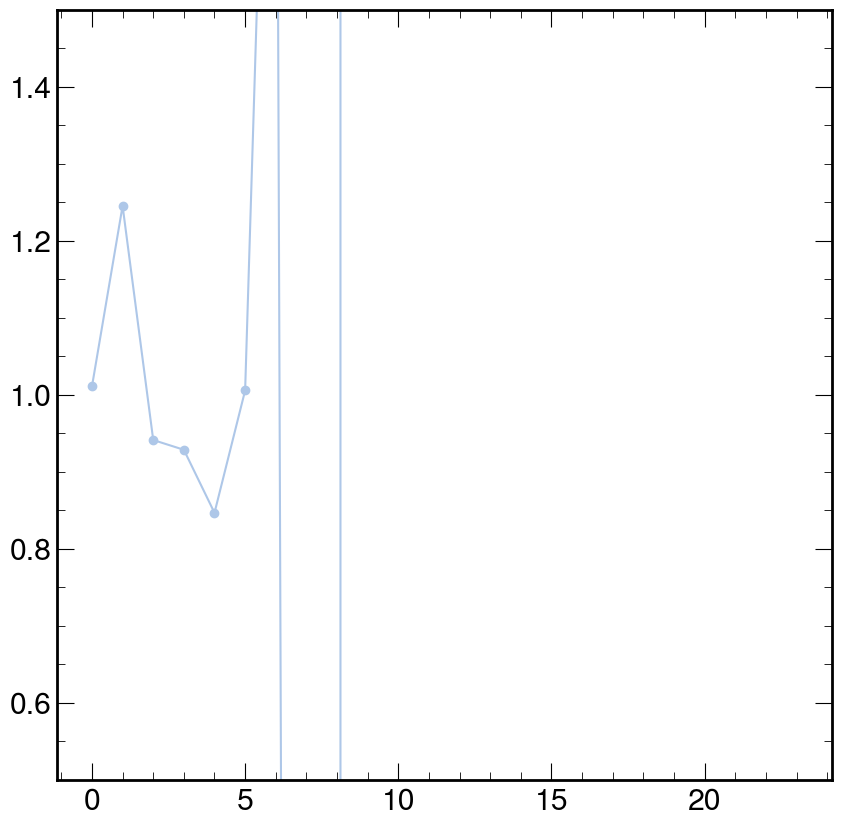

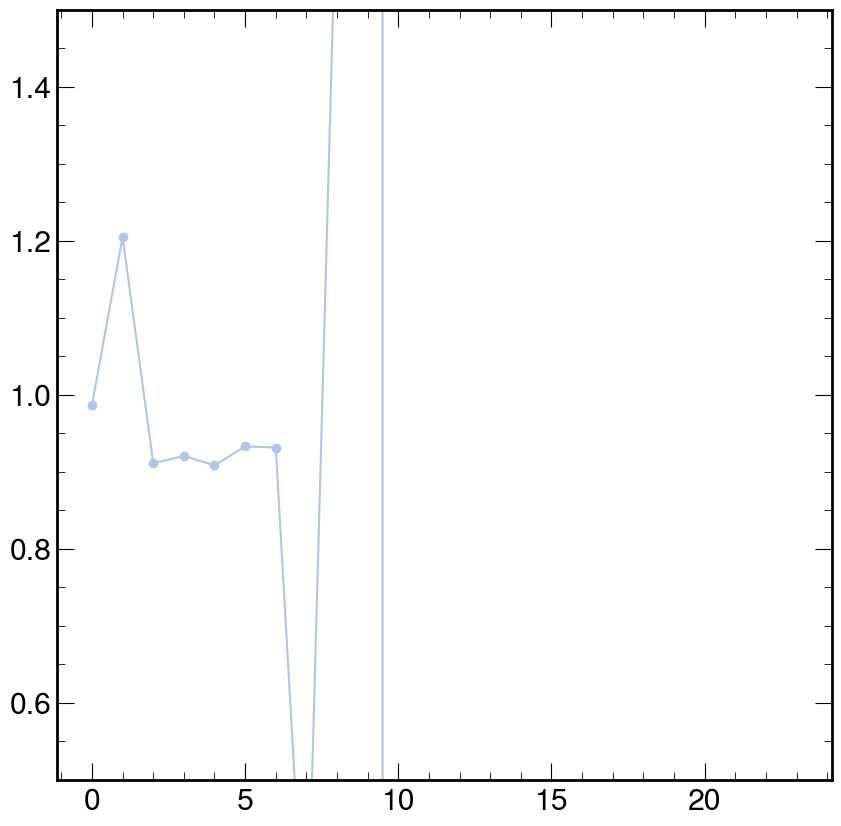

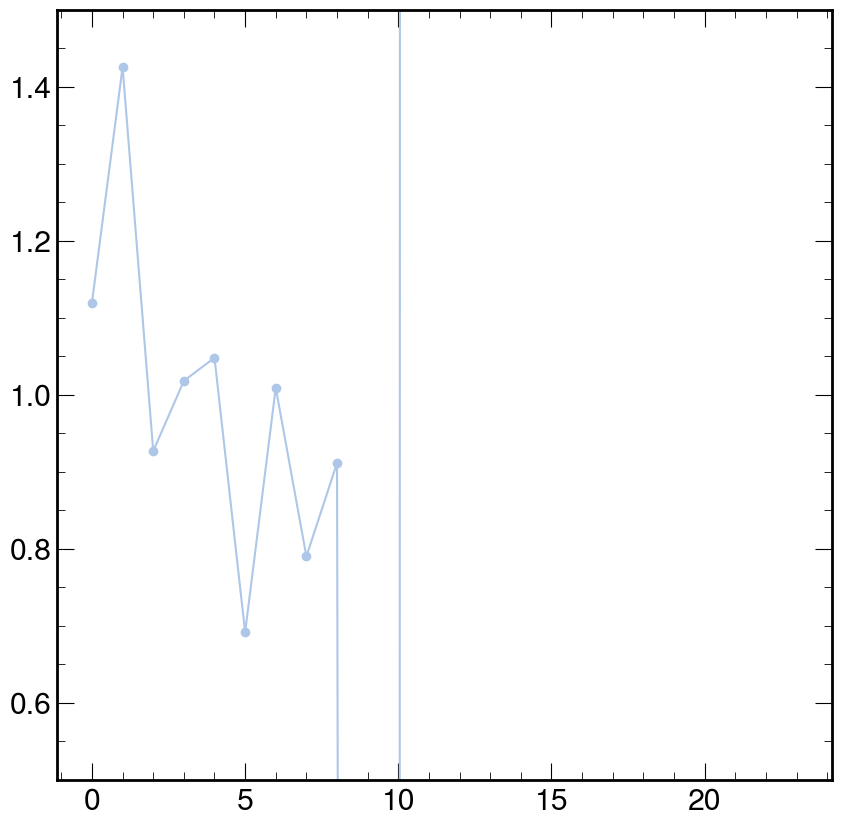

In [58]:
mc = resp_matrix_4d.project("ptgen", "mgen").values()
mc_reco =  resp_matrix_4d.project("ptreco", "mreco")[:, hist.rebin(1)].values()
mc_errors = resp_matrix_4d.project("ptgen", "mgen").variances()**0.5

for i in range(4):

    mc[i] = mc[i]/mc[i][:-1].sum()
    data_postunfold = unfolder.get_results()[0][i]/unfolder.get_results()[0][i][:-1].sum()
    data_preunfold = input_data.project("ptreco", "mreco")[i,hist.rebin(1)].values()/input_data.project("ptreco", "mreco")[i,hist.rebin(1)].values()[:-1].sum()
    
    plt.plot(data_preunfold/mc_reco[i], marker = 'x')
    plt.plot(data_postunfold/mc[i], marker = 'o')
    plt.ylim(0.5,1.5)
    plt.show()


    

In [59]:
np.sqrt(input_data.project("ptreco", "mreco")[i, hist.rebin(2)].values())

array([3847.66006815, 1890.01957662, 1484.67100733, 1297.61126691,
       1594.93542189, 1418.78398638, 1333.50140607, 1658.17309109,
        820.31823093,  350.87319647,  356.85431201,  186.16390628])

In [60]:
input_data.project("ptreco", "mreco")[i, hist.rebin(2)].values()

array([14804488.,  3572174.,  2204248.,  1683795.,  2543819.,  2012948.,
        1778226.,  2749538.,   672922.,   123112.,   127345.,    34657.])

In [61]:
input_data.project("ptreco", "mreco")[i, hist.rebin(2)].values()

array([14804488.,  3572174.,  2204248.,  1683795.,  2543819.,  2012948.,
        1778226.,  2749538.,   672922.,   123112.,   127345.,    34657.])

In [62]:
data_preunfold

array([0.32048543, 0.13792102, 0.06505544, 0.04555343, 0.03680597,
       0.03144641, 0.02744524, 0.02469182, 0.04304869, 0.03571817,
       0.03222915, 0.03009981, 0.02854802, 0.026513  , 0.05256678,
       0.03256997, 0.01508372, 0.00575265, 0.00246984, 0.0013422 ,
       0.00258147, 0.00136164, 0.00071013, 0.00036299])

In [63]:
unfolder.stat_pt_binned[0]

array([0.17700221, 0.15085718, 0.14939393, 0.14262328, 0.13740817,
       0.0495013 , 0.04641665, 0.14679726, 0.        , 0.        ,
       0.        , 0.        ])

In [64]:
herwig_input = resp_matrix_4d_herwig.project('ptreco', 'mreco')

In [65]:
fakes_str = "fakes_u"
misses_str = "misses_u"
# fakes_str = "fakes"
# misses_str = "misses"
print(output_jk['response_matrix_u'][{'jk':0}])
jk_output_list = []
for i in range(10):
    if not groomed:
        resp_matrix_4d_jk = output_jk['response_matrix_u'][{'jk':i}]
        resp_matrix_4d_jk= rebin_hist(resp_matrix_4d_jk, 'mreco',edges )
        resp_matrix_4d_jk= rebin_hist(resp_matrix_4d_jk, 'mgen',edges_gen )

        resp_matrix_4d_jk= rebin_hist(resp_matrix_4d_jk, 'ptreco',pt_edges )
        resp_matrix_4d_jk= rebin_hist(resp_matrix_4d_jk, 'ptgen', pt_edges )
        
        input_data = output_data['ptreco_mreco_u']
        input_data = rebin_hist(input_data, 'mreco',edges)
        input_data = rebin_hist(input_data, 'ptreco',pt_edges)
        fakes_jk = output_jk[fakes_str][{'jk':i, 'syst':'PUSFUp'}]
        fakes_jk= rebin_hist(fakes_jk, 'mreco',edges )
        fakes_jk= rebin_hist(fakes_jk, 'ptreco',pt_edges )
        misses_jk = output_jk[misses_str][{'jk':i, 'syst':'nominal'}]
        misses_jk= rebin_hist(misses_jk, 'mgen',edges_gen )
        misses_jk= rebin_hist(misses_jk, 'ptgen',pt_edges )
        

    else:
        resp_matrix_4d_jk = output_jk['response_matrix_g'][{'jk':i}]
        resp_matrix_4d_jk= rebin_hist(resp_matrix_4d_jk, 'mreco',edges )
        resp_matrix_4d_jk= rebin_hist(resp_matrix_4d_jk, 'mgen',edges_gen )

        resp_matrix_4d_jk= rebin_hist(resp_matrix_4d_jk, 'ptreco',pt_edges )
        resp_matrix_4d_jk= rebin_hist(resp_matrix_4d_jk, 'ptgen', pt_edges )
        
        input_data = output_data['ptreco_mreco_g']
        input_data = rebin_hist(input_data, 'mreco',edges)
        input_data = rebin_hist(input_data, 'ptreco',pt_edges)
        fakes_jk = fakes
        misses_jk = (9/10)*misses
    resp_matrix_4d_jk[...] = reweight_pt(resp_matrix_4d_jk, input_data[{"syst":'nominal'}])
    fakes_jk[...] = reweight_pt(fakes_jk, input_data[{"syst":'nominal'}])
    unfolder_jk = Unfolder(input_data, resp_matrix_4d_jk[{'syst':'nominal'}] , fakes_jk, misses_jk,
                            # backgrounds = {"ww": ww_bg, "wz":wz_bg, "zz": zz_bg},
                            #systematics = {'JES_AbsoluteMPFBiasUp': resp_matrix_4d[{'systematic':'JES_AbsoluteMPFBiasUp'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()  },
                            #systematics = sys_matrix_dic_down,
                            systematics= None,
                            closure = closure,
                            groomed = groomed,
                            is_uf = True,
                            merge = False,
                            normalised_xs = True,
                            do_syst = True,
                            discard_low_bins = False,
                            regularisation= 'None',
                            do_norm = False
                                   )

    unfolder_jk.perform_unfold()
    jk_output_list.append(unfolder_jk.get_results()[0])
        
    # resp_matrix_4d_jk = resp_matrix_4d_jk[:,:,:hist.loc(131), : ,:hist.loc(121),:] 
    # resp_matrix_4d_jk[:,:,hist.loc(121), : ,:,:] = resp_matrix_4d_jk[:,:,hist.loc(121), : ,:,:].view() + resp_matrix_4d_jk[:,:,hist.loc(131), : ,:,:].view()
    # resp_matrix_4d_jk[:,:,:, : ,hist.loc(111),:] = resp_matrix_4d_jk[:,:,:, : ,hist.loc(111),:].view() + resp_matrix_4d_jk[:,:, :, : ,hist.loc(121),:].view()



Hist(
  StrCategory(['QCD_pythiaMG2018'], growth=True, name='dataset', label='Primary dataset'),
  StrCategory(['nominal', 'LuminosityDown', 'PUSFDown', 'Q2muRUp', 'L1prefiringUp', 'Q2muFUp', 'PDFUp', 'PDFDown', 'PUSFUp', 'LuminosityUp', 'L1prefiringDown', 'Q2muFDown', 'Q2muRDown'], growth=True, name='syst', label='Systematic'),
  Variable([0, 200, 290, 400, 480, 570, 680, 760, 820, 13000], name='ptreco', label='$p_{T,RECO}$ [GeV]'),
  Variable(array([   0. ,    2.5,    5. ,    7.5,   10. ,   15. ,   20. ,   30. ,
         40. ,   50. ,   60. ,   70. ,   80. ,   90. ,  100. ,  110. ,
        120. ,  130. ,  140. ,  150. ,  160. ,  170. ,  180. ,  190. ,
        200. ,  250. ,  300. ,  350. ,  400. ,  450. ,  500. ,  700. ,
        900. , 1100. , 1300. ]), name='mreco', label='$m_{RECO}$ [GeV]'),
  Variable([0, 200, 290, 400, 480, 570, 680, 760, 820, 13000], name='ptgen', label='$p_{T,GEN}$ [GeV]'),
  Variable([0, 5, 10, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 300, 400, 500, 900, 

/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


[1.00011608 0.99971674 0.99955995 0.99974357]
12
[   0.   20.   40.   60.   80.  120.  160.  200.  300.  400.  500.  900.
 1300.]
24
[   0.   10.   20.   30.   40.   50.   60.   70.   80.  100.  120.  140.
  160.  180.  200.  250.  300.  350.  400.  450.  500.  700.  900. 1100.
 1300.]
Signal Binning created
Detector Binning created
shape of you (96,)
Working until background subtractions
Unfolder object created
Regularisation USED None
Tau value 0.0


/home/cms-jovyan/GluonJetMass/unfold/unfold_utils/unfolderv3.py:176: RuntimeWarning: invalid value encountered in divide
  self.miss_frac = self.miss_values/ ( self.M_np.sum(axis = 1))


[1.01030751 0.98975495 0.92375504 0.7990405 ]
[1.00000009 0.99999978 0.99999964 0.9999997 ]
12
[   0.   20.   40.   60.   80.  120.  160.  200.  300.  400.  500.  900.
 1300.]
24
[   0.   10.   20.   30.   40.   50.   60.   70.   80.  100.  120.  140.
  160.  180.  200.  250.  300.  350.  400.  450.  500.  700.  900. 1100.
 1300.]
Signal Binning created
Detector Binning created
shape of you (96,)
Working until background subtractions
Unfolder object created
Regularisation USED None
Tau value 0.0
[1.01039347 0.98954151 0.92352015 0.79897189]
[1. 1. 1. 1.]
12
[   0.   20.   40.   60.   80.  120.  160.  200.  300.  400.  500.  900.
 1300.]
24
[   0.   10.   20.   30.   40.   50.   60.   70.   80.  100.  120.  140.
  160.  180.  200.  250.  300.  350.  400.  450.  500.  700.  900. 1100.
 1300.]
Signal Binning created
Detector Binning created
shape of you (96,)
Working until background subtractions
Unfolder object created
Regularisation USED None
Tau value 0.0
[1.01031666 0.98977426 0.92358

Warning in <TROOT::Append>: Replacing existing TH1: M (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_reco (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htrue (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htruef (Potential memory leak).
Info in <TUnfold::SetConstraint>: fConstraint=1
Warning in <TUnfold::TUnfold>: 9 output bins do not depend on the input data  0 9-12 23-24 36 49
Info in <TUnfold::TUnfold>: 96 input bins and 41 output bins
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #0
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #9 (signal:ptgen[200,290]:massgen[300,400])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #10 (signal:ptgen[200,290]:massgen[400,500])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #11 (signal:ptgen[200,290]:massgen[500,900])
Info in <TUnfoldDensity::TUn

10
12
13


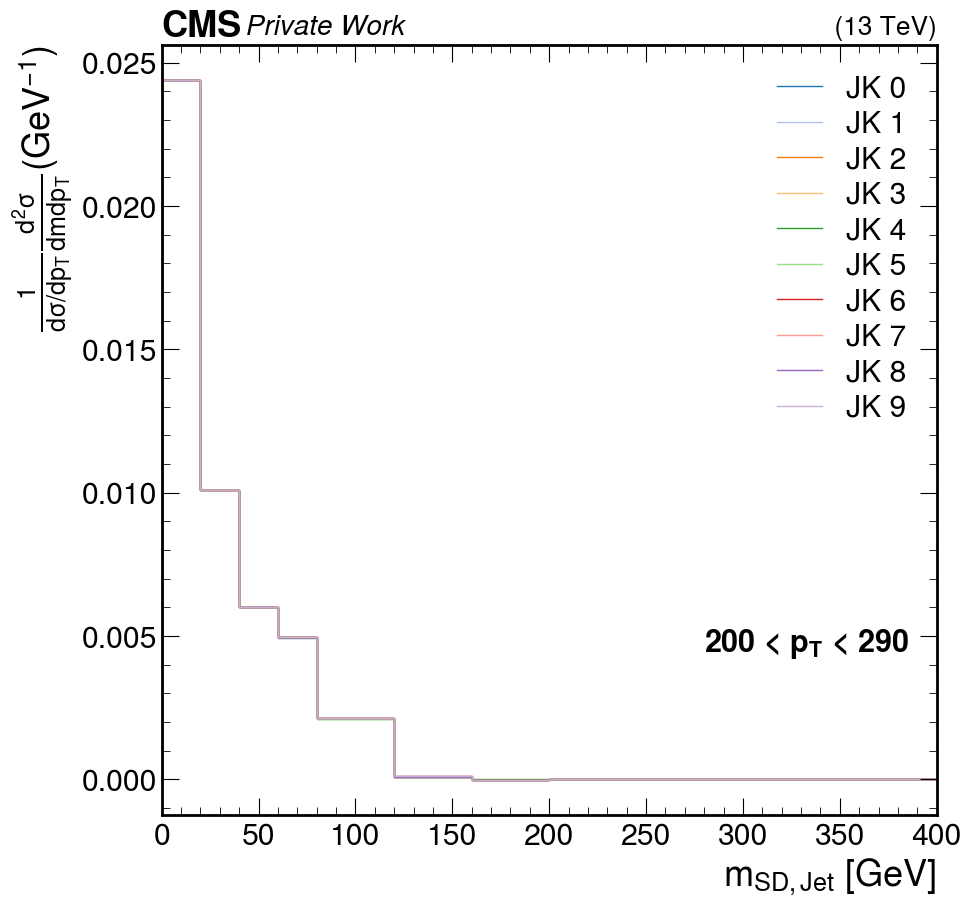

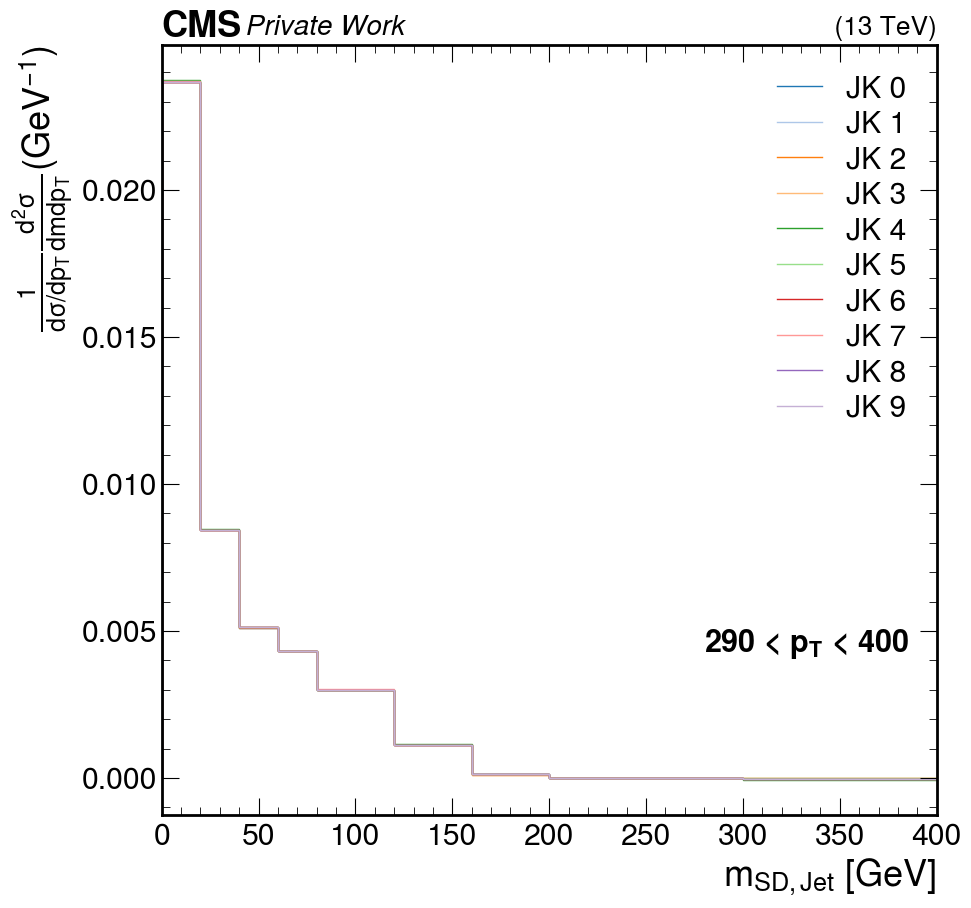

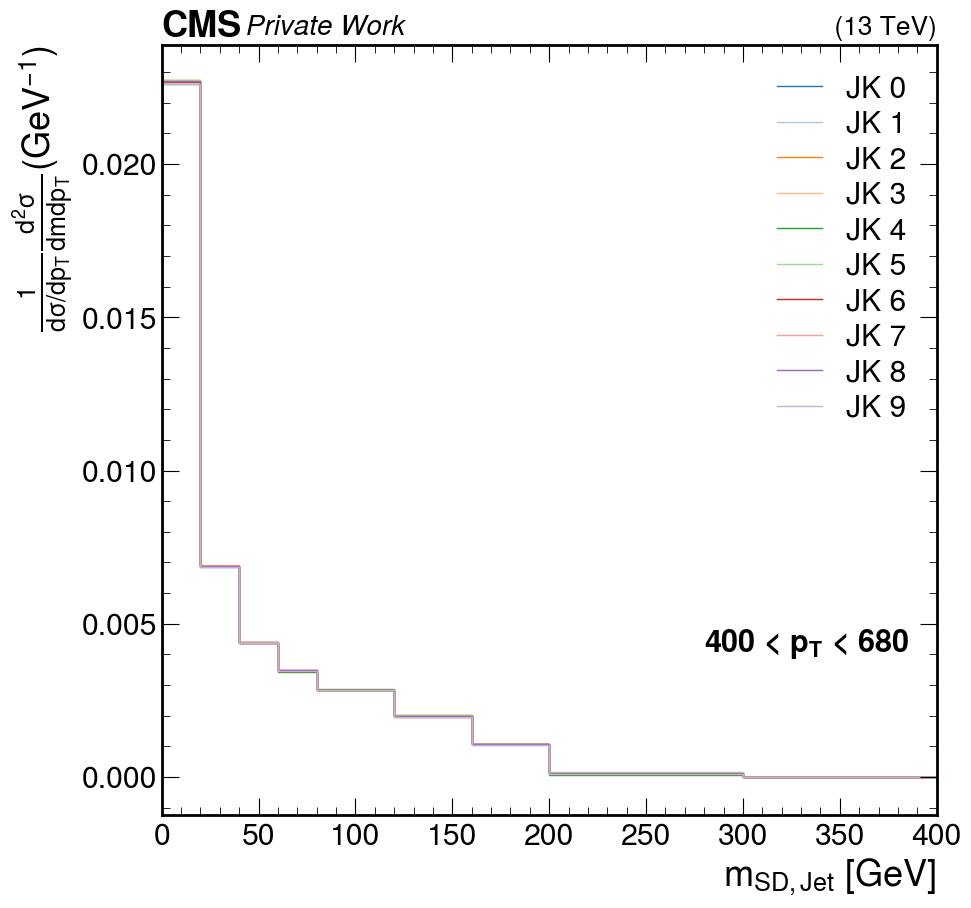

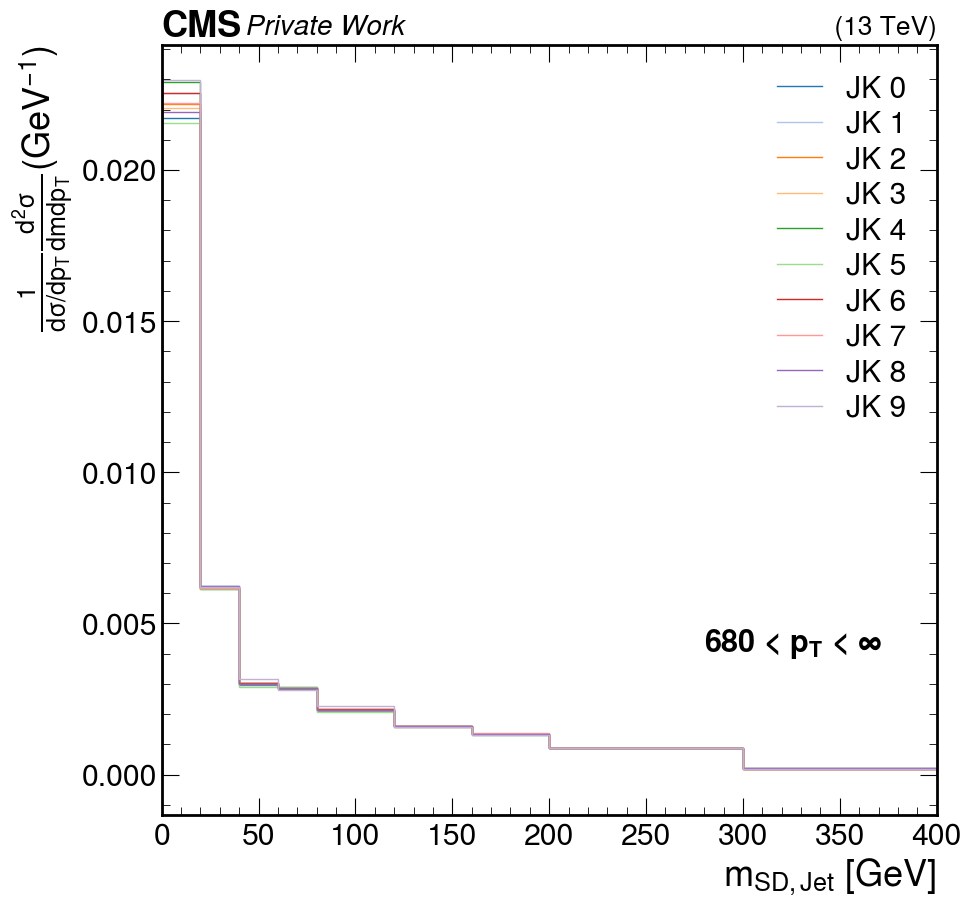

In [66]:
jk_output_list[0]
print(len(jk_output_list))
print(len(jk_output_list[0][0]))
print(len(m_edges))
axVar="mgen"
m_edges = [bin[0] for bin in resp_matrix_4d_herwig.project(axVar).axes[0]] + [resp_matrix_4d_herwig.project(axVar).axes[0][-1][1]]
for j in range(len(pt_edges)-1):
    fig,ax = plt.subplots()
    if j < len(pt_edges)-2:
        endpt = str(pt_edges[j+1])
    else: endpt = '$\infty$'
    cms = plt.text(0.7, 0.2, f"{str(pt_edges[j])} < $p_T$ < {endpt}",
                          fontsize=22,
                          fontfamily='sans',
                          fontweight='bold',
                          horizontalalignment='left',
                          verticalalignment='bottom',
                          transform=ax.transAxes
                         )
    for i in range(len(jk_output_list)):
        hep.histplot(jk_output_list[i][j],m_edges, binwnorm=True, label = "JK "+str(i), ax=ax, linewidth = 1,histtype="step")
    leg = ax.legend(loc='upper right', labelspacing=0.25)
    leg.set_visible(True)
    ax.set_xlim(0,400)
    hep.cms.label("Private Work" , fontsize = 20, data = True, ax = ax)
    ax.set_xlabel(r"$m_{SD, Jet}$ [GeV]")
    ax.set_ylabel(r'$\frac{1}{d\sigma/dp_T}\frac{d^2\sigma}{dmdp_T} (GeV^{-1})$', loc = 'top')
    # ax.set_xticks(m_edges)
    plt.savefig(f'../plots/unfolding/{channel}/jackknife_envelope{groom_str}{IOV}_{j}.pdf', bbox_inches='tight')

In [68]:
#### Get final stat unc
jk_output_list = np.array(jk_output_list)
print(len(jk_output_list))
stat_unc = np.sqrt(10/9)*np.std(jk_output_list, axis = 0)
hist_true = resp_matrix_4d
stat_unc.shape
print(stat_unc)
print(np.array(unfolder.stat_mat_pt_binned))
total_sys_pt_binned = unfolder.total_sys_pt_binned
# stat_unc = unfolder.stat_pt_binned
tot_unc = (np.array(total_sys_pt_binned)**2+np.array(stat_unc)**2)**0.5
####### dump outputs
hist_true, unfolder.output_pt_binned, tot_unc, stat_unc,
output_dict = {"unfolded_result": unfolder.output_pt_binned,
              "sys_dic":unfolder.delta_sys_dic,
               "total_sys": unfolder.total_sys_pt_binned,
              "stat_unc":stat_unc,
              "pythia_truth":hist_true}
unfold_pkl_path = "latest_pkl/{}_unfold_outputs{}.pkl".format(channel, groom_str)
tot_unc = (np.array(total_sys_pt_binned)**2+np.array(stat_unc)**2)**0.5
with open(unfold_pkl_path, "wb") as f:
    pkl.dump(output_dict, f)

10
[[9.98582035e-05 7.21272755e-05 1.11109865e-04 6.32507086e-05
  2.68854159e-04 1.12709537e-04 5.52435375e-05 4.17220032e-04
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [5.20420664e-04 2.03514353e-04 1.44732776e-04 1.40036730e-04
  1.50346831e-04 3.96830023e-04 3.72993499e-04 4.94915976e-04
  1.39247279e-03 1.90362521e-04 0.00000000e+00 0.00000000e+00]
 [1.05699069e-03 2.61219566e-04 2.93206509e-04 3.81576126e-04
  4.35714266e-04 7.30315140e-04 5.64662774e-04 2.06710514e-03
  4.48537786e-04 4.96157001e-03 7.67004923e-04 0.00000000e+00]
 [9.56545770e-03 7.15314469e-04 1.40818973e-03 5.20116467e-04
  1.73425048e-03 6.41273304e-04 6.67841106e-04 6.61327885e-04
  2.01476017e-03 9.03058160e-03 7.96773153e-05 1.94240443e-05]]
[[5.73544259e-02 4.71252464e-02 5.35748867e-02 6.75356409e-02
  2.47361256e-01 1.03457450e-01 3.53429265e-02 3.88248168e-01
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.57003082e-02 1.54881753e-02 1.68179577e-02 1.13874947e-02

/tmp/ipykernel_1869/2881939534.py:18: RuntimeWarning: invalid value encountered in divide
  post_unc = tot_unc[i] / unfolder.get_results()[0][i].sum()/mc[i]
/tmp/ipykernel_1869/2881939534.py:25: RuntimeWarning: invalid value encountered in divide
  ax.stairs(data_postunfold / mc[i], edges=mgen_edge_mod, label='Post-unfold / MC', color='green')
/tmp/ipykernel_1869/2881939534.py:26: RuntimeWarning: invalid value encountered in divide
  ax.errorbar((mgen_edge_mod[:-1] + mgen_edge_mod[1:]) / 2, data_postunfold / mc[i], yerr=post_unc, fmt='o', color='green')


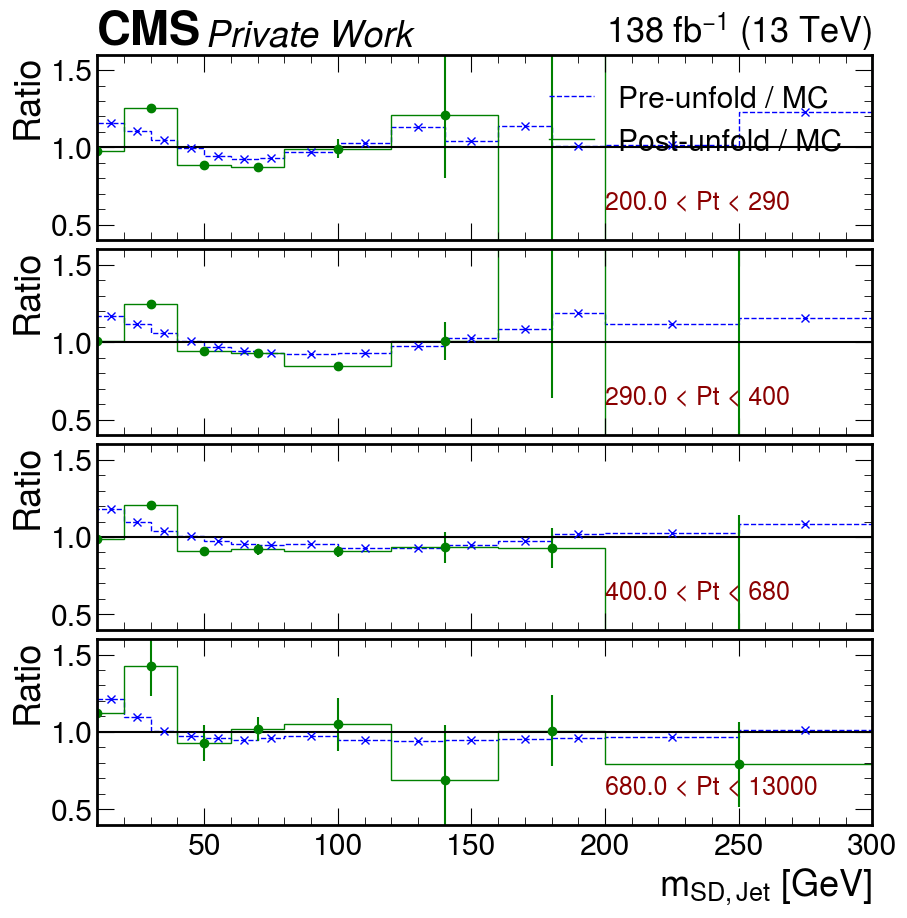

In [69]:
####plot bottom line test
mgen_edge_mod = unfolder.mgen_edge.copy()
mgen_edge_mod[-1] = 400

fig, axes = plt.subplots(npt, 1, figsize=(10, 2.5 * npt), sharex=True)
if npt == 1:
    axes = [axes]  # ensure axes is always iterable
for i, ax in enumerate(axes):
    # Normalize the distributions
    mc[i] = mc[i] / mc[i].sum()
    mc_reco[i] = mc_reco[i] / mc_reco[i].sum()
    data_postunfold = unfolder.get_results()[0][i] / unfolder.get_results()[0][i].sum()
    data_preunfold = input_data.project("ptreco", "mreco")[i, hist.rebin(1)].values()
    data_preunfold = data_preunfold / data_preunfold.sum()

    # Calculate uncertainties
    mc_unc = np.sqrt(mc[i]) / mc[i].sum()
    post_unc = tot_unc[i] / unfolder.get_results()[0][i].sum()/mc[i]
    pre_unc = np.sqrt(input_data.project("ptreco", "mreco")[i, hist.rebin(1)].values())
    pre_unc = pre_unc / input_data.project("ptreco", "mreco")[i, hist.rebin(1)].values().sum() / mc_reco[i]
    # Plot
    ax.stairs(data_preunfold / mc_reco[i], edges=mreco_edge, label='Pre-unfold / MC', color='blue', ls='--')
    ax.errorbar((mreco_edge[:-1] + mreco_edge[1:]) / 2, data_preunfold / mc_reco[i], yerr=pre_unc, fmt='x', color='blue')

    ax.stairs(data_postunfold / mc[i], edges=mgen_edge_mod, label='Post-unfold / MC', color='green')
    ax.errorbar((mgen_edge_mod[:-1] + mgen_edge_mod[1:]) / 2, data_postunfold / mc[i], yerr=post_unc, fmt='o', color='green')

    ax.hlines([1], 0, 300, color='k')
    ax.set_ylim(0.4, 1.6)
    ax.set_xlim(10, 300)
    ax.text(200, 0.6, f"{unfolder.ptgen_edge[i]} < Pt < {int(unfolder.ptgen_edge[i+1])}", size='x-small', color='darkred')
    ax.set_ylabel("Ratio")

    if i == 0:
        hep.cms.label("Private Work", com = 13, lumi = 138, data = True, loc=0, ax=ax);
    if i == 0:
        ax.legend(loc='upper right')
if groomed:
    axes[-1].set_xlabel(r"$m_{SD, Jet}$ [GeV]")
else:
    axes[-1].set_xlabel(r"$m_{Jet}$ [GeV]")
fig.subplots_adjust(hspace=0.05)
plt.savefig(f"../plots/unfolding/{channel}/bottomlinetest{groom_str}{IOV}.pdf", bbox_inches='tight')

['.', ',', 'o', 'v', '^', '<', '>', '1', '2', '3', '4', '8', 's', 'p', '*', 'h', 'H', '+', 'x', 'D', 'd', '|', '_', 'P', 'X', 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 'None', 'none', ' ', '']
[0, 20, 40, 60, 80, 120, 160, 200, 300, 400, 500, 900, 1300]
[[1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]
[200.0, 290.0, 400.0, 680.0, 13000.0]
MG+Pythia8
Check that sum of values  6741485821.946451  is same as integrate  6743212071.5362215
[0.00712789 0.00226979 0.00212751 0.00125302 0.00543277 0.00155068
 0.0003635  0.00185286 0.         0.         0.         0.        ]
[ True  True  True  True  True  True False False False False False False]
Check that sum of values  1897303303.8232949  is same as integrate  1898036867.9205306
[0.00406308 0.00247476 0.00124217 0.00205019 0.00165037 0.00585766
 0.00654504 0.00213516 0.01576374 0.00120032 0.         0.        ]
[ True  True  True  True  T

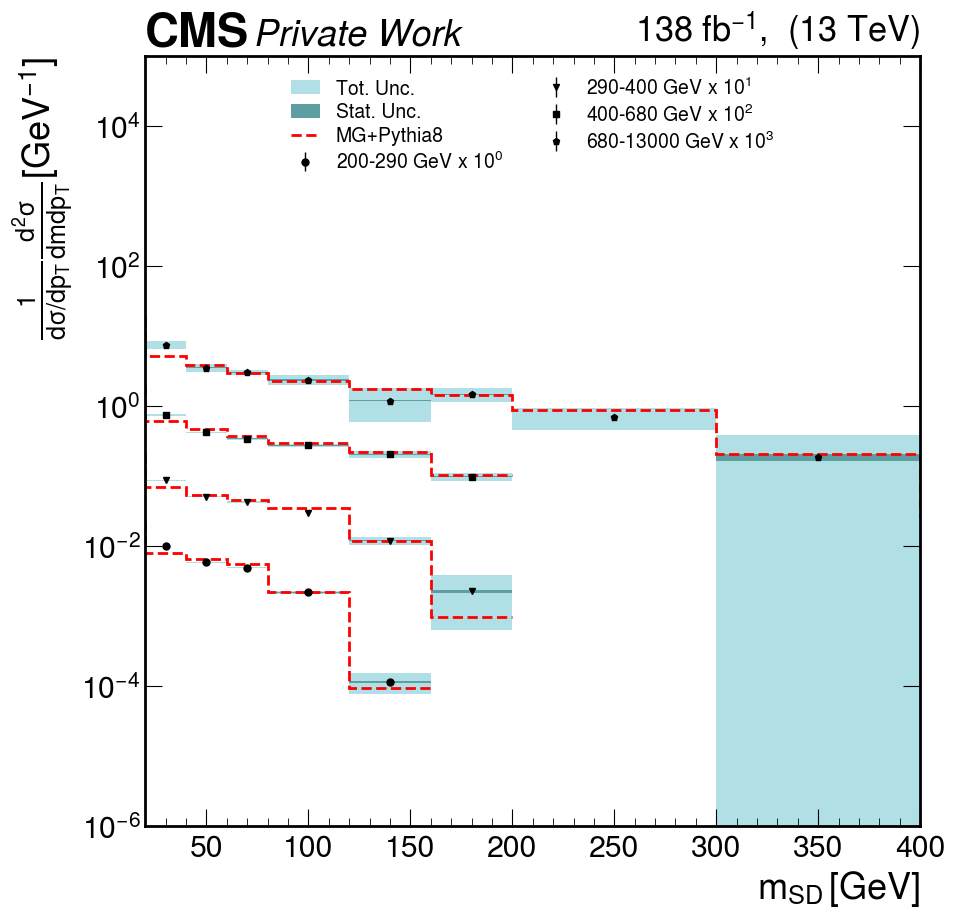

In [70]:
from unfold_utils.plot_tools import plotUnfoldOutputHist, plotStackedOutput
hist_true = resp_matrix_4d
total_sys_pt_binned = unfolder.total_sys_pt_binned
nan_map = np.ones_like(unfolder.output_pt_binned)
print(edges_gen)
#### Dijet ungroomed map
if channel=='dijet' and not groomed:
    # nan_map[-1:, 0] = 0
    nan_map[:-1, -4:] = 0
    nan_map[1, -4:] = 0
    nan_map[0, -6:] = 0

# Dijet groomed map
if channel=='dijet' and groomed:
    nan_map[:-1, -5:] = 0
    nan_map[0, -6:] = 0

# # Trijet ungroomed map
# if channel=='trijet' and not groomed:


# Trijet groomed map
if channel=='trijet' and groomed:
    nan_map[2, -3:] = 0
    nan_map[1, -5:] = 0
    nan_map[0, -6:] = 0

print(nan_map)
total_sys_pt_binned = unfolder.total_sys_pt_binned
# stat_unc = unfolder.stat_pt_binned
tot_unc = (np.array(total_sys_pt_binned)**2+np.array(stat_unc)**2)**0.5
plotStackedOutput(hist_true, unfolder.output_pt_binned, tot_unc, stat_unc, closure=closure, channel=channel, mask=nan_map, groomed=groomed)
if groomed:
    plt.savefig(f'../plots/unfolding/{channel}/{closure_str}stacked_result_groomed{IOV}.pdf', bbox_inches='tight')
else:
    plt.savefig(f'../plots/unfolding/{channel}/{closure_str}stacked_result_ungroomed{IOV}.pdf', bbox_inches='tight')

Max hist value  0.024473958753898233
Check that sum of values  6741485821.946451  is same as integrate  6743212071.5362215
oVals after norm  [ 4.89479175e-01  2.01189785e-01  1.17749314e-01  9.81826669e-02
  8.70950318e-02  4.59642055e-03 -1.74583013e-04  1.88218937e-03
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]  by value  1.0000000000000002
[ True  True  True  True  True  True False False False False False False]
MC vals  [5.02104063e-01 1.60670432e-01 1.32805669e-01 1.12497855e-01
 8.78336546e-02 3.80241566e-03 2.80561256e-05 1.85682934e-06
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]  MC errs  [9.94860887e-09 3.25687177e-09 2.79508690e-09 2.30238803e-09
 1.49592753e-09 3.53133478e-11 8.17011081e-14 1.90790629e-15
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
Max hist value  0.02359747803657323
Check that sum of values  1897303303.8232949  is same as integrate  1898036867.9205306
oVals after norm  [ 0.47194956  0.17483669  0.102

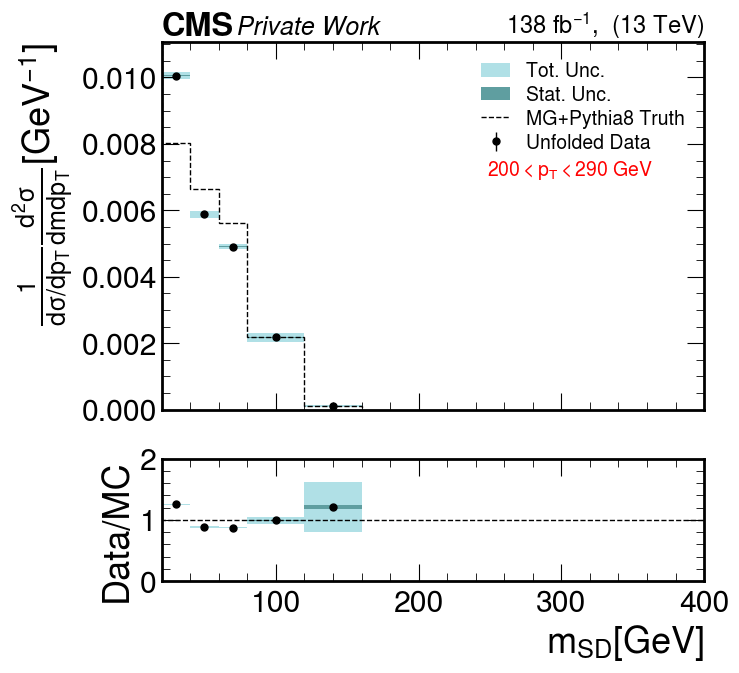

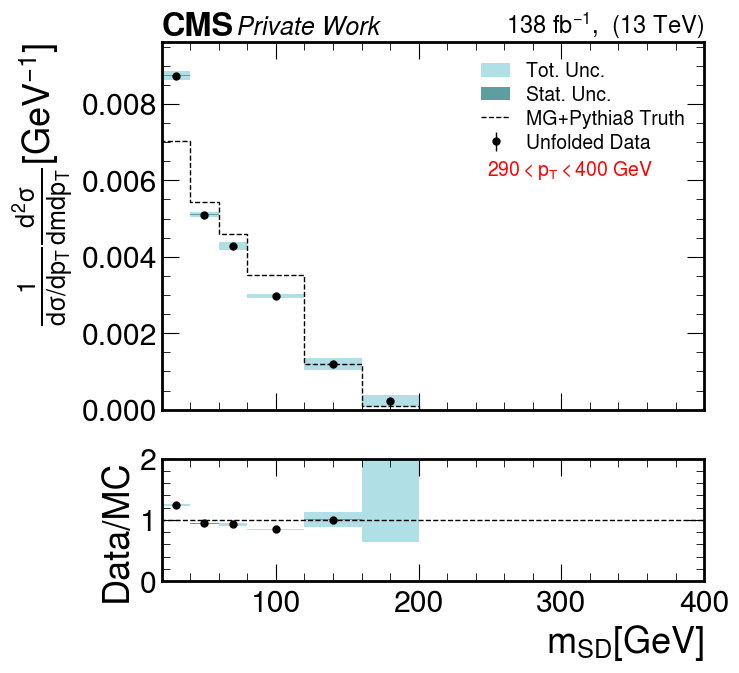

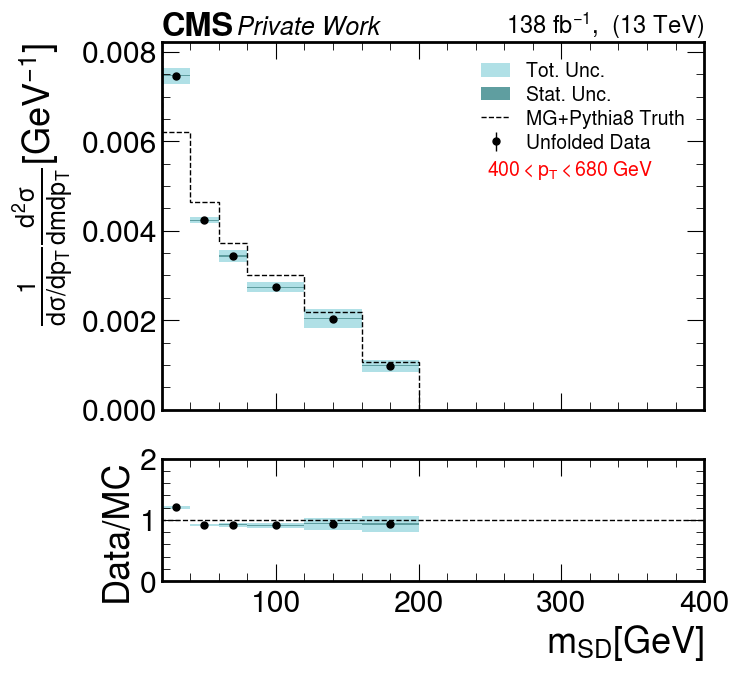

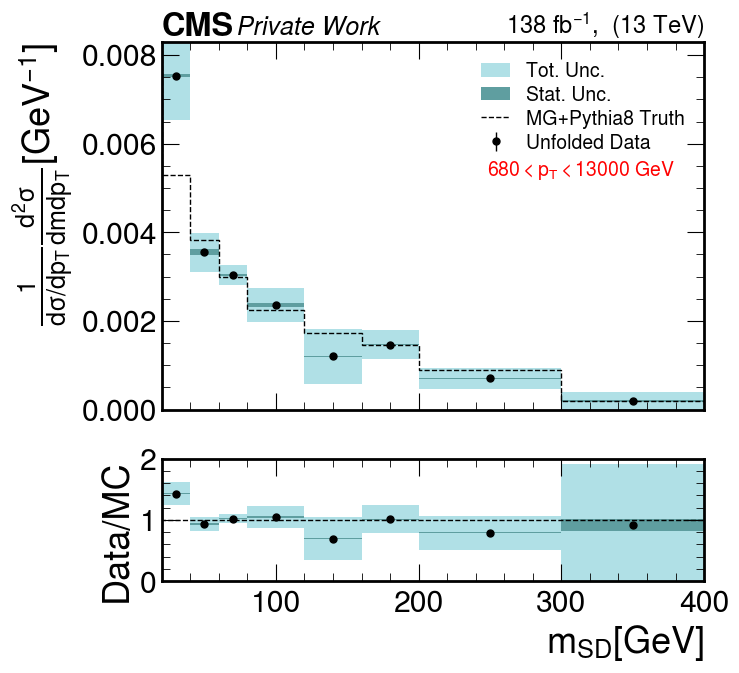

In [71]:

hist_true = resp_matrix_4d[{'syst':'nominal'}]
if closure == "herwig":
    hist_true = resp_matrix_4d_herwig
plotUnfoldOutputHist(hist_true, unfolder.output_pt_binned, total_sys_pt_binned, stat_unc, mask=nan_map, groomed=groomed, closure = closure,  channel=channel, IOV=IOV, log=False)#, yoffset = 1e-4)


In [72]:
if groomed:
    np.savetxt('stat_mat_groomed.txt', stat_unc)
else:
    np.savetxt( 'stat_mat_ungroomed.txt', stat_unc,)

In [73]:
resp_matrix_4d_herwig.values().shape

(4, 1, 4, 24, 4, 12)

In [74]:
unfolder_herwig = Unfolder(input_data, resp_matrix_4d_herwig , fakes = fakes_herwig, misses = misses_herwig[{'syst':'nominal'}],
                            backgrounds = None,
                            #systematics = {'JES_AbsoluteMPFBiasUp': resp_matrix_4d[{'systematic':'JES_AbsoluteMPFBiasUp'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()  },
                            #systematics = sys_matrix_dic,
                            systematics= None,
                            closure = False,
                            groomed = groomed,
                            is_uf = True,
                            merge = False,
                            normalised_xs = True,
                            do_syst = False,
                            discard_low_bins = False,
                            regularisation= 'None',
                            do_norm = False
                                   )

ValueError: The axis name syst could not be found

In [ ]:
unfolder_herwig.perform_unfold()

In [ ]:
unfolder_herwig.plot_unfolded()

In [ ]:
pythia_output = unfolder.get_results()[0]
herwig_output = unfolder_herwig.get_results()[0]
nptgen = unfolder.nptbinsGen
nmgen = unfolder.nmbinsGen
print(nptgen, nmgen)
for ipt in range(nptgen):
    # if groomed:
        
    #     herwig_normalised  = herwig_output[ipt]/herwig_output[ipt].sum()
    #     pythia_normalised = pythia_output[ipt]/pythia_output[ipt].sum()
    #     plt.stairs(herwig_normalised/mgen_width, mgen_edge, color = 'r', label = 'Unfolded DATA using Herwig')
    #     plt.stairs(pythia_normalised/mgen_width, mgen_edge, color = 'b', label = 'Unfolded DATA using Pythia')
    #     plt.legend(title = title_list[ipt])
    #     plt.xlim(0,200)
    #     plt.xlabel("Jet Mass (GeV)")
    #     plt.show()
        
    if (ipt==0):
        herwig_normalised  = herwig_output[ipt]/herwig_output[ipt].sum()
        pythia_normalised = pythia_output[ipt]/pythia_output[ipt].sum()
        plt.stairs(herwig_normalised/mgen_width, mgen_edge, color = 'r', label = 'Unfolded DATA using Herwig')
        plt.stairs(pythia_normalised/mgen_width, mgen_edge, color = 'b', label = 'Unfolded DATA using Pythia')
        plt.legend(title = title_list[ipt])
        plt.xlim(0,200)
        plt.xlabel("Jet Mass (GeV)")
        plt.show()
    else:
        
        # Normalize Herwig and Pythia distributions
        herwig_normalised = herwig_output[ipt] / herwig_output[ipt].sum()
        pythia_normalised = pythia_output[ipt] / pythia_output[ipt].sum()
        
        # Define the indices to merge
        if not groomed:
            merge_indices = [(0 , 1), (2, 3), (4,5), (6,7), (8,9),]  # Python index is 0-based, so (2nd,3rd) -> (1,2) and (5th,6th) -> (4,5)
        else:
            merge_indices = [(0,1), (2,3), (4,5),(6,7), (8,9),]
        # Merge the bin values
        def merge_bins(data, bin_edges, merge_indices):
            new_data = list(data)
            new_edges = list(bin_edges)
        
            for i, j in reversed(merge_indices):  # Reverse to avoid shifting indices
                new_data[i] += new_data[j]  # Sum the values
                del new_data[j]  # Remove the merged element
                new_edges[i + 1] = new_edges[j + 1]  # Extend the bin range
                del new_edges[j + 1]  # Remove the extra bin edge
        
            new_width = np.diff(new_edges)  # Recalculate bin widths
            return np.array(new_data), np.array(new_edges), new_width
        
        # Apply merging
        herwig_merged, mgen_edge_merged, mgen_width_merged = merge_bins(herwig_normalised, mgen_edge, merge_indices)
        pythia_merged, _, _ = merge_bins(pythia_normalised, mgen_edge, merge_indices)  # Use the same edges for Pythia
        
        # Plot the modified histograms
        plt.stairs(herwig_merged / mgen_width_merged, mgen_edge_merged, color='r', label='Unfolded DATA using Herwig')
        plt.stairs(pythia_merged / mgen_width_merged, mgen_edge_merged, color='b', label='Unfolded DATA using Pythia')
        
        plt.legend(title="$p_T$ "+str(ptgen_edge[ipt])+"-"+str(ptgen_edge[ipt+1])+" GeV")
        plt.xlim(0, 200)
        plt.xlabel("Jet Mass (GeV)")
        plt.show()


    

In [ ]:
relative_herwig = []

for ipt in range(nptgen):
    # if groomed:

    #     herwig_normalised  = herwig_output[ipt]/herwig_output[ipt].sum()
    #     pythia_normalised = pythia_output[ipt]/pythia_output[ipt].sum()
    #     diff = np.abs(pythia_normalised-herwig_normalised)/2/np.abs(pythia_normalised)
    #     hep.histplot(diff, mgen_edge, label = title_list[ipt], color = color_pt[ipt])
    #     plt.xlim(10,300)
    #     plt.ylim(0,1)
    #     #plt.show()
    if ipt!=3:
        herwig_normalised  = herwig_output[ipt]/herwig_output[ipt].sum()
        pythia_normalised = pythia_output[ipt]/pythia_output[ipt].sum()
        diff = np.abs(pythia_normalised-herwig_normalised)/2/np.abs(pythia_normalised)
        hep.histplot(diff, mgen_edge, label = title_list[ipt], color = color_pt[ipt])
        plt.xlim(20,300)
        plt.ylim(0,1)
        #plt.show()
    else:
        
        diff = np.abs(pythia_merged-herwig_merged)/2/np.abs(pythia_merged)
        hep.histplot(diff, mgen_edge_merged, label = title_list[ipt], color = color_pt[ipt])
        plt.xlim(20,300)
        plt.ylim(0,1)
        #plt.show()

    relative_herwig.append(diff)
    
    
    plt.ylabel("Relative Uncertainty")
    hep.cms.label("Private Work", com = 13, lumi = 138, data = True, loc=0, ax=ax);
    # if groomed:
    #     plt.legend(title=r"$\bf{Groomed}$", fontsize = 20, title_fontsize = 22)
    #     plt.xlabel(r"Groomed Jet Mass $m_u$ (GeV)")
    #     plt.savefig(f"plots/unfold/herwig_unc_groomed.pdf")
    # else:
    #     plt.legend(title=r"$\bf{Ungroomed}$", fontsize = 20, title_fontsize = 22)
    #     plt.xlabel(r"Ungroomed Jet Mass $m_u$ (GeV)")
    #     plt.savefig(f"plots/unfold/herwig_unc_ungroomed.pdf")

In [ ]:
total_sys_pt_bin = unfolder.total_sys_pt_binned

total_sys_pt_bin_down = unfolder_dn.total_sys_pt_binned

In [ ]:
unfolder.plot_correlation()
corr_matrix = unfolder.corr_matrix

In [ ]:
############## Up ##################

total_sys_w_herwig_pt_binned = []
total_sys_down_w_herwig_pt_binned = []
unfolded_result_dic = {}
for ipt in range(npt):
    if ipt !=3:
        nominal_result = unfolder.get_results()[0][ipt]
        herwig_unc = nominal_result*relative_herwig[ipt]

        ######### Up ###############
        total_sys2 = total_sys_pt_bin[ipt]**2       
        total_sys2 += herwig_unc
        total_sys = total_sys2**0.5
        total_sys_w_herwig_pt_binned.append(total_sys)
        ######### Down ###############
        total_sys2_down = total_sys_pt_bin_down[ipt]**2
        total_sys2_down += herwig_unc
        total_sys_down = total_sys2_down**0.5
        total_sys_down_w_herwig_pt_binned.append(total_sys_down)
        
        unfolded_result_dic[ipt] = nominal_result
    else:
        pythia_merged, _, _ = merge_bins(pythia_output[ipt], mgen_edge, merge_indices)
        nominal_result = pythia_merged
        
        herwig_unc = nominal_result*relative_herwig[ipt]
        if not groomed:
            corr_12 = corr_matrix[30+1, 30+2]
            corr_45 = corr_matrix[30+4, 30+5]

            ############# Up ##############
            total_sys_final_bin = total_sys_pt_bin[ipt]
            
            
            s1 = total_sys_final_bin[1]
            s2 = total_sys_final_bin[2]
            s4 =  total_sys_final_bin[4]
            s5 =  total_sys_final_bin[5]
    
            s1 = np.sqrt(s1**2 + s2**2 + 2*corr_12*s1*s2)
            s4 = np.sqrt(s4**2 + s5**2 + 2*corr_45*s4*s5)
    
            total_sys_final_bin[4] = s4
            total_sys_final_bin = np.delete(total_sys_final_bin, 5)
            total_sys_final_bin[1] = s1
            total_sys_final_bin = np.delete(total_sys_final_bin, 2)

            ############# Down ##############

            total_sys_final_bin_down = total_sys_pt_bin_down[ipt]
            
            
            s1 = total_sys_final_bin_down[1]
            s2 = total_sys_final_bin_down[2]
            s4 =  total_sys_final_bin_down[4]
            s5 =  total_sys_final_bin_down[5]
    
            s1 = np.sqrt(s1**2 + s2**2 + 2*corr_12*s1*s2)
            s4 = np.sqrt(s4**2 + s5**2 + 2*corr_45*s4*s5)
    
            total_sys_final_bin_down[4] = s4
            total_sys_final_bin_down = np.delete(total_sys_final_bin_down, 5)
            total_sys_final_bin_down[1] = s1
            total_sys_final_bin_down = np.delete(total_sys_final_bin_down, 2)
        else:

            
            corr_34 = corr_matrix[30+3, 30+4]
            corr_56 = corr_matrix[30+5, 30+6]


            ######### Up ####################
            total_sys_final_bin = total_sys_pt_bin[ipt]
            
            s3 = total_sys_final_bin[3]
            s4 = total_sys_final_bin[4]
            s5 = total_sys_final_bin[5]
            s6 = total_sys_final_bin[6]
            
            s3 = np.sqrt(s3**2 + s4**2 + 2*corr_34*s3*s4)
            s5 = np.sqrt(s5**2 + s6**2 + 2*corr_56*s5*s6)
            
            total_sys_final_bin[3] = s3
            total_sys_final_bin = np.delete(total_sys_final_bin, 4)
            total_sys_final_bin[5] = s5
            total_sys_final_bin = np.delete(total_sys_final_bin, 6)

            ############ Down ####################
            total_sys_final_bin_down = total_sys_pt_bin_down[ipt]
            
            s3 = total_sys_final_bin_down[3]
            s4 = total_sys_final_bin_down[4]
            s5 = total_sys_final_bin_down[5]
            s6 = total_sys_final_bin_down[6]
            
            s3 = np.sqrt(s3**2 + s4**2 + 2*corr_34*s3*s4)
            s5 = np.sqrt(s5**2 + s6**2 + 2*corr_56*s5*s6)
            
            total_sys_final_bin_down[3] = s3
            total_sys_final_bin_down = np.delete(total_sys_final_bin_down, 4)
            total_sys_final_bin_down[5] = s5
            total_sys_final_bin_down = np.delete(total_sys_final_bin_down, 6)

        ########## Up ##############
        total_sys2 =total_sys_final_bin**2
        total_sys2 += herwig_unc
        total_sys = total_sys2**0.5
        total_sys_w_herwig_pt_binned.append(total_sys)


        ########### Down #################
        total_sys2_down =total_sys_final_bin_down**2
        total_sys2_down += herwig_unc
        total_sys_down = total_sys2_down**0.5
        total_sys_down_w_herwig_pt_binned.append(total_sys_down)
        
        unfolded_result_dic[ipt] = nominal_result


In [ ]:
unfolded_result_dic = {}
if not groomed:
    for ipt in range(npt):
        if ipt !=3:
            nominal_result = unfolder.get_results()[0][ipt]
            unfolded_result_dic[ipt] = nominal_result
        else:
            pythia_merged, _, _ = merge_bins(pythia_output[ipt], mgen_edge, merge_indices)
            nominal_result = pythia_merged
    
            unfolded_result_dic[ipt] = nominal_result
else:
    for ipt in range(npt):
        if ipt !=3:
            nominal_result = unfolder.get_results()[0][ipt]
            unfolded_result_dic[ipt] = nominal_result
        else:
            pythia_merged, _, _ = merge_bins(pythia_output[ipt], mgen_edge, merge_indices)
            nominal_result = pythia_merged
    
            unfolded_result_dic[ipt] = nominal_result
        
# if groomed:
#     with open("unfolded_result_groomed.pkl", "wb") as f:
#         pkl.dump(unfolded_result_dic, f)
# else:
#     with open("unfolded_result_ungroomed.pkl", "wb") as f:
#         pkl.dump(unfolded_result_dic, f)

In [ ]:
total_sys_pt_dic = {0:total_sys_w_herwig_pt_binned[0], 1:total_sys_w_herwig_pt_binned[1], 2:total_sys_w_herwig_pt_binned[2]}#, 3:total_sys_w_herwig_pt_binned[3]}

total_sys_down_pt_dic = {0:total_sys_down_w_herwig_pt_binned[0], 1:total_sys_down_w_herwig_pt_binned[1], 2:total_sys_down_w_herwig_pt_binned[2]}#, 3:total_sys_down_w_herwig_pt_binned[3]}

In [ ]:
if groomed:
    with open("total_sys_pt_dic_groomed.pkl", "wb") as f:
        pkl.dump(total_sys_pt_dic, f)
    with open("total_sys_down_pt_dic_groomed.pkl", "wb") as f:
        pkl.dump(total_sys_down_pt_dic, f)
else:
    with open("total_sys_pt_dic_ungroomed.pkl", "wb") as f:
        pkl.dump(total_sys_pt_dic, f)
    with open("total_sys_down_pt_dic_ungroomed.pkl", "wb") as f:
        pkl.dump(total_sys_down_pt_dic, f)

In [ ]:
def make_comparison_plot(data1, unc1, data2, unc2, x_edges):
    """
    Create a two-panel figure:
      - Top: data1 (stepped line + shaded uncertainty) vs. data2 (points with error bars)
      - Bottom: (data2/data1 - 1) vs. x, with a band showing the fractional uncertainty of data1.

    Parameters
    ----------
    data1 : array-like
        Central values for the first (nominal) distribution in each bin.
    unc1 : array-like
        Uncertainties for the first (nominal) distribution in each bin.
    data2 : array-like
        Central values for the second (alternative) distribution in each bin.
    unc2 : array-like
        Uncertainties for the second (alternative) distribution in each bin.
    x_edges : array-like
        The bin edges in x (length should be len(data1)+1).

    Returns
    -------
    fig : matplotlib.figure.Figure
    (ax_top, ax_bot) : tuple of matplotlib.axes.Axes
        The top and bottom axes, respectively.
    """

    # Compute bin centers
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    
    # Create the figure and subplots with a ratio of heights
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},

    )
    
    # -- Top Panel --
    # Plot data1 as a step curve
    ax_top.step(
        x_edges, np.append(data1, data1[-1]),  # for step(..., where='post') we often repeat last value
        where='post', color='black', label="Unfolded PYTHIA"
    )
    # Add a shaded band for the uncertainty on data1
    lower1 = data1 - unc1
    upper1 = data1 + unc1
    ax_top.fill_between(
        x_edges,
        np.append(lower1, lower1[-1]),
        np.append(upper1, upper1[-1]),
        step='post', color='gray', alpha=0.5
    )
    
    # Plot data2 with error bars
    ax_top.errorbar(
        x_centers, data2, yerr=unc2, fmt='o', color='orange', label="Unfolded herwig7"
    )
    
    # Set y-scale to log
    #ax_top.set_yscale('log')
    
    # -- Bottom Panel --
    # Compute ratio (data2 / data1) minus 1
    # Protect against division by zero just in case:
    ratio = np.zeros_like(data1, dtype=float)
    valid_bins = (data1 != 0.0)
    ratio[valid_bins] = data2[valid_bins] / data1[valid_bins]
    ratio_minus_1 = ratio - 1.0
    
    # Uncertainty band around data1 in the ratio panel:
    # data1 itself in the ratio panel is effectively 1.0,
    # so the band is ± (unc1 / data1). We'll plot that around 0.0 (i.e. ratio_minus_1 = 0).
    band = np.zeros_like(data1, dtype=float)
    band[valid_bins] = unc1[valid_bins] / data1[valid_bins]
    
    # Plot the nominal ratio line (which is 0 in "ratio_minus_1" space) plus the band
    ax_bot.axhline(0, color='black', lw=1)
    ax_bot.fill_between(
        x_edges,
        np.append(-band, -band[-1]),
        np.append(band, band[-1]),
        step='post', color='gray', alpha=0.5
    )
    
    # Compute uncertainties on data2/data1
    #   ratio_err^2 = (unc2/data1)^2 + (data2*unc1 / data1^2)^2
    ratio_err = np.zeros_like(data1, dtype=float)
    ratio_err[valid_bins] = np.sqrt(
        (unc2[valid_bins]/data1[valid_bins])**2 +
        (data2[valid_bins]*unc1[valid_bins]/(data1[valid_bins]**2))**2
    )
    
    # Plot data2/data1 - 1 with error bars
    ax_bot.errorbar(
        x_centers, ratio_minus_1, yerr=ratio_err, fmt='o', color='orange'
    )
    
    # Some reasonable y-limits for the bottom panel
    ax_bot.set_ylim(-0.2, 0.5)
    
    # Remove extra spacing
    plt.tight_layout(h_pad=0.0)
    
    return fig, (ax_top, ax_bot)

In [ ]:
output_pythia, _, unc_pythia = unfolder.get_results()

output_herwig, _, unc_herwig = unfolder_herwig.get_results()

In [ ]:
plt.plot(output_pythia[2])
plt.plot(output_herwig[2])

In [ ]:
plt.plot(unc_pythia[2])
plt.plot(unc_herwig[2])

In [ ]:
mgen_edge_mod = mgen_edge.copy()
mgen_edge_mod[-1] = 240
title_list = [ r"$p_T$ 200-290 GeV",  r"$p_T$ 290-400 GeV",  r"$p_T$ 400-480 GeV",  r"$p_T$ 480-$\infty$ GeV"]


for i in range(4):
    fig, (ax1, ax2) = make_comparison_plot(
            output_pythia[i]/mgen_width/output_pythia[i].sum(), unc_pythia[i]/mgen_width/output_pythia[i].sum(),
            output_herwig[i]/mgen_width/output_herwig[i].sum(), unc_herwig[i]/mgen_width/output_herwig[i].sum(),
            mgen_edge_mod
        )
    
    ax2.set_ylim(-1, 1)
    ax1.set_xlim(10,240)
    ax1.legend(title = title_list[i])
    if groomed:
        ax2.set_xlabel("Groomed Jet Mass (GeV)")

    else:
        ax2.set_xlabel("Ungroomed Jet Mass (GeV)")
    ax2.set_ylabel("Herwig/Pythia")
    hep.cms.label("Private Work", com = 13, lumi = 138, data = True, loc=0, ax=ax1);


In [ ]:
 resp_matrix_4d.axes['mgen'].edges

In [ ]:
widths

In [ ]:
data_list = []
for ipt in range(4):
    edges = [1.00e+01, 1.00e+01, 2.00e+01, 2.00e+01, 2.00e+01, 2.00e+01,
       2.00e+01, 2.00e+01, 2.00e+01, 4.00e+01, 1.28e+04]
    y_data =  resp_matrix_4d[{'syst':'nominal'}].project('ptgen', 'mgen')[ipt, :].values()
    
    y_data = y_data/y_data.sum()

    y2_data = unfolder.get_results()[0][ipt]
    y2_data = y2_data/y2_data.sum()
    up = unfolder.get_results()[1][ipt]
    down = unfolder_dn.get_results()[1][ipt]
    stat_unc_up = stat_unc[i]
    data_list.append([edges, y2_data, stat_unc_up, up, down, y_data])
    

In [ ]:
markers = ['o', 's', 'D', '^', 'v']
ptbinsGen = ptgen_edge
ipt = 0 
for i in range(4):
    x_data = resp_matrix_4d.axes['mgen'].centers  
    widths = resp_matrix_4d.axes['mgen'].widths
    if not groomed:
        if i == 3:
            x_data = [5.0e+00, 1.5e+01, 40,  7.0e+01, 100,
       1.3e+02, 1.5e+02, 1.8e+02, 225]
#widths = resp_matrix_4d.axes['mgen'].widths
            widths = [10,10,40,20,40,20,20, 40, 12540]
        
    
    power_text = r'$\times 10^{{{}}}$'.format(i)
    pt_text = r'$p_T$ '+ str(ptbinsGen[ipt])[:-2]+'-'+str(ptbinsGen[ipt+1])[:-2] + ' GeV ' + power_text
    ipt = ipt + 1
    if i==0:
        plt.stairs(np.array(data_list[i][1][:-4])*(10**i), data_list[i][0][:-4], color = 'black' )
        plt.plot(x_data[:-4], np.array(data_list[i][1][:-4])*(10**i), color = 'black' , lw = 0, marker = markers[i], label = pt_text)
    elif i==1:
        plt.stairs(np.array(data_list[i][1][:-3])*(10**i), data_list[i][0][:-3], color = 'black' )
        plt.plot(x_data[:-3], np.array(data_list[i][1][:-3])*(10**i), color = 'black' , lw = 0, marker = markers[i], label = pt_text)
        
    else:    
        plt.stairs(np.array(data_list[i][1])*(10**i), data_list[i][0], color = 'black' )   
            
        plt.plot(x_data, np.array(data_list[i][1])*(10**i), color = 'black' , lw = 0, marker = markers[i], label = pt_text)
    plt.xlim(0,100)
    plt.yscale('log')
    plt.ylim(10**-5, 60)
    plt.xlim(20, 200)
    plt.ylim()
    widths[-1] = 20
    if groomed:
        #custom_text = 'Groomed'
        xlabel = "Groomed Jet Mass $m_{g}$ (GeV)"
        ylabel=r'$\frac{1}{d\sigma/dp_{T}} \, \frac{d^2 \sigma}{dm_{g} \, dp_{T}}$ (1/GeV)'
    else:
        #custom_text  = 'Ungroomed'
        xlabel = "Ungroomed Jet Mass $m_{u}$ (GeV)"
        ylabel=r'$\frac{1}{d\sigma/dp_{T}} \, \frac{d^2 \sigma}{dm_{u} \, dp_{T}} (1/GeV)$'
    plt.xlabel(xlabel)
    plt.ylabel( ylabel)
    
    sys_up = np.array(data_list[i][3])*10**i 
    sys_down = np.array(data_list[i][4])*10**i 
    tot_up = np.sqrt(np.array(sys_up)**2 + np.array(data_list[i][2])*10**i)
    tot_down = np.sqrt(np.array(sys_up)**2 + np.array(data_list[i][2])*10**i)

    if i ==0:
        plt.bar(x_data[:-4], # x
            2*np.array(data_list[i][2][:-4])*10**i, # heights
            #alpha=0.5, # half transparency
            bottom=(np.array(data_list[i][1][:-4])*(10**i)) - (np.array(data_list[i][2][:-4])*(10**i)), color='b',  width=widths[:-4], label='Stat. Unc.')
        print(np.array(data_list[i][2][:-4])*10**i)
        plt.bar(x_data[:-4], # x
            tot_up[:-4] + tot_down[:-4], # heights
            alpha=0.5, # half transparency
            bottom=(np.array(data_list[i][1][:-4])*(10**i)) - tot_down[:-4], color = 'cyan', width=widths[:-4], label='Total Unc')
    elif i ==1:
        idx = 3
        plt.bar(x_data[:-idx], # x
            2*np.array(data_list[i][2][:-idx])*10**i, # heights
            #alpha=0.5, # half transparency
            bottom=(np.array(data_list[i][1][:-idx])*(10**i)) - (np.array(data_list[i][2][:-idx])*(10**i)), color='b',  width=widths[:-idx], label='Stat. Unc.')
        print(np.array(data_list[i][2][:-idx])*10**i)
        plt.bar(x_data[:-idx], # x
            tot_up[:-idx] + tot_down[:-idx], # heights
            alpha=0.5, # half transparency
            bottom=(np.array(data_list[i][1][:-idx])*(10**i)) - tot_down[:-idx], color = 'cyan', width=widths[:-idx], label='Total Unc')
    else:
        plt.bar(x_data, # x
            2*np.array(data_list[i][2])*10**i, # heights
            #alpha=0.5, # half transparency
            bottom=(np.array(data_list[i][1])*(10**i)) - (np.array(data_list[i][2])*(10**i)), color='b',  width=widths, label='Stat. Unc.')
        print(np.array(data_list[i][2])*10**i)
        plt.bar(x_data, # x
            tot_up + tot_down, # heights
            alpha=0.5, # half transparency
            bottom=(np.array(data_list[i][1])*(10**i)) - tot_down, color = 'cyan', width=widths, label='Total Unc')
for i in range(4):  
    if i == 0:
        idx = 4
        plt.stairs(np.array(data_list[i][5][:-idx])*(10**i), data_list[i][0][:-idx], color = 'red', label = ' PYTHIA', lw = 2  )
    elif i == 1:
        idx = 3
        plt.stairs(np.array(data_list[i][5][:-idx])*(10**i), data_list[i][0][:-idx], color = 'red', label = ' PYTHIA', lw = 2  )
    else:

        plt.stairs(np.array(data_list[i][5][:])*(10**i), data_list[i][0][:], color = 'red', label = ' PYTHIA', lw = 2  )
handles, labels = plt.gca().get_legend_handles_labels()
        
handles.append(plt.Line2D([0], [0], color='none', label=custom_text))
handles.append(plt.Line2D([0], [0], color='none', label=custom_text))
labels.append(custom_text)

# Add legend with the custom entry
hep.cms.label("Private Work", data = 1)
by_label = dict(zip(labels, handles))
leg = plt.legend(by_label.values(), by_label.keys(), fontsize = 12)

In [ ]:
resp_matrix_4d.project('ptgen', 'mgen').values()
pythia_gen_merged, _, _ = merge_bins(resp_matrix_4d.project('ptgen', 'mgen').values()[3], mgen_edge, merge_indices)

In [ ]:
pythia_orig_dic = {}
for i in range(3):
    pythia_orig_dic[i] = resp_matrix_4d.project('ptgen', 'mgen').values()[i]
pythia_orig_dic[3] = pythia_gen_merged

In [ ]:
if not groomed:
    with open("pythia_gen_ungroomed.pkl", "wb") as f:
        pkl.dump(pythia_orig_dic, f)
else:
    with open("pythia_gen_groomed.pkl", "wb") as f:
        pkl.dump(pythia_orig_dic, f)